# Диагностика предсказательных моделей

## Атрибуты
### [Coloab](https://colab.research.google.com/github/MVRonkin/TimeSeriesCourse/blob/main/Last/WS/04-TSDiagnostics.ipynb)


In [1]:
import os
UPDATE_UTILITS = True
if UPDATE_UTILITS:
    !rm -rf utilits4tsc temp_repo
    !git clone --depth 1 https://github.com/MVRonkin/utilits4tsc.git utilits4tsc
    

"rm" ­Ґ пў«пҐвбп ў­гваҐ­­Ґ© Ё«Ё ў­Ґи­Ґ©
Є®¬ ­¤®©, ЁбЇ®«­пҐ¬®© Їа®Ја ¬¬®© Ё«Ё Ї ЄҐв­л¬ д ©«®¬.
fatal: destination path 'utilits4tsc' already exists and is not an empty directory.


In [2]:
from utilits4tsc import *
plt_style_GOST()

In [3]:
from IPython.display import display, Markdown
display(Markdown(generate_toc(max_lvl=2)))

## Содержание
* [Диагностика предсказательных моделей](#диагностика-предсказательных-моделей)
  * [Атрибуты](#атрибуты)
  * [Основные материалы к работе](#основные-материалы-к-работе)
  * [Анализ невязок (остатков) предсказаний](#анализ-невязок-остатков-предсказаний)
  * [Продвинутая валидация модели модели](#продвинутая-валидация-модели-модели)
  * [Построение вероятностных прогнозов моделей](#построение-вероятностных-прогнозов-моделей)
  * [Session info](#session-info)
  * [Дополнительно](#дополнительно)
  * [Дополнительно про CV](#дополнительно-про-cv)

## Основные материалы к работе

### Темы в работе

|раздел | [Nixtla](https://nixtlaverse.nixtla.io/statsforecast/) / [GitHub](https://github.com/Nixtla/statsforecast/tree/main/nbs/docs) | [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|
|Анализ остатков | - | [5.4](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-diagnostics) |
|Бектестинг | [Cross validation](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/crossvalidation.html) [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/CrossValidation.ipynb) | [5.10](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-tscv) |
|Вероятностные методы | [Probabilistic Forecasting](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/uncertaintyintervals.html), [Conformal Prediction](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/conformalprediction.html) [GitHub1](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/UncertaintyIntervals.ipynb), [GitHub2](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/ConformalPrediction.ipynb) |[5.5](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-prediction-intervals) |

### Дополнительня литература
* [FPPPY 12.4 - Bootstrapping and bagging forecasting](https://otexts.com/fpppy/nbs/12-advanced.html#sec-bootstrap)
* [Большой блог-пост предсказания неопределенности AIRMA](https://newdigitals.org/2024/01/05/leveraging-predictive-uncertainties-of-time-series-forecasting-models/)
* [Conformal Prediction forecasting with Nixtla’s statsforecast](https://readmedium.com/conformal-prediction-forecasting-with-nixtlas-statsforecast-cc39b9e30b36)
* [awesome-conformal-prediction](https://github.com/valeman/awesome-conformal-prediction)

### Фреймворк исследования моделей предсказания ВР

При построении моделей прогноза полезным использование таких приемов, как:
* Оконное тестирование данных [(обратное тестирование)](https://joaquinamatrodrigo.github.io/skforecast/0.11.0/introduction-forecasting/introduction-forecasting.html#backtesting-forecasting-models).
* Использование дополнительных метрик [оценки качества прогноза](https://www.lokad.com/forecasting-accuracy-definition/), в том числе [вероятностное прогнозирование](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html)
* Построение прогнозов с использованием сторонних библиотек (в первую очередь [`sklearn`](https://www.aeon-toolkit.org/en/latest/examples/forecasting/forecasting_sklearn.html))
* Конвейеризация и автоматический выбор ступеней конвейера, их параметров и вариантов ([`auto ml`](https://arxiv.org/abs/2312.08528))
* [Ансамблирование прогнозов](https://habr.com/ru/articles/571296/).

В целом отметим [общий фреймворк](https://unit8.com/resources/darts-time-series-made-easy-in-python/), который можно бы было рекомендовать при проектироании экспериментов по предсказанию ВР одолженную в пакете [`darts`](https://github.com/unit8co/darts):
<img src="https://unit8.com/wp-content/uploads/2021/07/1_yaHh5V0AgxEYxJYrv9VQmA.png"
      style="width: 650px">

### Импорт

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [5]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [6]:
from scipy import stats
import pmdarima as pm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.stattools import kpss

import statsmodels.api as sm

In [7]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [8]:
from functools import partial

In [9]:
# from cv_nixtla import *
# from TSC_Nixtla_dump import *
# from nixtla_diagnostic import *

### Загрузка данных

Импорт данных аналогично предыдущего урока.

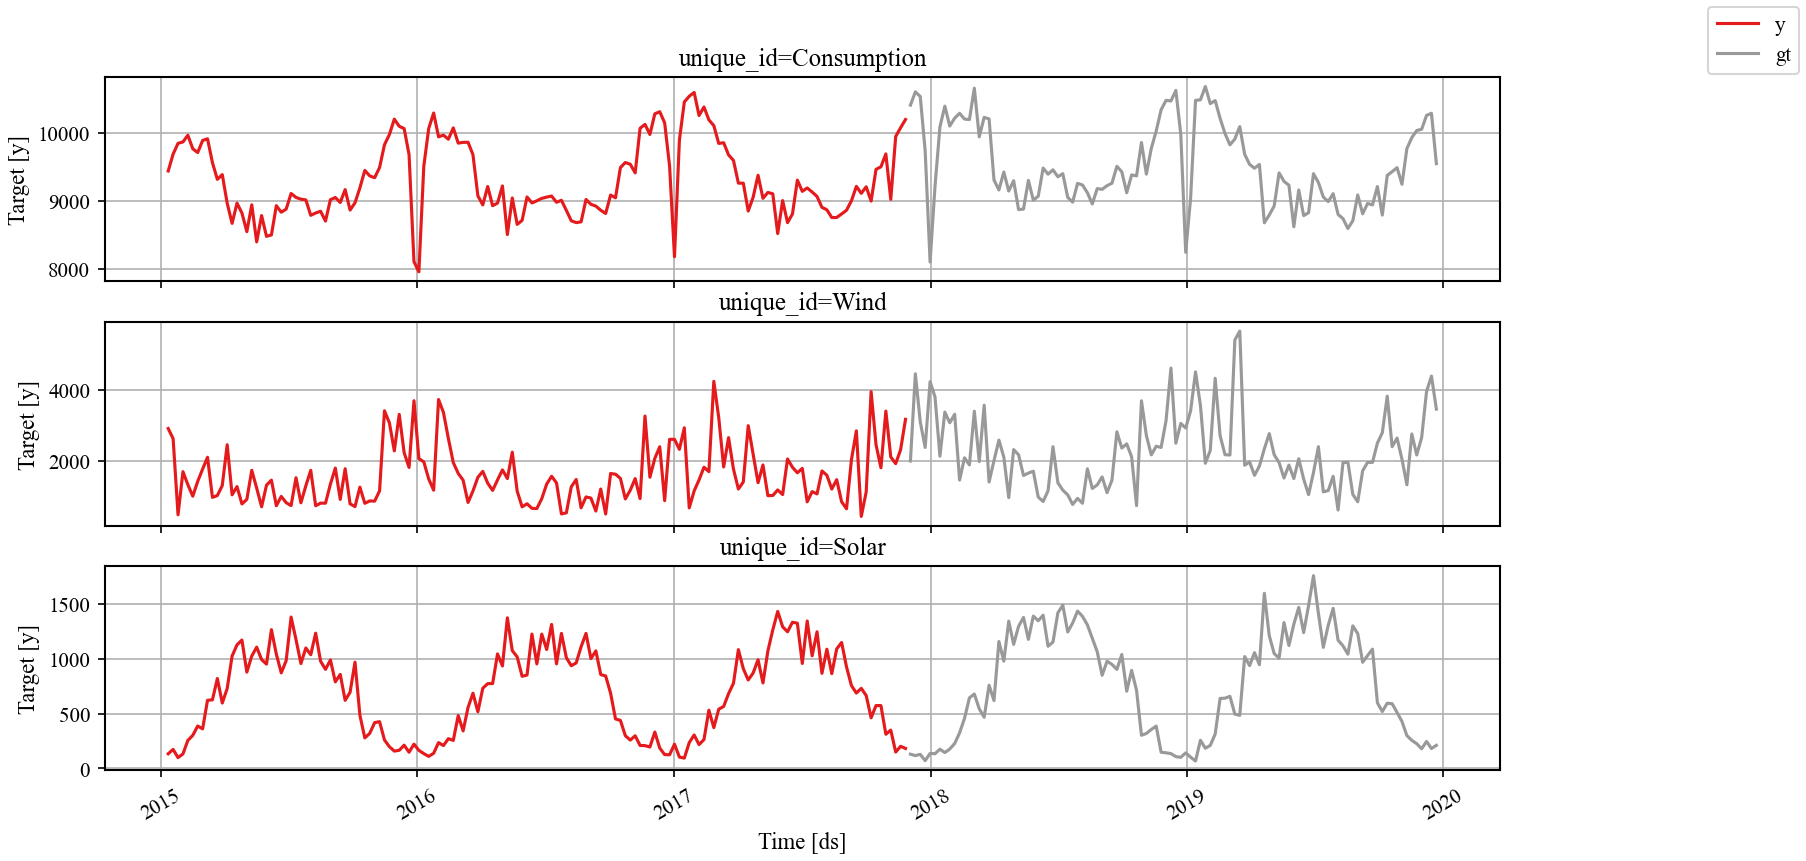

In [10]:
df= pd.read_csv(
    "utilits4tsc/OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series_v2(df_train, 
               df_test.rename(columns={"y": "gt"}),  
               palette='Set1', n_cols=1)

In [11]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'rmse': rmse,
    'smape': smape,
    'mae':mae
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

## Анализ невязок (остатков) предсказаний

### Методы диагностики моделей.
<!-- 1. Анализ метрик и сложности моделей
2. Анализ остатков моделей
3. Бектестинг и кросс-валидация моделей
4. Оценка интервального прогнозирования (разброс предсказания)
5. Анализ доверительности модели (надежность, устойчивость, интерпретируемость, конкретные ошибки и тд). -->


Существует как минимум четыре [источника неопределенности](https://nixtlaverse.nixtla.io/mlforecast/docs/tutorials/prediction_intervals_in_forecasting_models.html#importance-of-confidence-interval-prediction-in-time-series) при прогнозировании с помощью моделей временных рядов:
* Случайная составляющая ошибки (флуктуации);
* Ошибка оценки параметров (смещение);
* Ошибка связанная с выбором параметров модели на исторических данных (обобщающая способность, переобучение);
* Ошибка связанная с продолжением процесса генерирования исторических данных в будущем (воспроизводимость паттерном поведения ВР, дрифт данных).

<!-- - __Случайная составляющая ошибки (флуктуации)__ — это неустранимый шум, присущий самой природе данных. Даже при идеально подобранной модели будущие наблюдения будут отклоняться от прогноза из-за непредсказуемых внешних воздействий или внутренней стохастичности процесса.
- __Ошибка оценки параметров (смещение)__ — возникает потому, что параметры модели (например, коэффициенты регрессии или веса в дереве решений) оцениваются на конечной выборке. Эти оценки подвержены выборочной изменчивости: при другом наборе исторических данных они были бы иными, что привело бы к иному прогнозу.
- __Ошибка, связанная с выбором модели на исторических данных__ — отражает неопределённость в архитектуре или гиперпараметрах модели. Мы выбираем одну модель из множества возможных (ARIMA, XGBoost, Prophet и т.д.), но не знаем, действительно ли она наилучшим образом описывает истинный процесс. Эта неопределённость включает риски переобучения, недообучения и ограниченную обобщающую способность.
- __Ошибка, связанная с продолжением процесса генерирования данных в будущем (дрифт данных)__ — предполагает, что закономерности, наблюдаемые в прошлом, сохранятся в будущем. Однако в реальности могут произойти структурные изменения: смена режима работы системы, внешние шоки (экономические, климатические, технологические), изменение поведения пользователей. В таких случаях даже идеальная модель на исторических данных даёт смещённый прогноз. -->



При анализе моделей часто используются следующие практики:

- __Анализ метрик и сложности моделей__ <br>
Оценка качества прогноза с помощью количественных метрик (MAE, RMSE, MAPE) на тестовой выборке, а также учёт сложности модели через информационные критерии (AIC, BIC). Это позволяет найти баланс между точностью и переобучением.
- __Анализ остатков моделей__ <br>
Проверка свойств in-sample остатков: отсутствие автокорреляции (тест Льюнга–Бокса), стационарность, приближённая нормальность и отсутствие систематических паттернов. Хорошая модель должна оставлять «белый шум».
- __Бектестинг (кросс-валидация моделей)__ <br>
Моделирование реальных условий прогнозирования с помощью пошагового сдвига окна обучения (rolling-origin evaluation). Позволяет оценить устойчивость модели во времени и избежать оптимизма, связанного с однократным разбиением на train/test.
- __Оценка интервального прогнозирования (разброс предсказания)__ <br>
Анализ прогнозных интервалов: проверка покрытия (coverage — доля истинных значений внутри интервала) и sharpness (средняя ширина интервала). Надёжная модель даёт узкие интервалы с заданным уровнем покрытия (например, 90%).
- __Анализ доверительности модели__ <br>
Комплексная оценка надёжности: устойчивость коэффициентов при изменении данных, интерпретируемость результатов (соответствие предметной области), анализ типичных ошибок (например, занижение пиков или реакция на экстремальные события). Это помогает понять, можно ли доверять модели в реальных условиях.

### Оценка остатков модели.

#### Визуализация остатков 

Важным аспектом анализа любых моделей (в том числе и `ARIMA` и `ETS`, `Prophet`  и других) является [анализ остатков предсказания моделей](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-diagnostics) (т.н. невязок или innovations - “innovation residuals”). Которые могут быть вычеслены как:
$$ e = y_t - \hat y_t$$


<blockquote>
    
- Остатки (__residuals__) — это общее понятие - разница между реальными наблюдениями и тем, что предсказала модель на обучающих данных.
- Инновации/невязка (__innovations__) — это то же самое, что остатки, но в контексте временных рядов: они показывают «новую информацию», которую модель не смогла предсказать на каждом шаге времени.
  
</blockquote>


В случае идеального прогноза остатки модели должны представлять собой белый шум. Это значит что такие остатки не объяснимы. 

Расмотрим пример простого алгоритма и проведем анлиз его остатков его in-samples  предсказаний.

In [12]:
models = [
    # SeasonalExponentialSmoothingOptimized(SEASON),
    SeasonalNaive(SEASON),
    HoltWinters(season_length=SEASON, 
                error_type="A", 
                alias="HW_Add"),  ]

In [13]:
sf = StatsForecast(models=models, freq=FREQ)
sf.forecast(h=FH, df=df_train, fitted=True)
fitted_values = sf.forecast_fitted_values()

model_names = [getattr(model, 'alias', type(model).__name__) for model in sf.models]
for col in model_names:
    fitted_values[f"resid_{col}"] = fitted_values["y"] - fitted_values[col].values

Пострим результат in-sample  прогноза и остатков модели

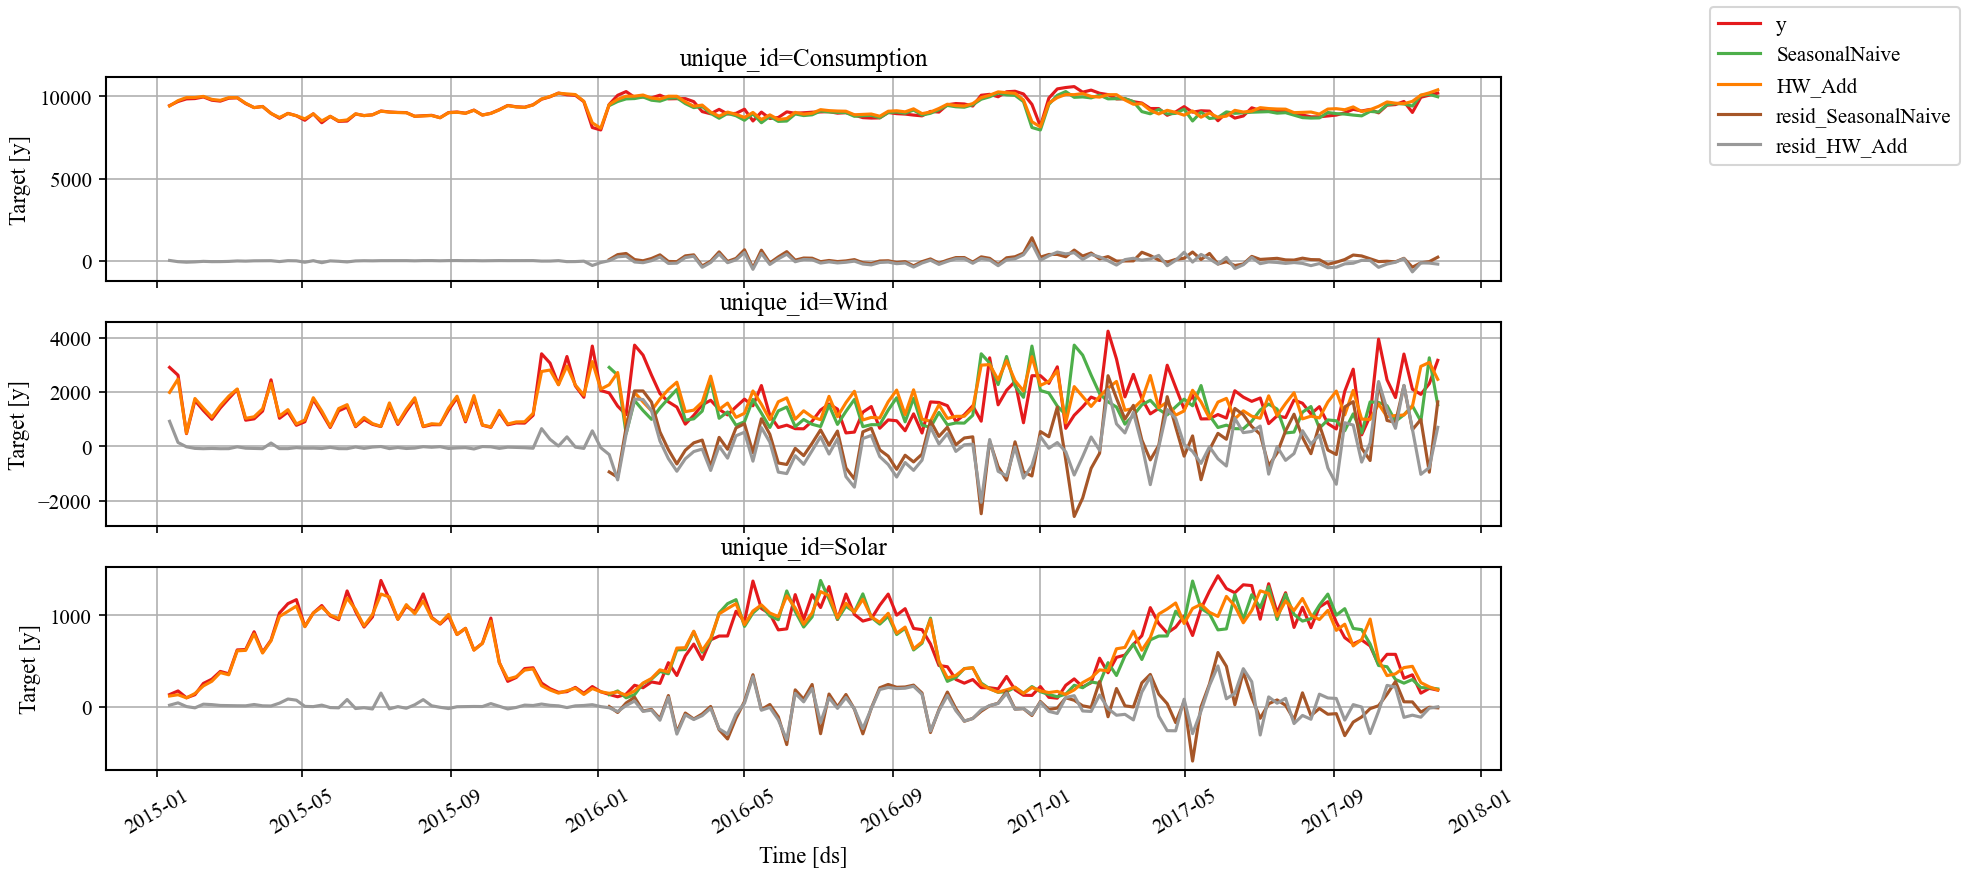

In [14]:
plot_series_v2(df = df_train,forecasts_df = fitted_values.drop(columns = 'y'), palette='Set1', n_cols=1)

Видно, что каждой модели остаток значительно отличается от белого шума. Это означает, что остаток информативен (содержит информацию, не описанную моделью).


#### Диагностика остатков предсказаний

На самом деле диагонстика остатков часто строится [по известному алгоритму](https://otexts.com/fpppy/nbs/05-toolbox.html#example-forecasting-google-daily-closing-stock-prices).

Для каждого ВР построим
1. __Остатки во времени__ (график в левом верхнем углу).
   - График показывает наличие тренда и сезонности в остатках, а также гетеросекдостичность разброса (шумов).
   - В название также показен результат теста __KPSS__, показывающий нестационарность данных по отклонениям от уровня (если p-value > 0.05 - гипотеза о стационарности).
2. __ACF__ (автокорреляционная функция) — график в правом верхнем углу.
   - Тут проверяется соотвествие остатков белому шуму и стационарность остатков. В иделае ACF должна иметь только нулевой лаг выше доверительного интервала.
   - В название графика  ACF также указается значение __теста  Льюнга–Бокса__. Если p-value теста Льюнга–Бокса > 0.05 (указано в заголовке) → автокорреляции нет (белый шум).
3. __Гистограмма остатков__ — график в левом нижнем углу.
   - Тут рассматривается на сколько гистограмма похоже на нормальное распределение, есть ли выбросы и тд.
   - Если есть сильный перекос → модель систематически завышает или занижает.
   - Если есть тяжелые хвосты - много выбросов.
   - Если распределение сильно отличается от нормального - модель неадекватна.
   - В заголовке указано значение __-Breusch–Pagan__ теста p-value.
   - Если BP p-value< 0.05 Отвергаем H₀ → гетероскедастичность присутствует.
4. __Q-Q plot__ (квантиль-квантильный график) — график в правом нижнем углу
   - График показывает сравнение модели и нормального распределения. Известны Q-Q plot для некоторых типичных видов распределний.
   - Например, точки изгибаются вверх/вниз → тяжёлые хвосты или перекос.
   - В название указано  p-value теста __Jarque–Bera__. Если p-value > 0.05 нормальность не отвергается (p-value < 0.05 → остатки не нормальны).

__Примеры выводов__:
- Если все 4 графика «хорошие» - модель адекватна, остатки похожи на белый шум.
- Если ACF чистый, но остальное плохо - модель динамику ловит, но, например, плохо калибрована.
- Если ACF плохой - модель недообучена — нужно улучшать спецификацию (больше лагов, сезонность и т.д.).


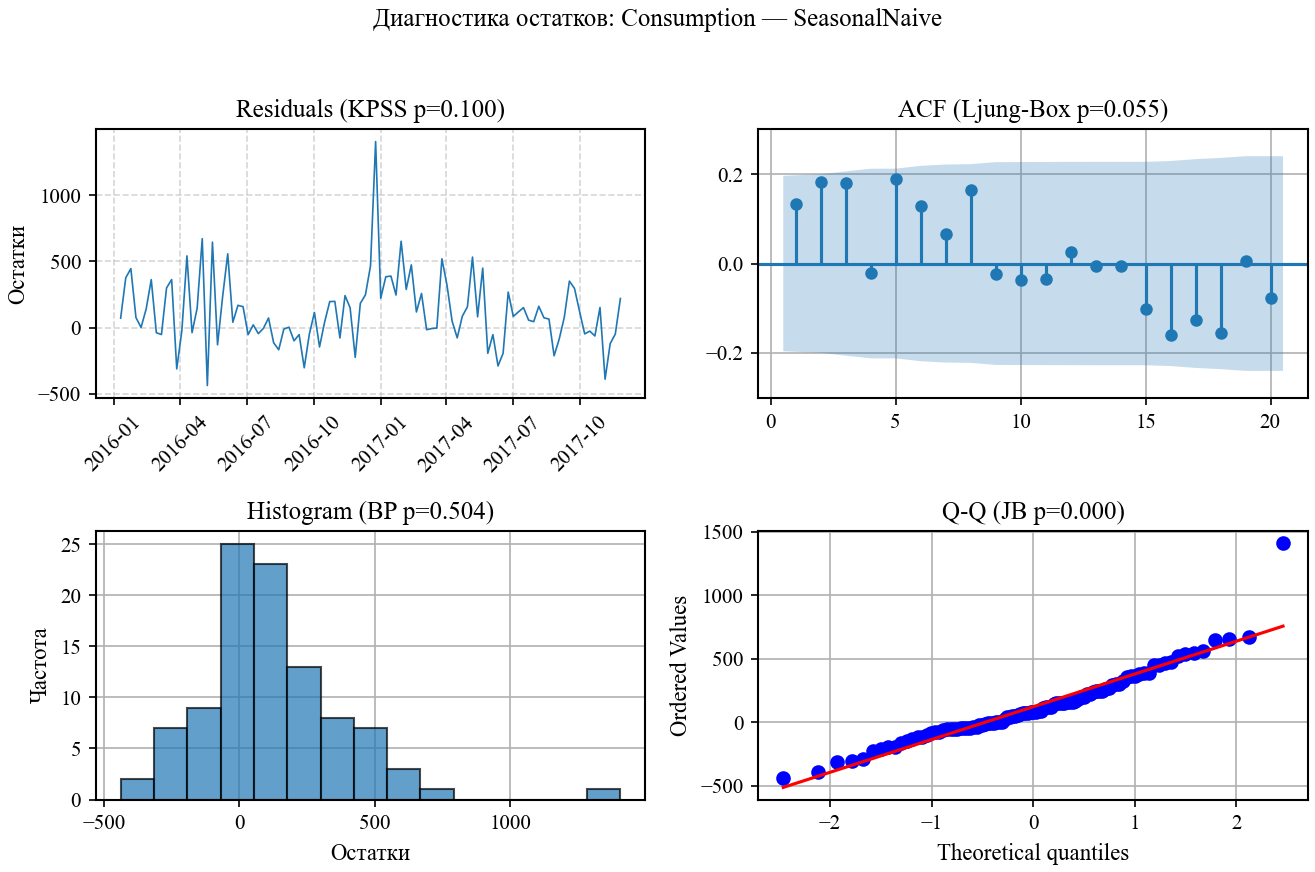

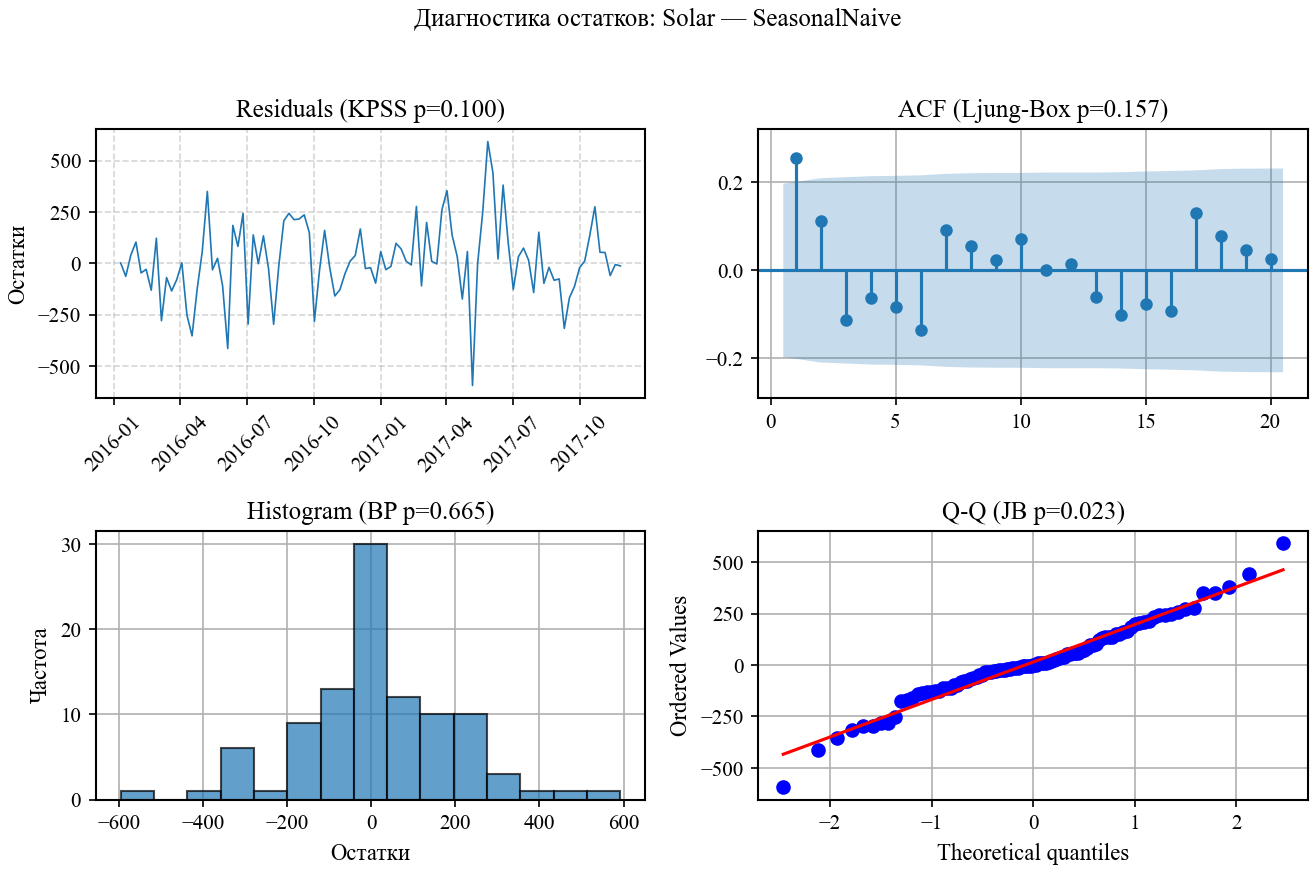

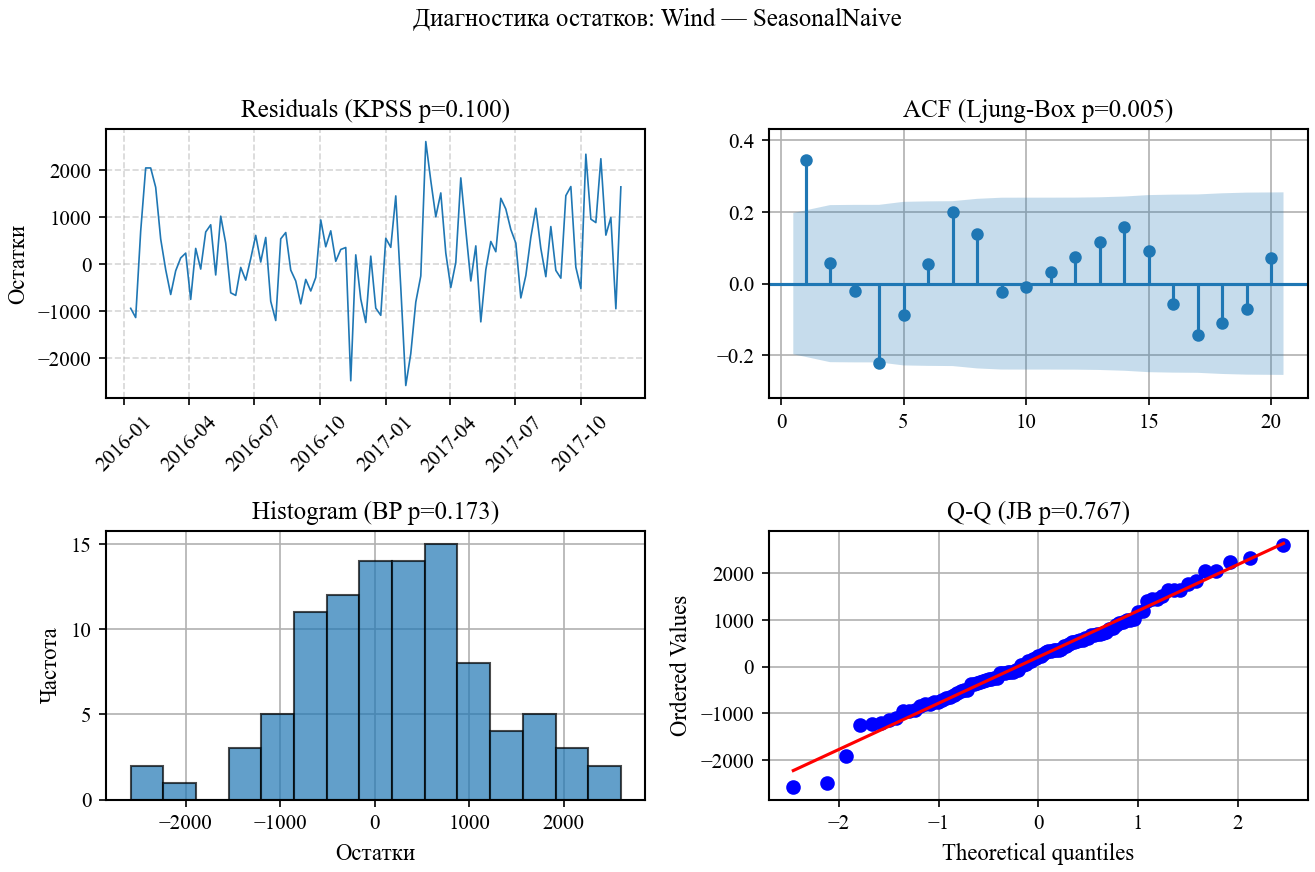

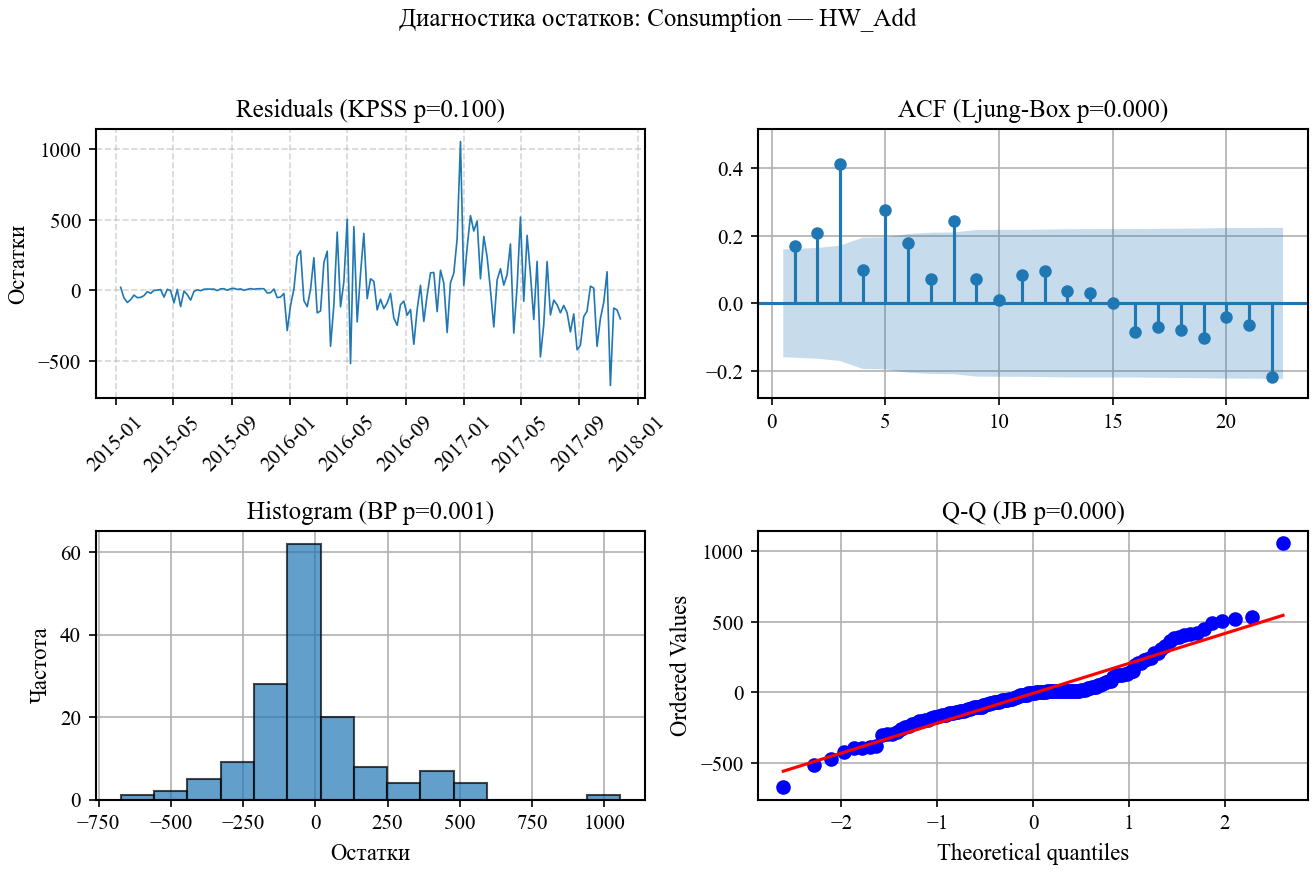

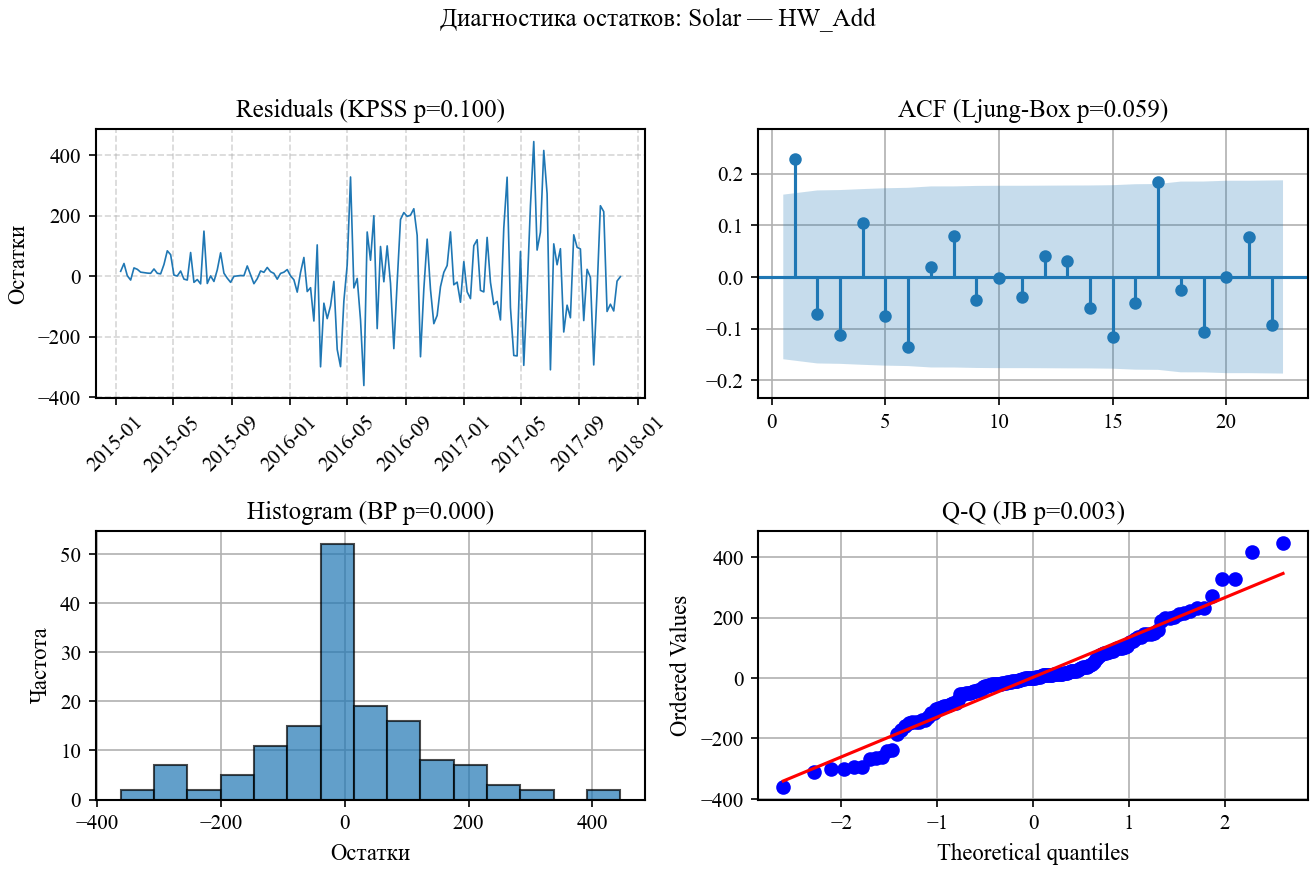

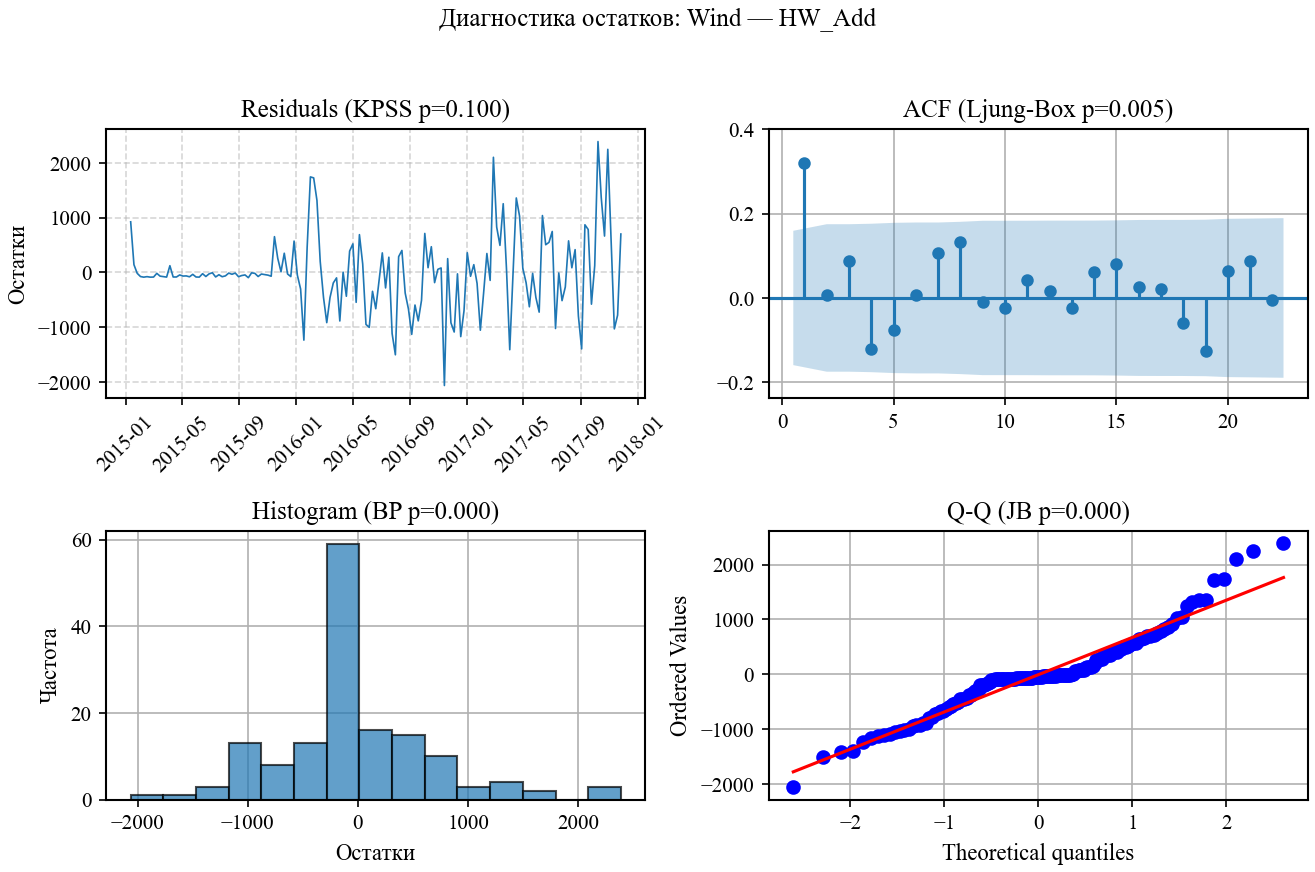

In [15]:
resid_cols = [col for col in fitted_values.columns if col.startswith('resid_')]
for resid_col in resid_cols:
    for uid in  fitted_values['unique_id'].unique():
        subset = fitted_values[(fitted_values['unique_id'] == uid)]        
        plot_model_diagnostics(subset, resid_col=resid_col, title_suffix=f"— {resid_col[6:]}")
    print('=='*30)

Отметим интересную особенность, что в seasonal naive остатки имеют близкое к нормальному поведению, что вероятно следует объяснять значительной величиной шума.

Также обратите внимание, что seasonal naive имеет in_sample только для 1 года.

#### Упражнение
1. Провести оценку остатков для базовых моделей `ARIMA, Prophet, ETS, SeasonalExponentialSmoothingOptimized`, сравните модели и выберите лучшую 

### Сравнение моделей по остаткам на валидационной выборке

Если для набора моделей имеется как тренировочная, так и валидационная подвыборки. То есть обе выборки имеют известные значения ВР, то __к сравнению моделей__ следует добавить тест на значимость статистических различий. 


Среди таких тестов наиболее распространен [__тест Диболда-Мариано__](http://www.machinelearning.ru/wiki/index.php?title=%D0%9A%D1%80%D0%B8%D1%82%D0%B5%D1%80%D0%B8%D0%B9_%D0%94%D0%B8%D0%B1%D0%BE%D0%BB%D0%B4%D0%B0-%D0%9C%D0%B0%D1%80%D0%B8%D0%B0%D0%BD%D0%BE). Тест предполагает анализ [разности метрики остатков](https://github.com/johntwk/Diebold-Mariano-Test/tree/master) (по сути MAE). Тест устойчив к некоторым отклонениям остатков от предположений о нормальности и допускает небольшую скоррелированность или бочную скорелированность остатков.

[Основная идея теста](https://real-statistics.com/time-series-analysis/forecasting-accuracy/diebold-mariano-test/) заключается в сравнении флуктуаций нормированных разности ошибок (остатков) моделей с нормальным  распределением.

В тесте проверяются гипотезы:
- $H_0$ качество прогнозов обеих моделей одидинаково,
- $H_1$ альтернативная гипотеза.

Тест возможно выполнять как для калссической процедуры оценки Диболда-Мариано, так и для процедуры с поправкой на размер выборки Harvey, Leybourne, and Newbold (HLN) (рекомендуется для <100 точек).

Также тест позволяет проводить бутсреп оценку (по подвыборкам с возвратом).

В дополнение к тесту проверм 
- силу эффекта как разность ошибок (diff_mae) - чем больше, тем лучше
- effect_size [(Cohens d_z test)](https://mbrenndoerfer.com/writing/effect-sizes-statistical-significance-cohens-d-practical-significance) - чем выше, тем лучше
- включает ли 95% разброс ошибок diff_mae [ci_low, ci_high] 0 (если не включает, то эффект имеет место на всем горизонте прогноза).


In [16]:
models = [SeasonalNaive(SEASON),
          # SeasonalExponentialSmoothingOptimized(SEASON),
          HoltWinters(season_length=SEASON, error_type="A", alias="HW_Add"), 
          # AutoETS(SEASON, 'ZZA')
         ]
model_names = [model.alias for model in models]

In [17]:
fcst = sf.forecast(h=FH, df=df_train, fitted=True)
eval_sf = df_test.merge(fcst, on=['unique_id', 'ds'])

In [18]:
dm_test(eval_sf, loss = 'mae', models=['SeasonalNaive','HW_Add'], by_series = True) 

,unique_id,model_1,model_2,dm_stat,p_value,significant,better_model,metric_value,effect_size,ci_low,ci_high,is_0_in_CI,correction_applied,n_obs
0,Consumption,SeasonalNaive,HW_Add,-2.242629,0.026982,True,SeasonalNaive,-55.061604,-0.215797,-137.321740,21.036923,True,hln,108
1,Solar,SeasonalNaive,HW_Add,1.247578,0.214909,False,HW_Add,15.985663,0.120048,-3.636514,35.965907,True,hln,108
2,Wind,SeasonalNaive,HW_Add,1.675002,0.096854,False,HW_Add,103.918556,0.161177,29.359100,177.719892,False,hln,108


In [19]:
dm_test(eval_sf, loss = 'mae', models=['SeasonalNaive','HW_Add'], by_series = False) 

,model_1,model_2,dm_stat,p_value,significant,better_model,metric_value,effect_size,ci_low,ci_high,is_0_in_CI,correction_applied,n_obs
0,SeasonalNaive,HW_Add,0.945294,0.345215,False,HW_Add,21.614205,0.052516,-26.788685,73.088476,True,hln,324


 В почти случае HW_Add модель несколько лучше, чем SeasonalNaive. Однако, эффект не значительный, при этом HW_Add имеет боьлше параметров (хуже по информационному критерию).

 __Отметим__ что тест подходит для парного сравнения. При множественном сравнении изначально нужно провести тест на существование различий в результатах моделей.

## Продвинутая валидация модели модели


### Walk-forward validation / Rolling Validation / backtesting

Ранее валидация моделей проводилась путем одноразового деления ВР на последовательные участки тренировки и валидации. Однако в силу присущей ВР нестационарности поведения такой подходя может привести к слишьком не точным (как правило слишьком оптимистичным) результатам. 
Самый простой способ  повышения надежности  валидации моделей ВР - мы можем  разделить  набор данных несколько раз по аналогии с методом `k-folds`. Однако, в соответствии с особенностями временных рядов - временной связанностью метод`k-folds` должен [не нарушать принцип казуальности](https://forecastegy.com/posts/time-series-cross-validation-python/). Другими словами [выборка валидации должна следовать за тренировочными данными](https://otexts.com/fpp3/tscv.html). __Такой подход также известен как [<tt>backtesting/ walk-forward validation</tt>](https://joaquinamatrodrigo.github.io/skforecast/0.8.1/user_guides/backtesting.html)__.

>Напомним, результат [кросс-валидации](https://www.statology.org/k-fold-cross-validation/) по нескольким блокам более валиден [(менее смещен)](https://machinelearningmastery.com/k-fold-cross-validation/), нежели валидация одной [отложенной выборкой](https://scikit-learn.org/stable/modules/cross_validation.html).

>__Backtesting (ретроспективное тестирование)__ и __walk-forward validation  (пошаговая валидация)__ часто используются как синонимы, но в строгом смысле они отражают разные варианты  одного и того же принципа.
>
>__Walk-forward validation__ -  процедура при которой: начальное обучающее окно фиксируется (например, первые 365 дней),
модель тестируется на следующем коротком интервале (например, 7 дней), затем обучающее окно расширяется (или сдвигается), включая данные, использованные для теста, процесс повторяется до конца выборки.
>
>__Backtesting__ не имеет конкретного алгоритма , но часто преполагает проверку точности модели на последовательности интервалов без дообучения - то есть имитация работы модели в реальной среде. Ближе всего к этому определению подходит стратегия, когда окон тренировки выбирается один раз,а тест осуществляется на наборе последовательных окон.

В случае временного ряда кросс валидация может быть выполнена в скользящем окне по данным  [<tt>rolling backtest evaluation</tt>](https://docs.aws.amazon.com/whitepapers/latest/time-series-forecasting-principles-with-amazon-forecast/step-4-evaluate-predictors.html#prediction-quantiles-and-accuracy-metrics).
> [Приемущественно метода](https://mydata.ch/backtesting-in-time-series-forecasting-for-maximum-performance/)  бектеста скользящим окном следующие:
>* позволяет  быть уверенным, что  прогнозы точны и последовательны в течение длительного периода времени.
>* может помочь  найти и исправить "плавоющие" ошибки в модели данных. То есть редкие, но достаточно регулярные ошибки (неучтенную информоацию), которые можно участь в модели.
>* может помочь выявить недостающие внешние факторы в данных, которые помогут модели делать более точные прогнозы.
<!-- ✅It allows you to ensure that your forecasts are accurate and consistent over a long period of time

✅It can help you to find and correct errors in your models.

✅It can help you to identify missing external factors in your data that would help the model make better forecasts -->

>Напомним, что в прогнозировании временных рядов под <tt>бэктестингом</tt> понимается процесс проверки модели прогноза на исторических данных. Этот метод предполагает пошаговое движение назад во времени, чтобы оценить, насколько хорошо показала бы себя модель, если бы она использовалась для прогнозирования в этот период времени.

С технической точки зрения идея тут [заключается следующем](https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/backtesting.html). Задается некторая ширина окна временного ряда. Заданное окно скользит по временному ряду с начального положения, например, таким образом, что все данные перед ним являются тренировочными, а после тестовыми. Могут быть и [другие стратегии](https://www.sktime.net/en/stable/examples/forecasting/window_splitters.html), например, что только лишь выборка заданного размера перед окном является тренировочной. Такие стратегии называются `ExpandingWindowSplitter` и `SlidingWindowSplitter` соответственно.

Для использования данных стратегий рекомендуем задавать оконо списком чисел вместо дат. Попробуем для начала визуализировать `ExpandingWindowSplitter`

> Отметим что по своей идеалогии данная процедура аналогична тому, что модель бы тестировалась на поступающих данных в соответствующих рабочих режмах. При этом целью такого тестирования бы была оценка работоспособности модели. Другими словами тестирование гипотезы о необходимости сменить модель (например переобучить). Такая процедура называется [<tt>walk-forward validation</tt>](https://machinelearningmastery.com/backtest-machine-learning-models-time-series-forecasting/).

<!-- In time series forecasting, backtesting refers to the process of validating a predictive model using historical data. The technique involves moving backwards in time, step-by-step, to assess how well a model would have performed if it had been used to make predictions during that time period. -->

### ExpandingWindowSplitter

#### statsforecast `cross_validation`

##### Синтексис

Используем метод [`cross_validation`](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/cross_validation.html) для обучения и оценки моделей. В данном случае это будет аналог `ExtendedWindowCV` рассмотренного ранее. Здадим следующие парамерты:
* `df`: Получает обучающие данные 
* `h`: Горизонт прогнозирования 
* `n_windows`: Количество слайдов, которые мы хотим спрогнозировать.
* `step_size`: шаг между окнами
* `refit=True`: Для каждого окна прогноз будет обновлен заново.

<!-- Также можно задать имена столбцов временного ряда: 
+ `id_col`:Столбец, идентифицирующий каждый ВР (по умолчанию уникальный_ид) 
+ `time_col`: Столбец, идентифицирующий каждый временной шаг, его значения могут быть временными метками или целыми числами (По умолчанию `ds`) 
+ `target_col`:Столбец, содержащий целевой ВР (По умолчанию `y`) -->

Отметим что в полеченных результатах будут показаны:
* `cutoff`: последняя временная метка для каждого из `n_windows`.
* `models`: набор столбцов для моделей

> Напомним, что `ExtendedWindowCV` может быть [отображен как](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/cross_validation.html):

<img src="https://i.sstatic.net/fXZ6k.png" width="500px">

##### Модели

In [20]:
models = [
    # SeasonalExponentialSmoothingOptimized(SEASON),    
    HoltWinters(season_length=SEASON, error_type="A", alias="HW_Add")
]
model_names = [getattr(m, 'alias', type(m).__name__) for m in models]

In [21]:
sf = StatsForecast(models=models, freq=FREQ) 

##### Валидация

Зададим парамтры валидации словарем - они нам еще понадобятся 

In [22]:
cv_conf = dict(h=FH//2,
           n_windows=8,
           step_size=FH//16, 
           refit=True,  )  

Встроенная процедура кросс-валидации

In [23]:
cv_df = sf.cross_validation(
    df=panel_df, 
    **cv_conf
)

Результат кросс-валидации содержит столбец `cutoff`.

Значения __`cutoff`__ - это точки начала горизонта предсказания. Для кажого значения  __`cutoff`__ строится предсказание на размер тестовой выборки.


In [24]:
cv_df = sf.cross_validation(
    df=panel_df, 
    **cv_conf
)
cv_df.head()

,unique_id,ds,cutoff,y,HW_Add
0,Consumption,2018-02-25,2018-02-18,10196.418,10152.618600
1,Consumption,2018-03-04,2018-02-18,10658.257,10022.211393
2,Consumption,2018-03-11,2018-02-18,9942.000,9996.206434
3,Consumption,2018-03-18,2018-02-18,10228.846,9809.713718
4,Consumption,2018-03-25,2018-02-18,10206.606,9498.617474


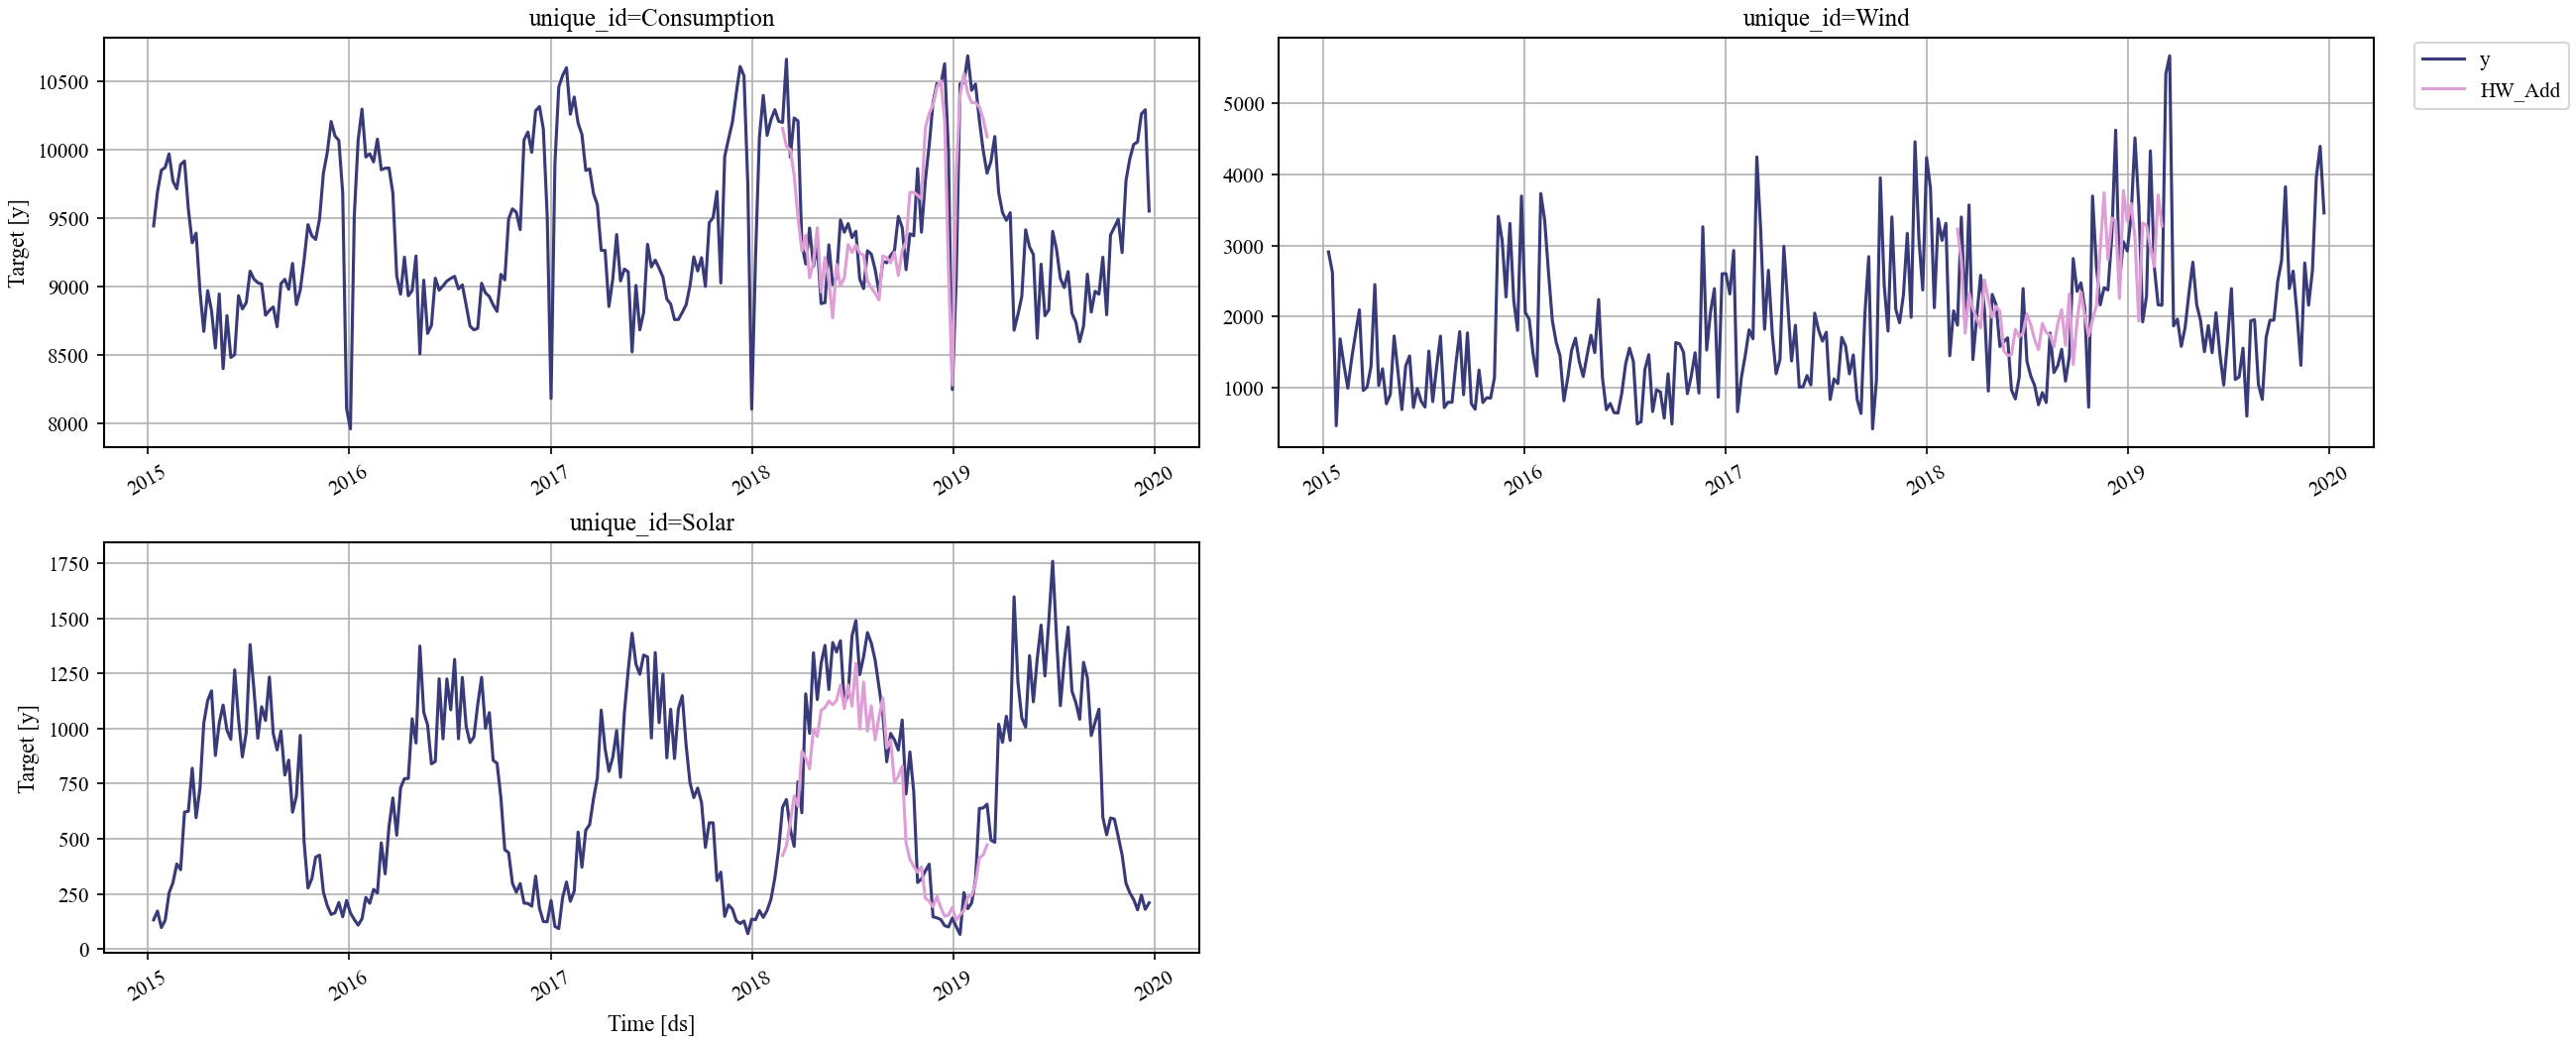

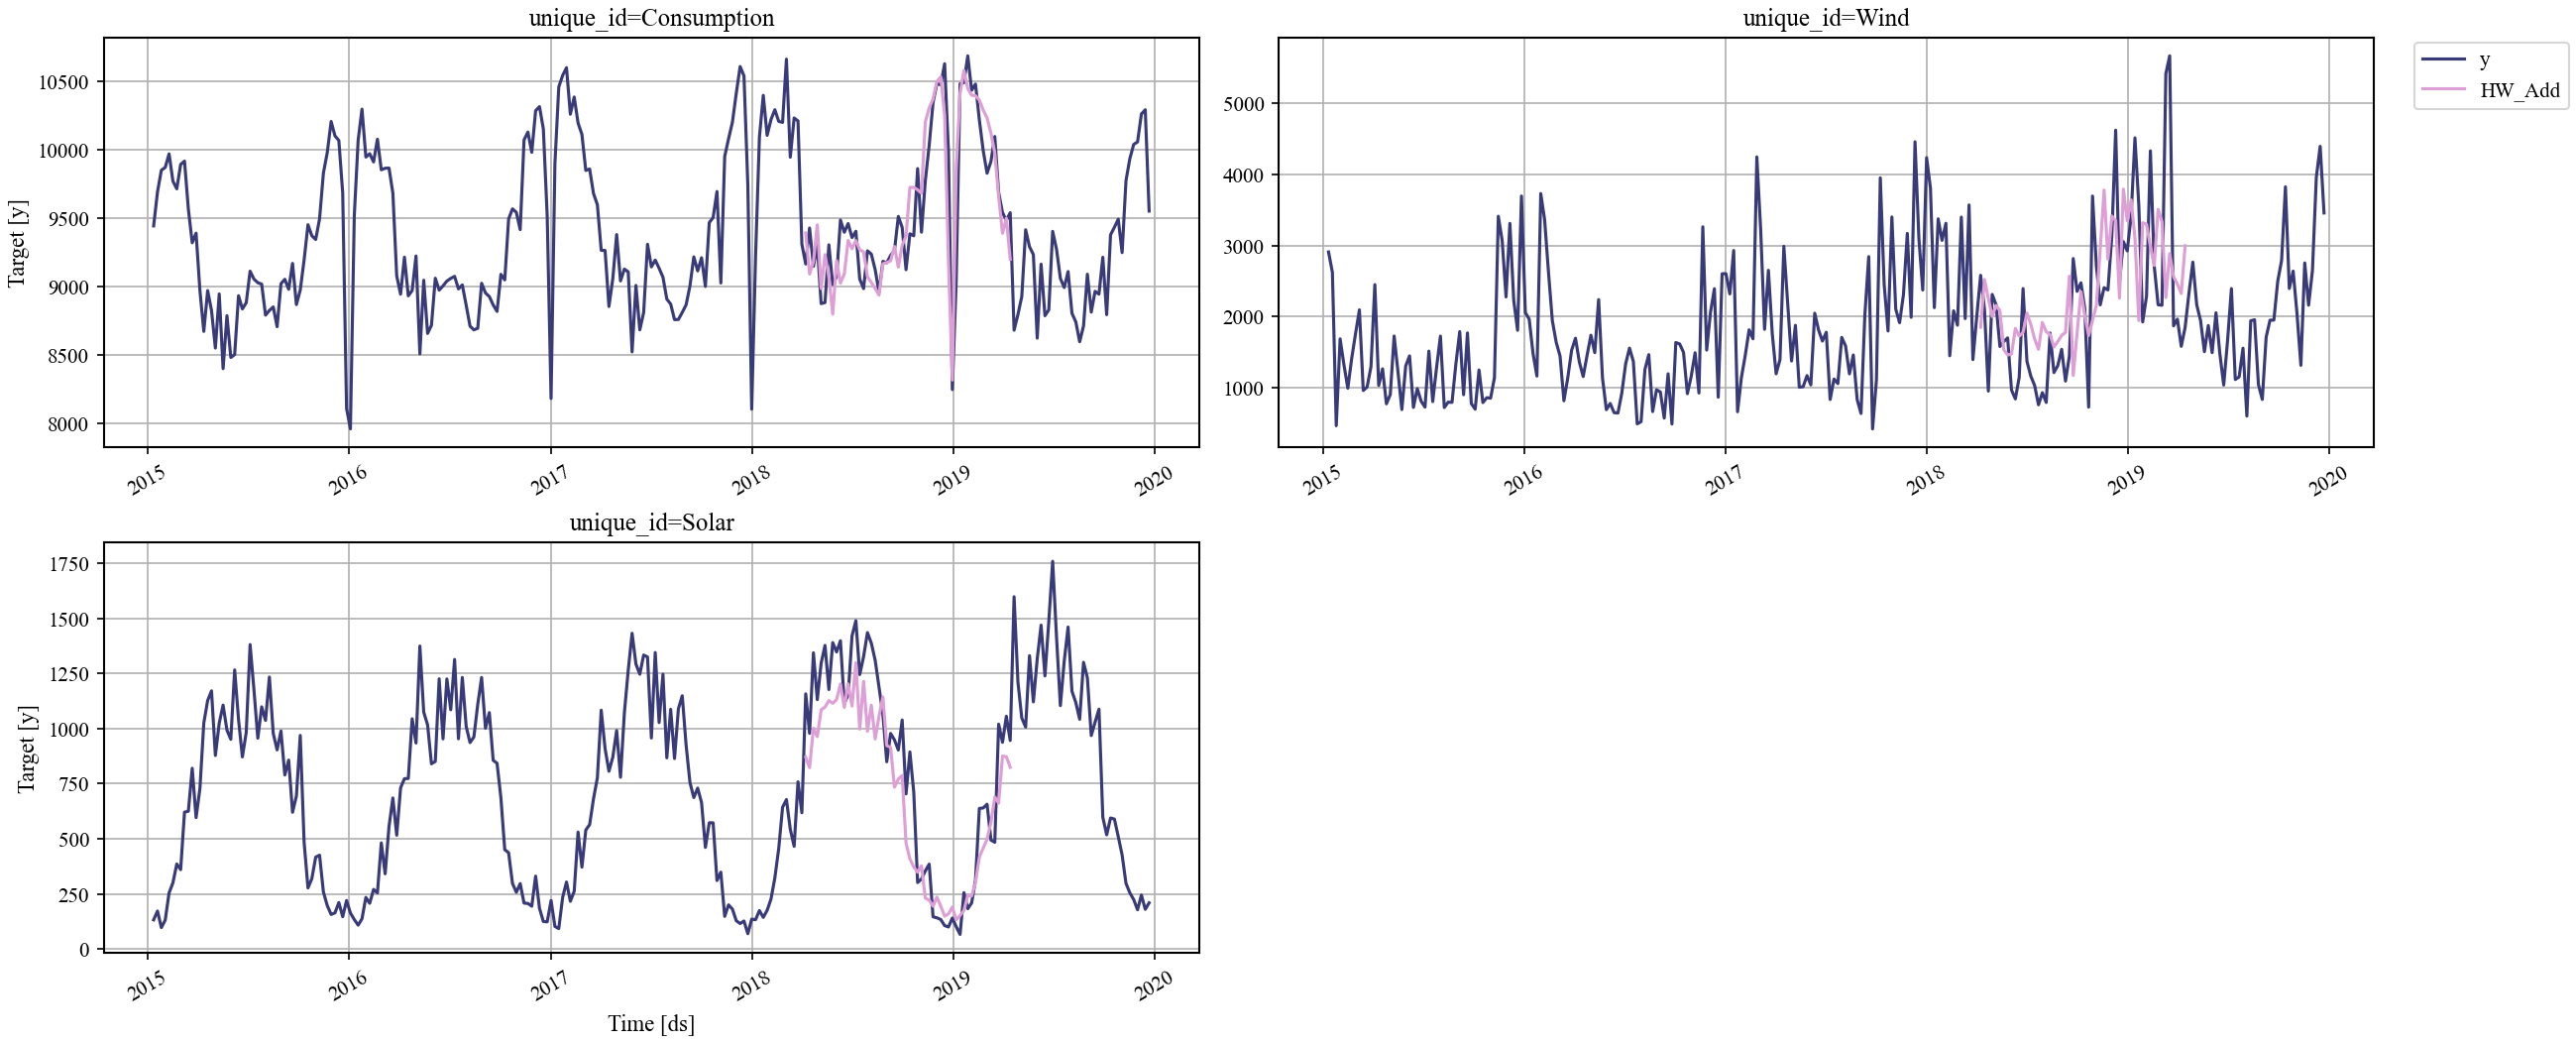

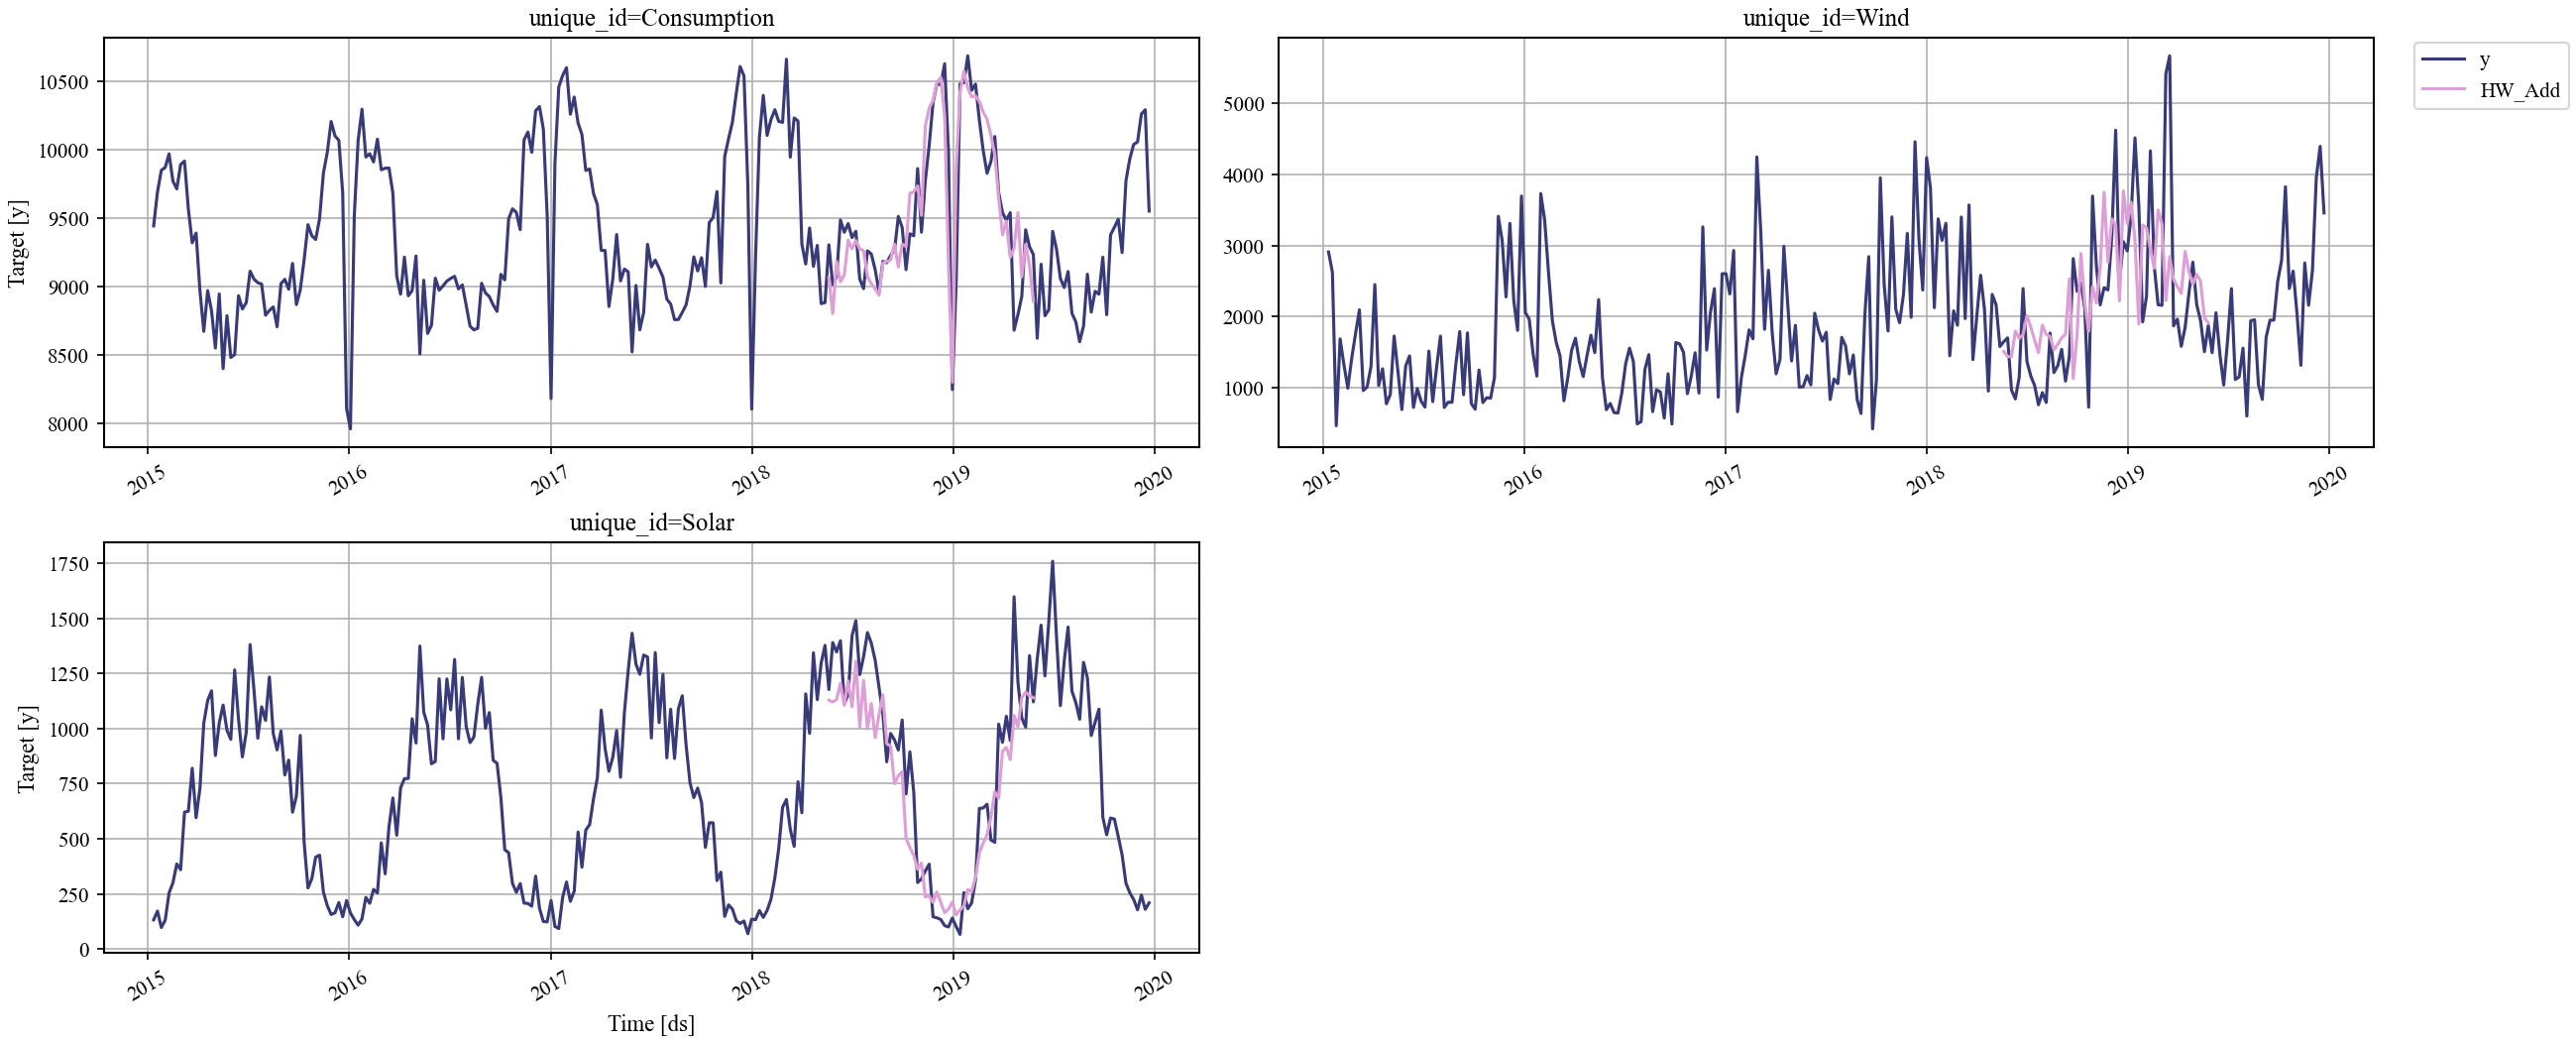

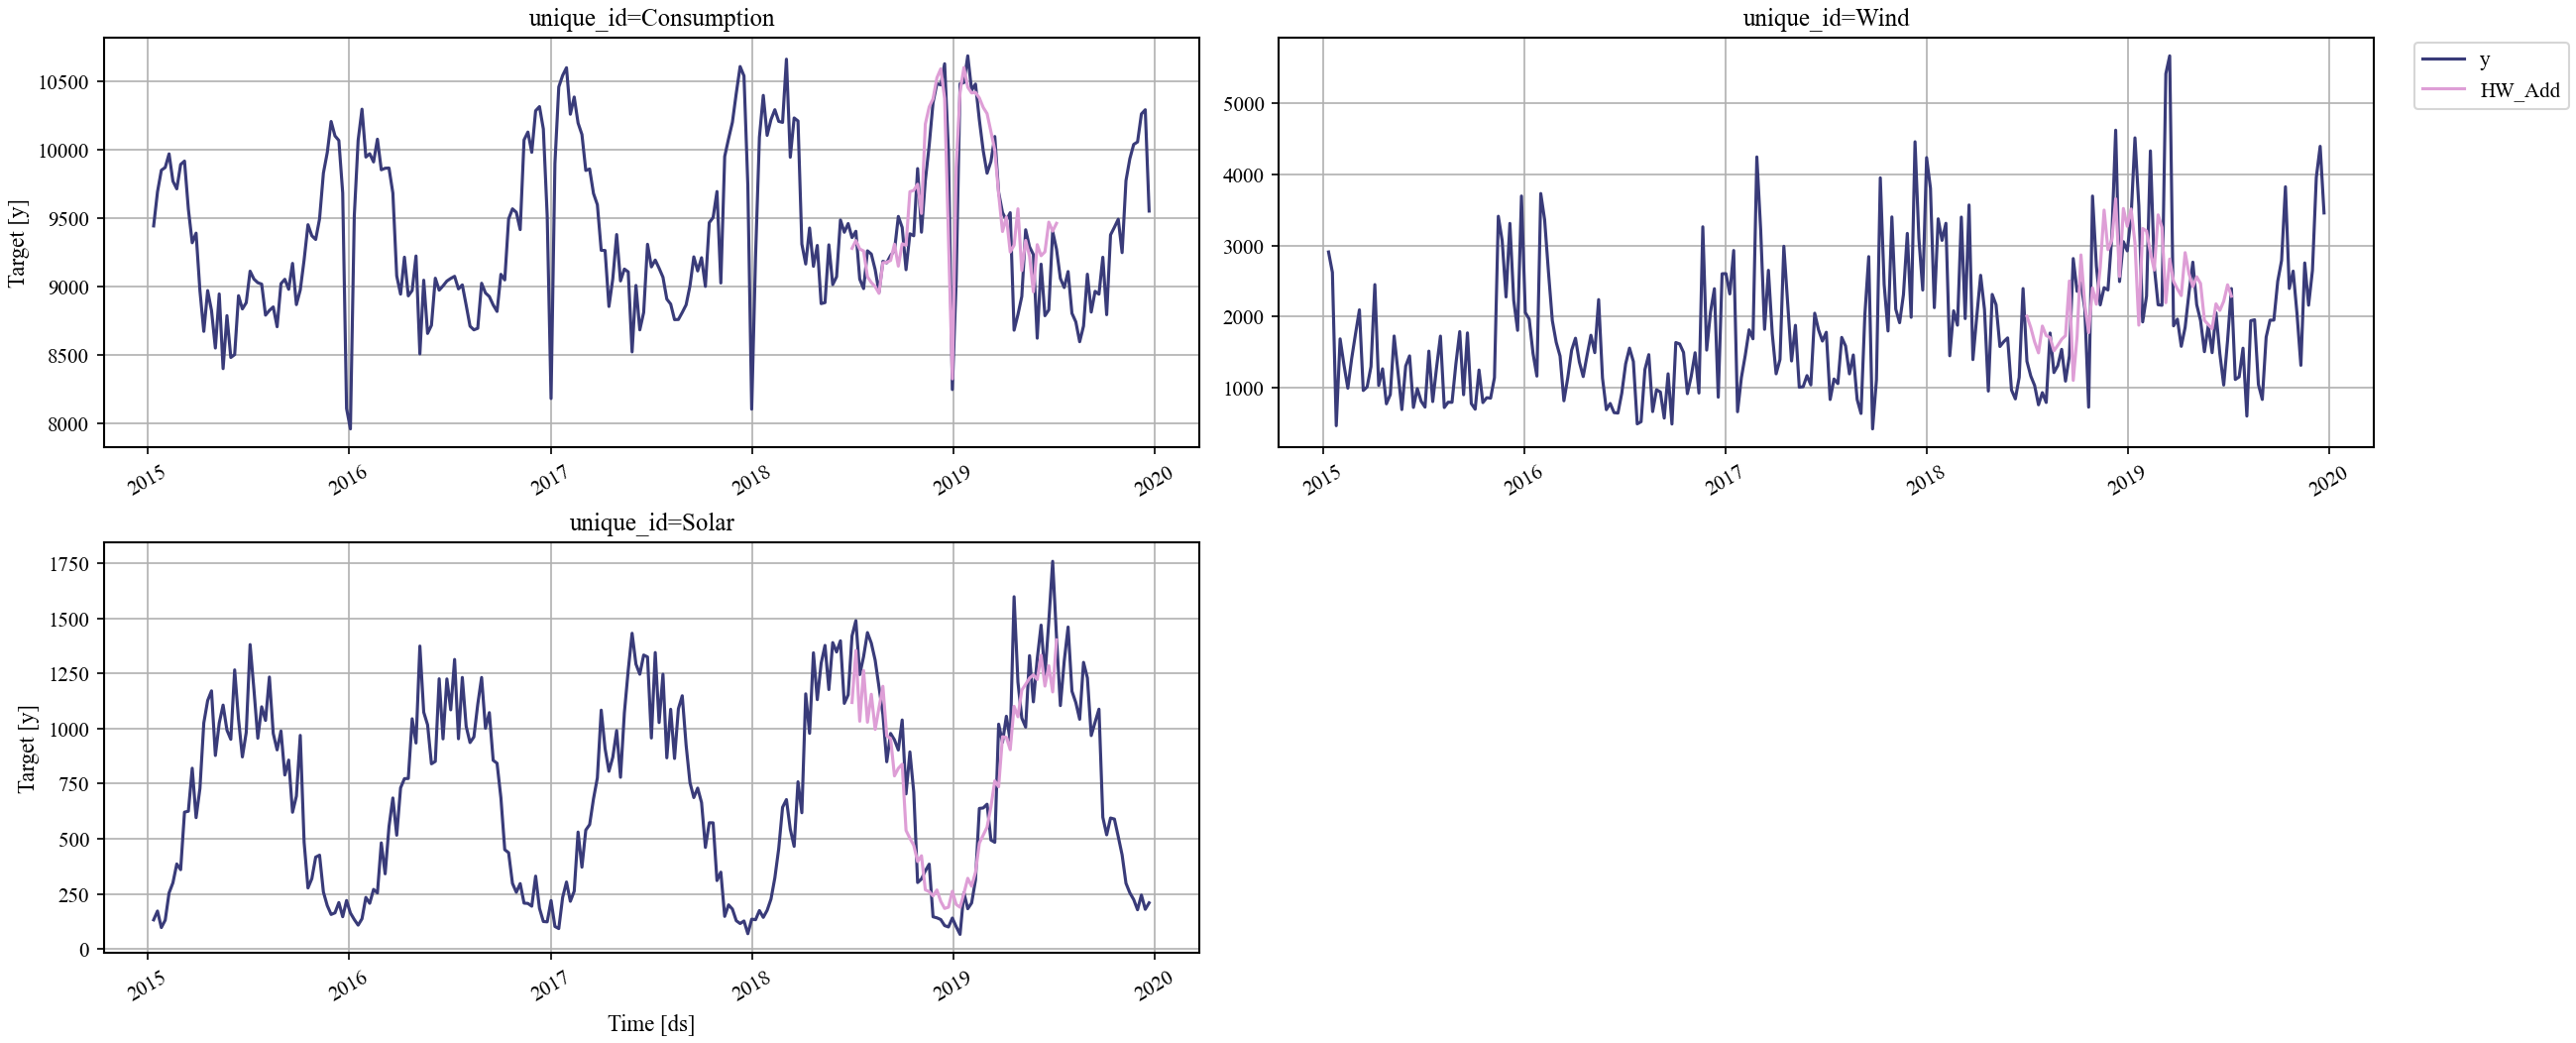

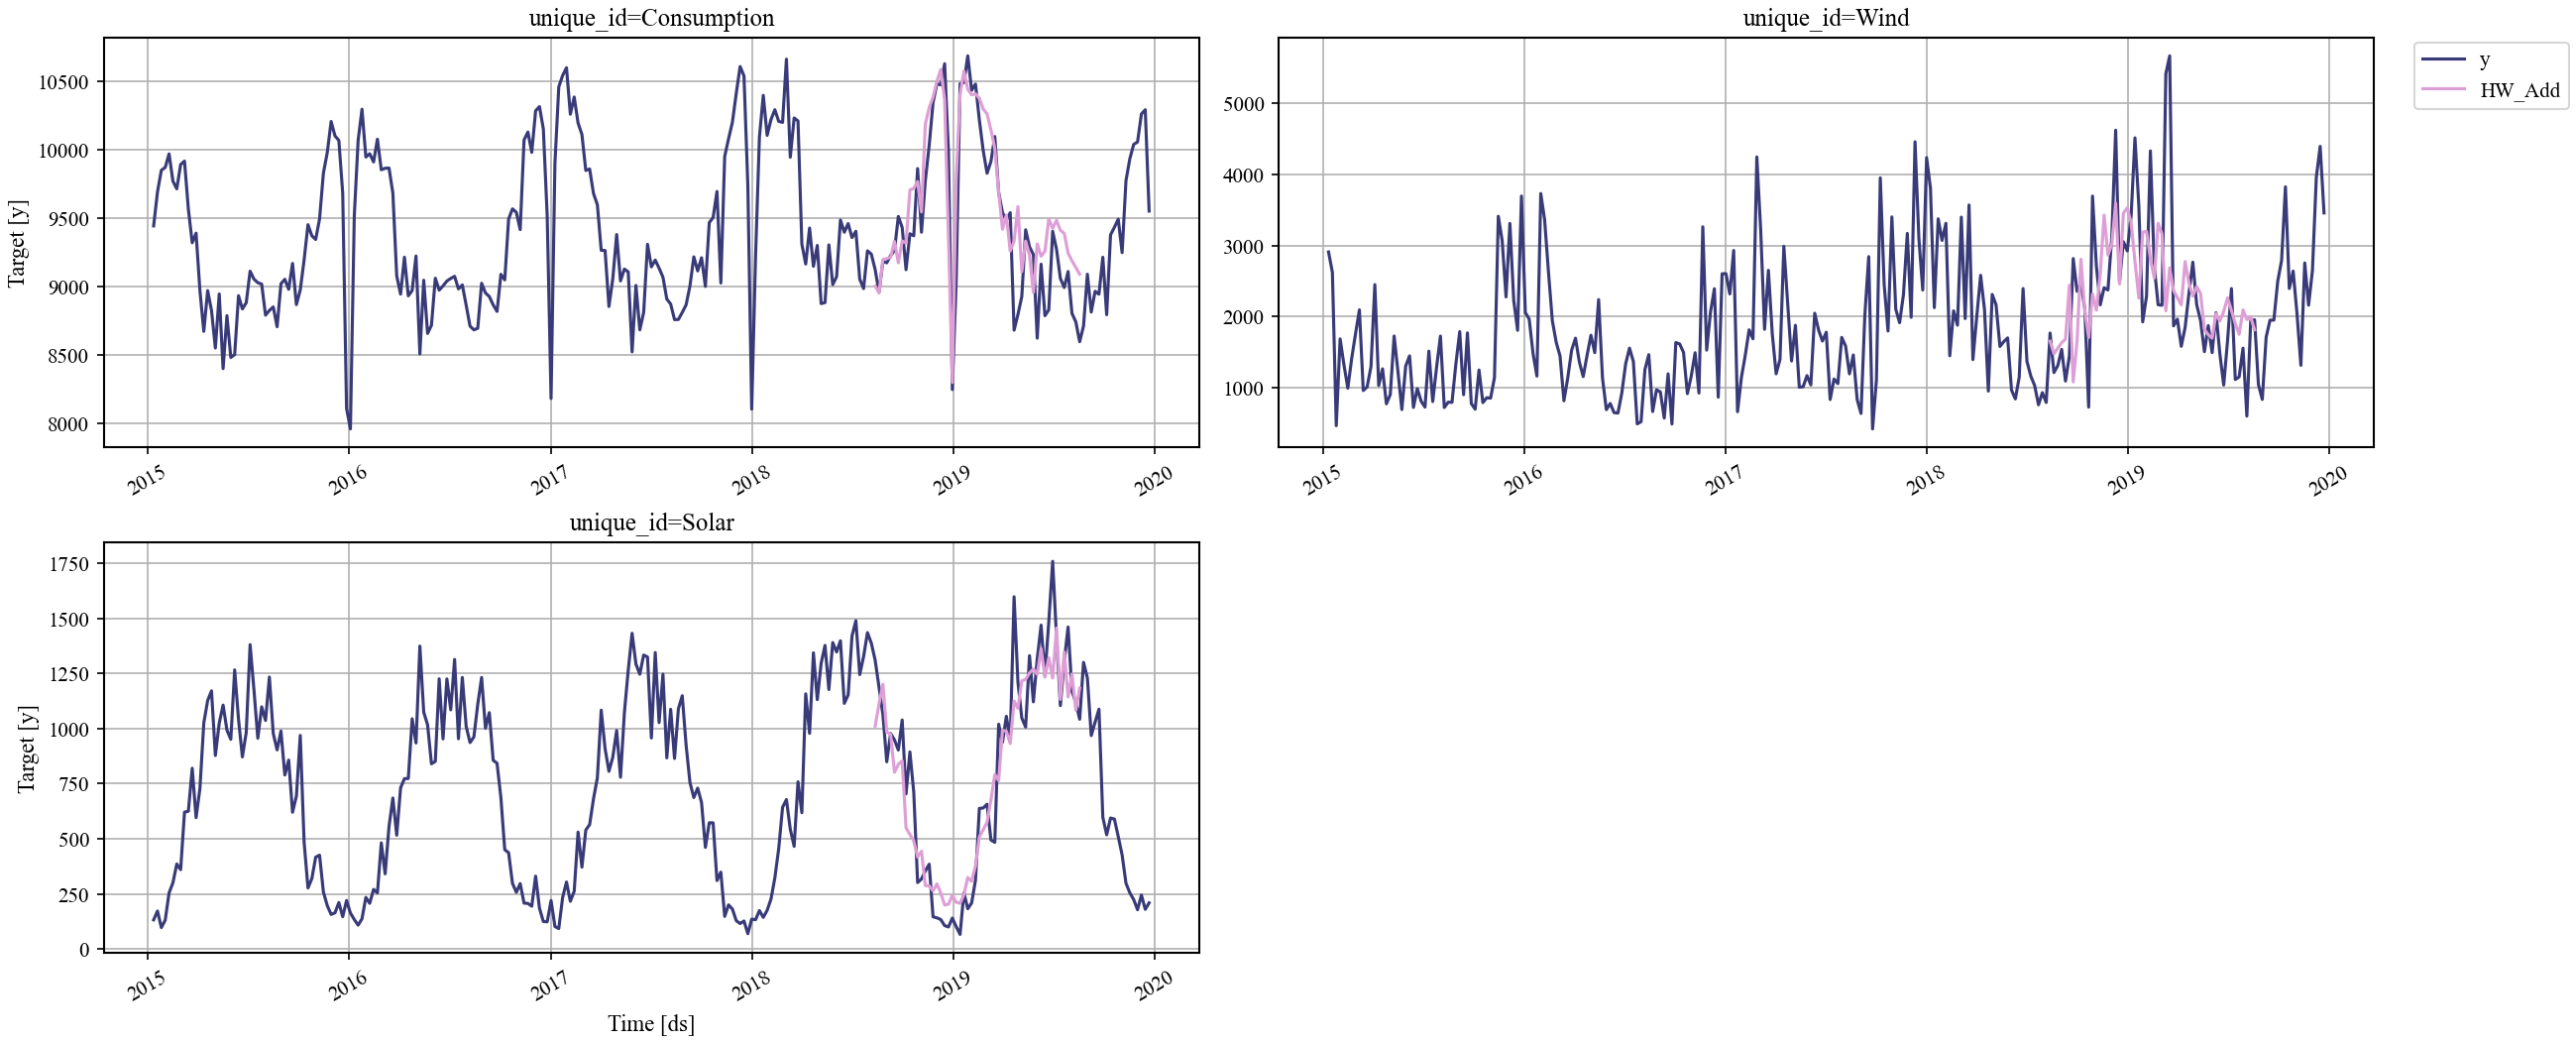

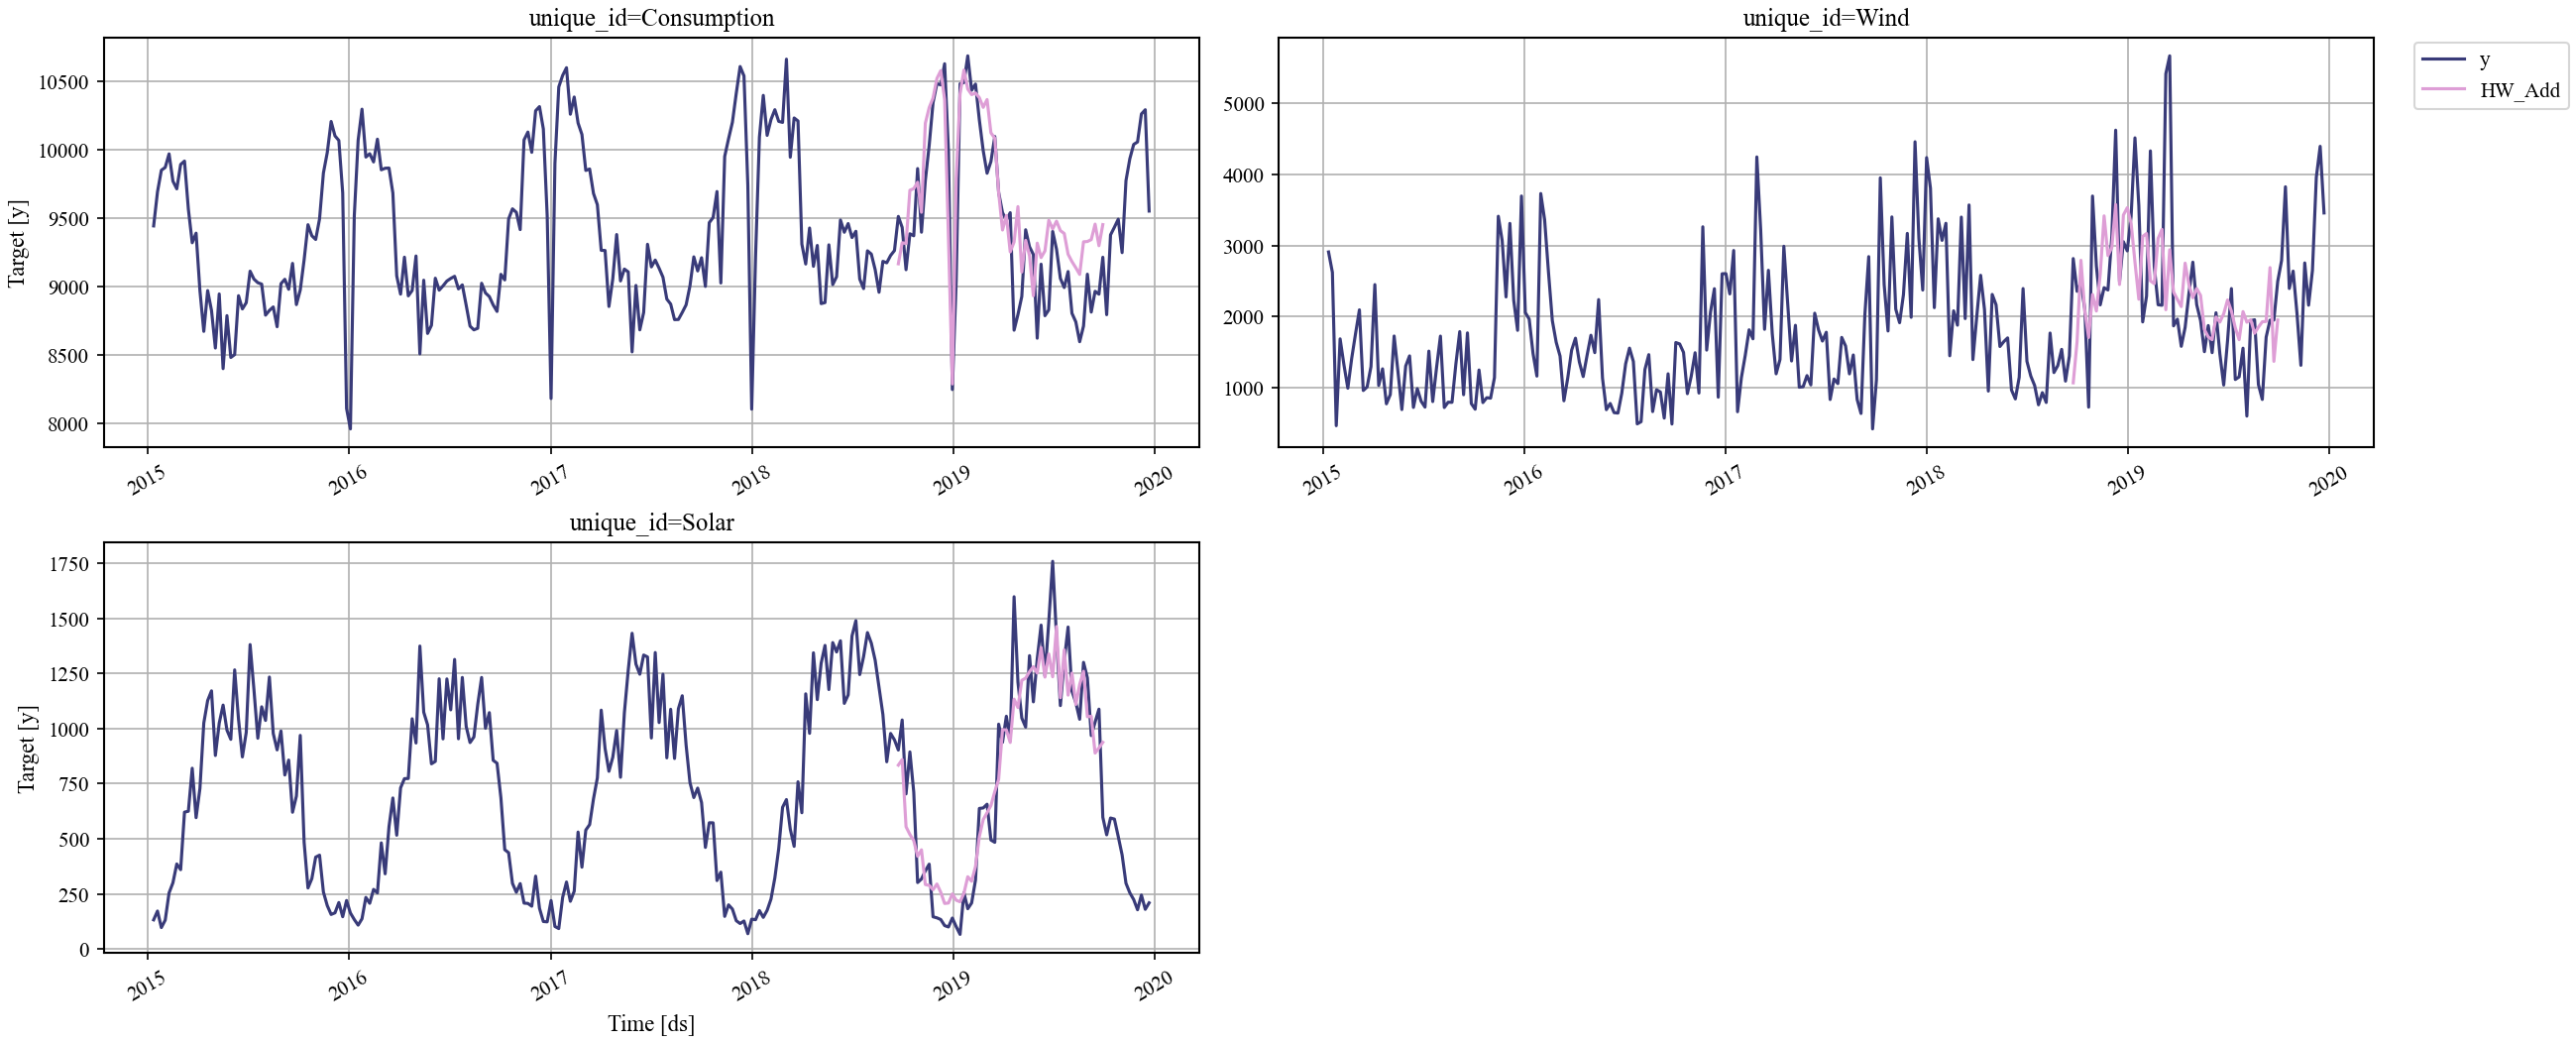

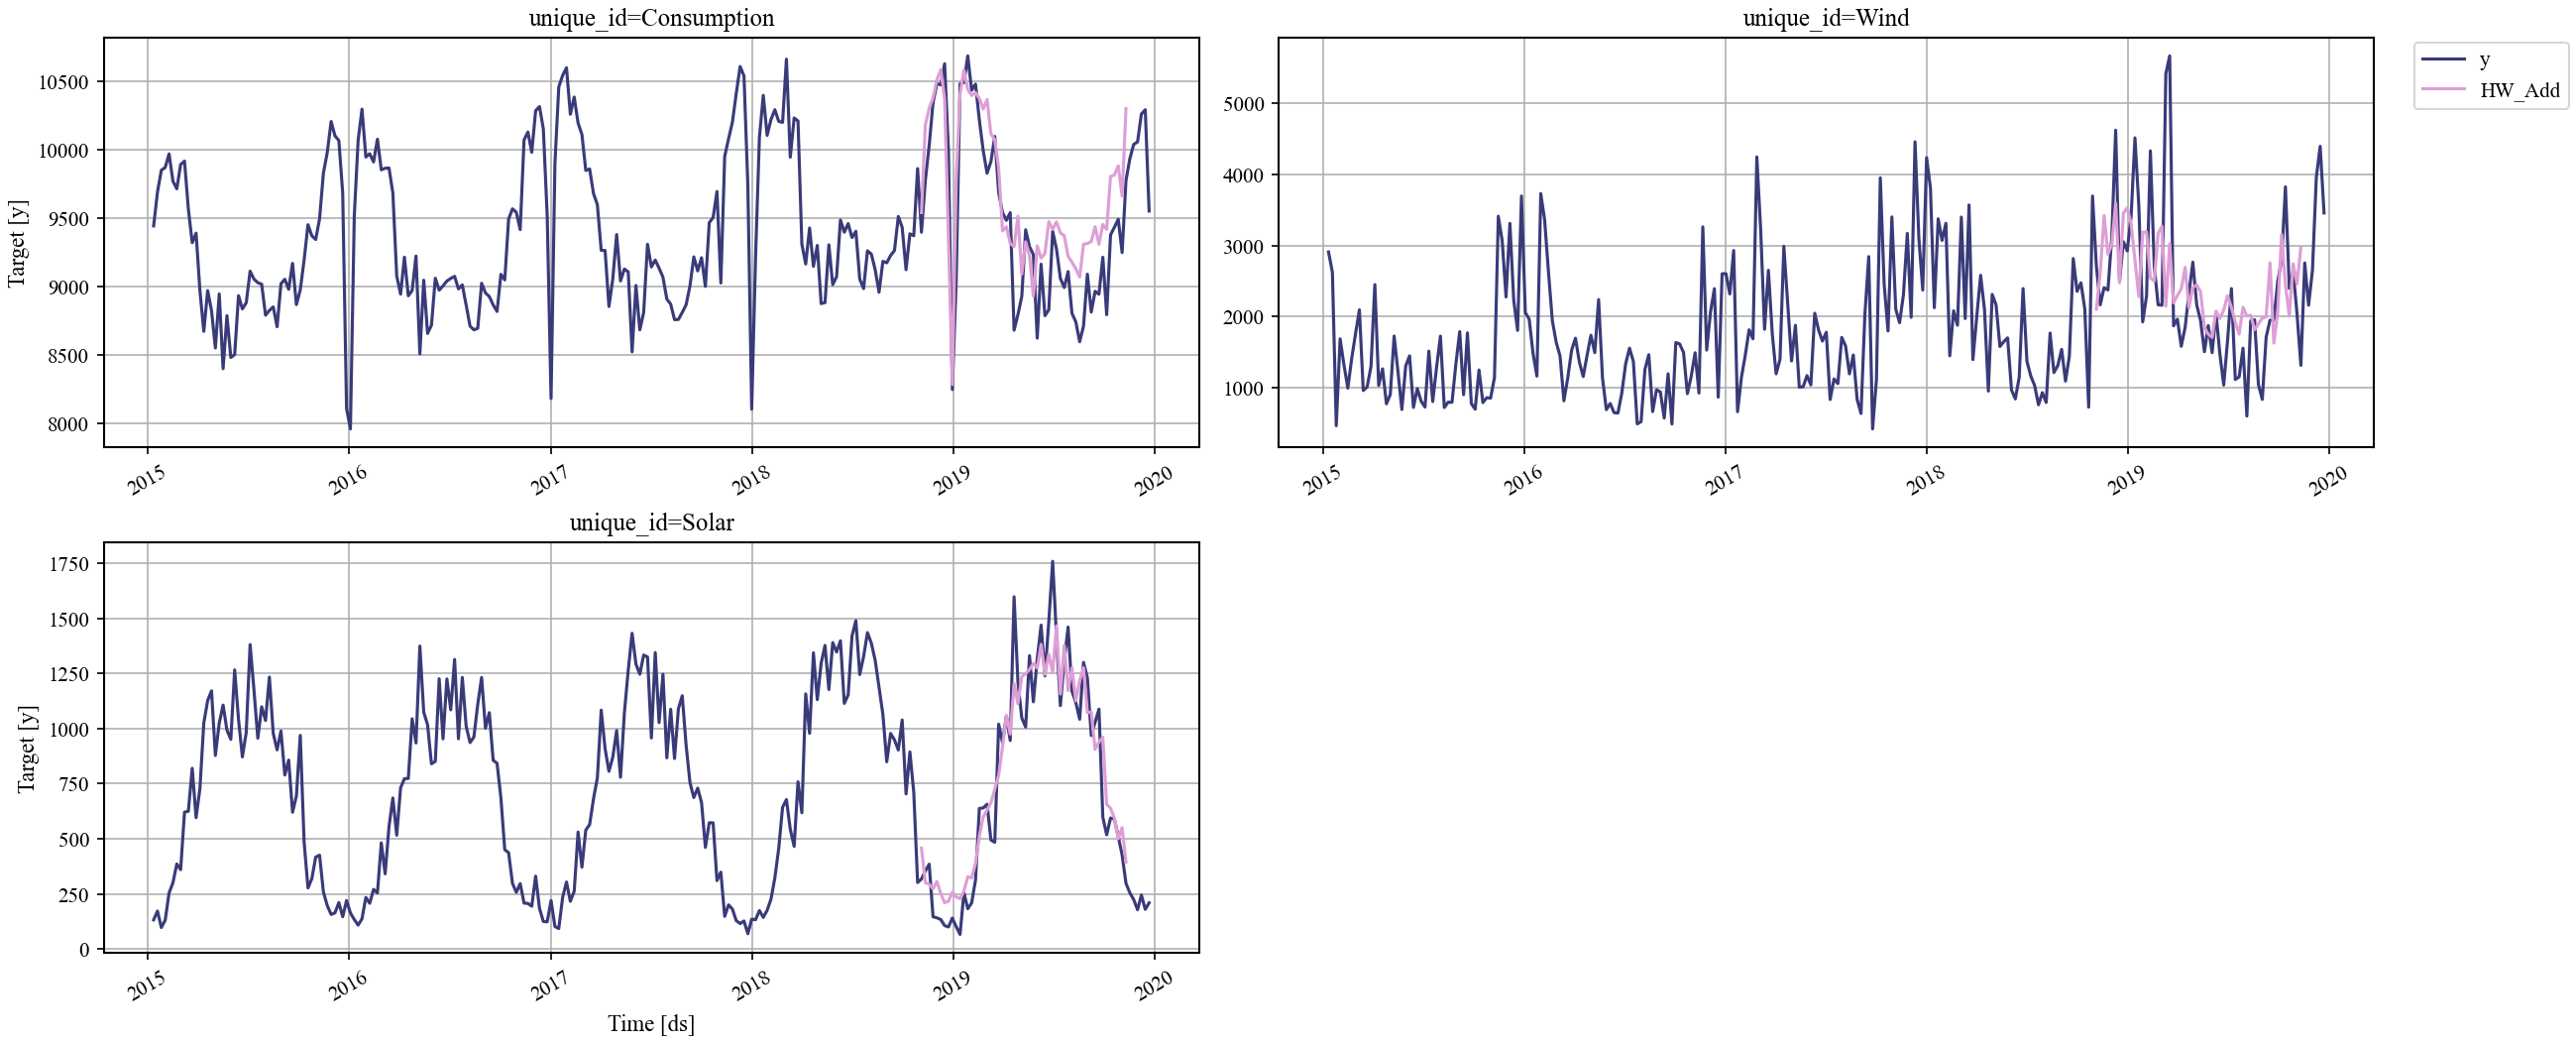

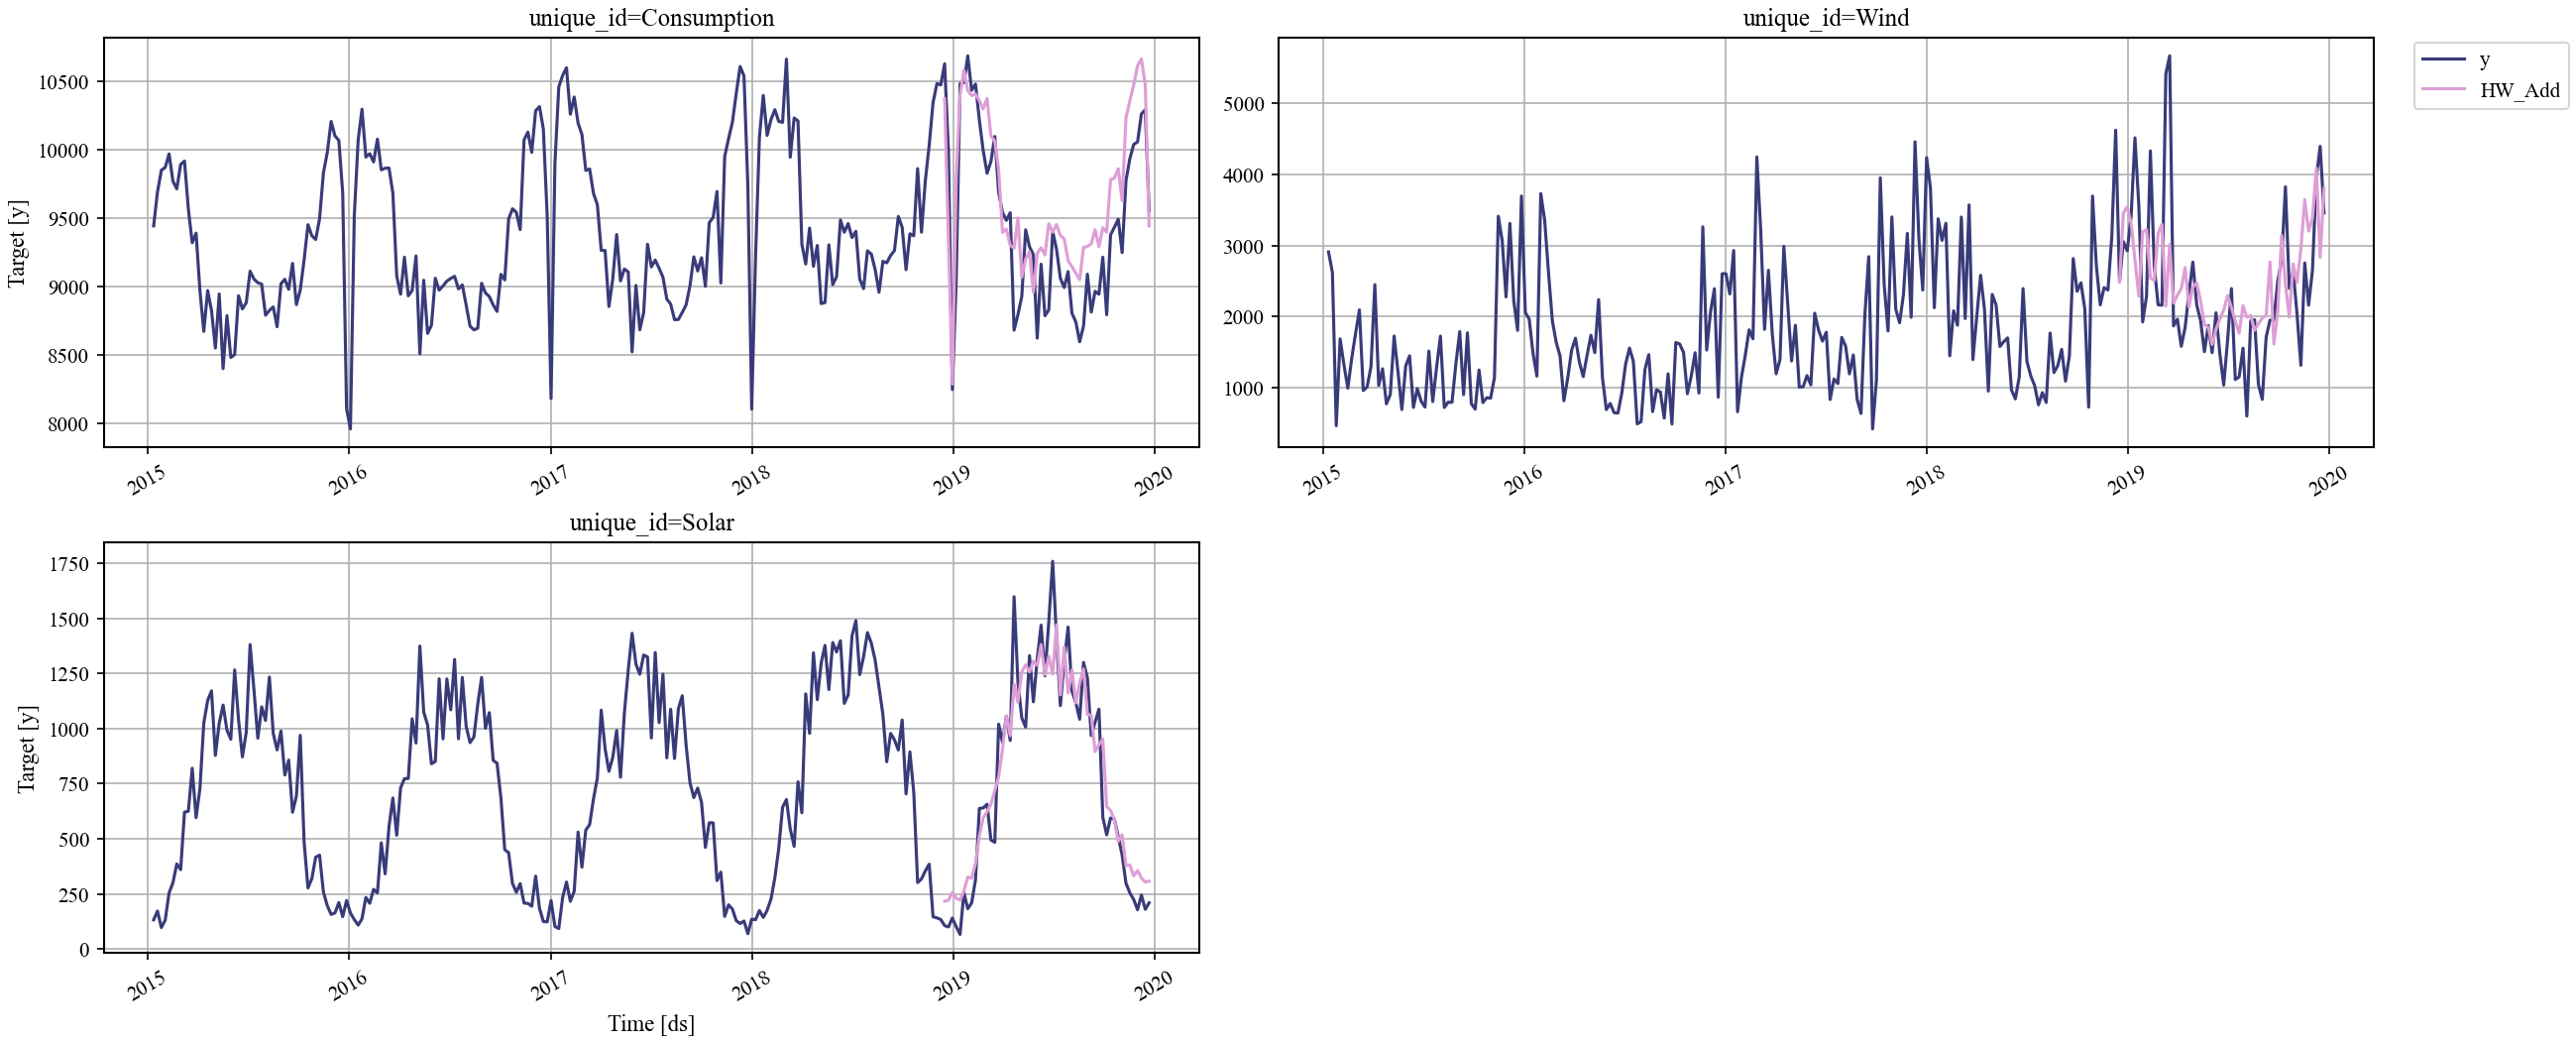

In [25]:
cutoff = cv_df['cutoff'].unique()
for k in range(len(cutoff)):
    cv = cv_df[cv_df['cutoff'] == cutoff[k]]
    display(StatsForecast.plot(panel_df, cv.loc[:, cv.columns != 'cutoff'].drop(columns = 'y')))

##### Провевим сколько окон получено (уникальные точки начала валидации)

In [26]:
cutoff = cv_df['cutoff'].unique()
cutoff

<DatetimeArray>
['2018-02-18 00:00:00', '2018-04-01 00:00:00', '2018-05-13 00:00:00',
 '2018-06-24 00:00:00', '2018-08-05 00:00:00', '2018-09-16 00:00:00',
 '2018-10-28 00:00:00', '2018-12-09 00:00:00']
Length: 8, dtype: datetime64[ns]

И так, получено заданное  `n_windows` число шагов кросс-валидации (сплитов)

### Визуализация сплитов

#### Expanding CV Windows

Попробуем визулизировать окона, которые мы получили. По умолчанию StatsForecast  предлагает стратегрию расширяющегося окна. То есть каждое следущее значение cutoff увеличивает тренировочную выборку и сдвигает тестовую выборку на знчение `step_size`

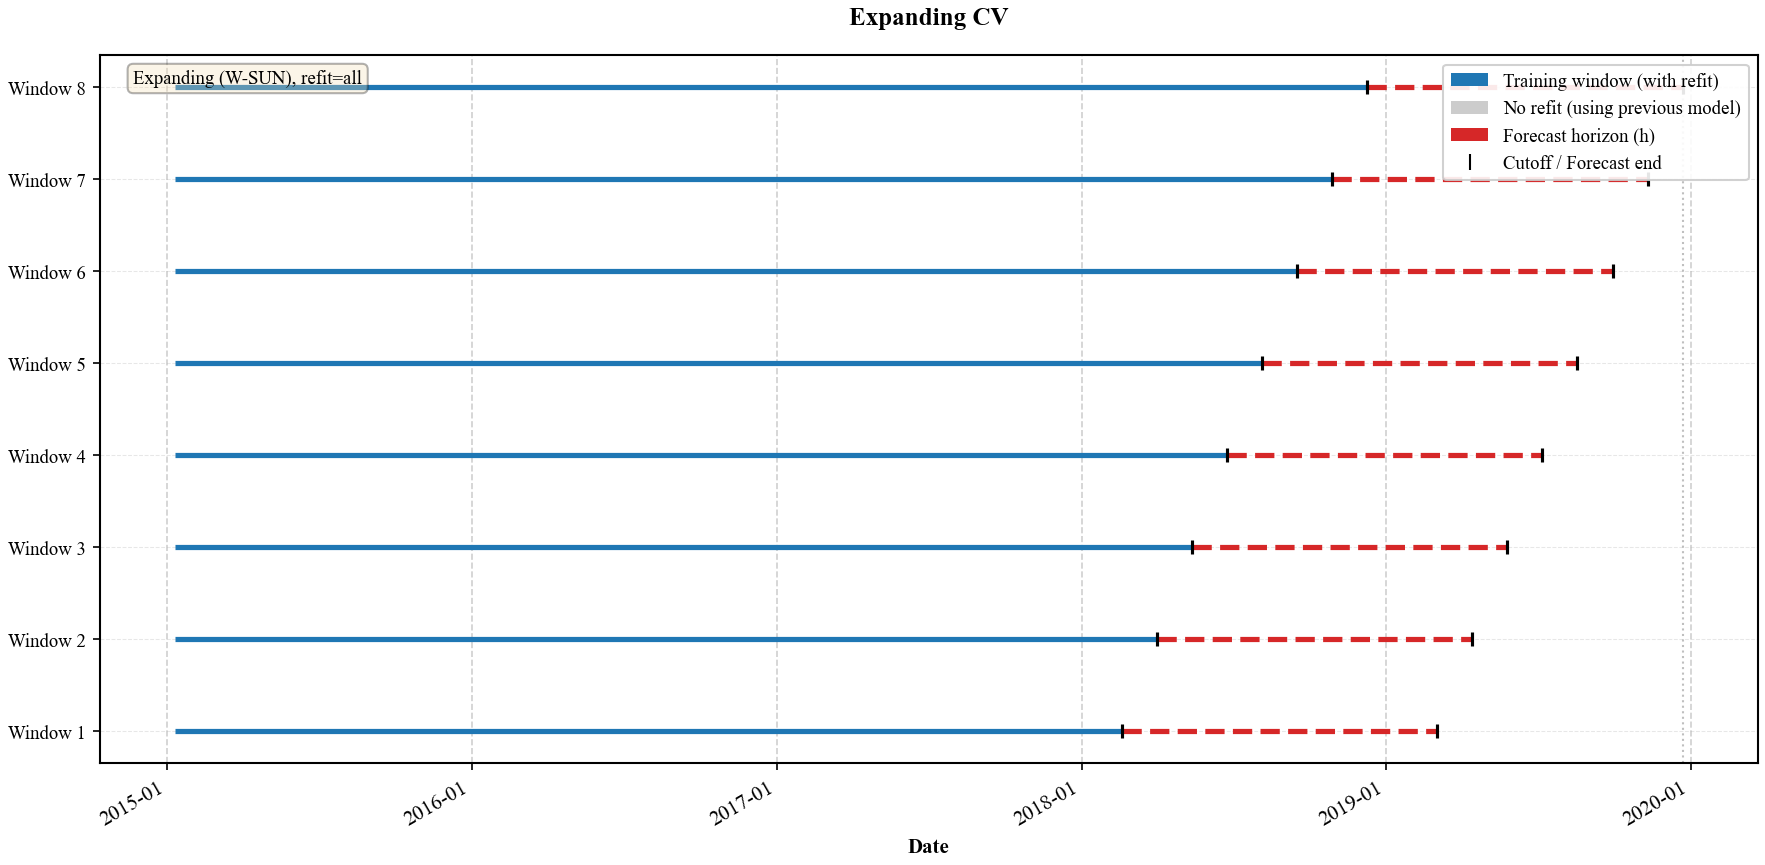

In [27]:
plot_cv_windows(panel_df, cutoff, freq = FREQ,  title="Expanding CV", **cv_conf);

#### Rolling CV Windows

В некоторых случаях, например, при устаревании данных предпочтительным является симуляция CV при помощи скользящего окна. Для этого можно задать входной размер окна в нашем случае.

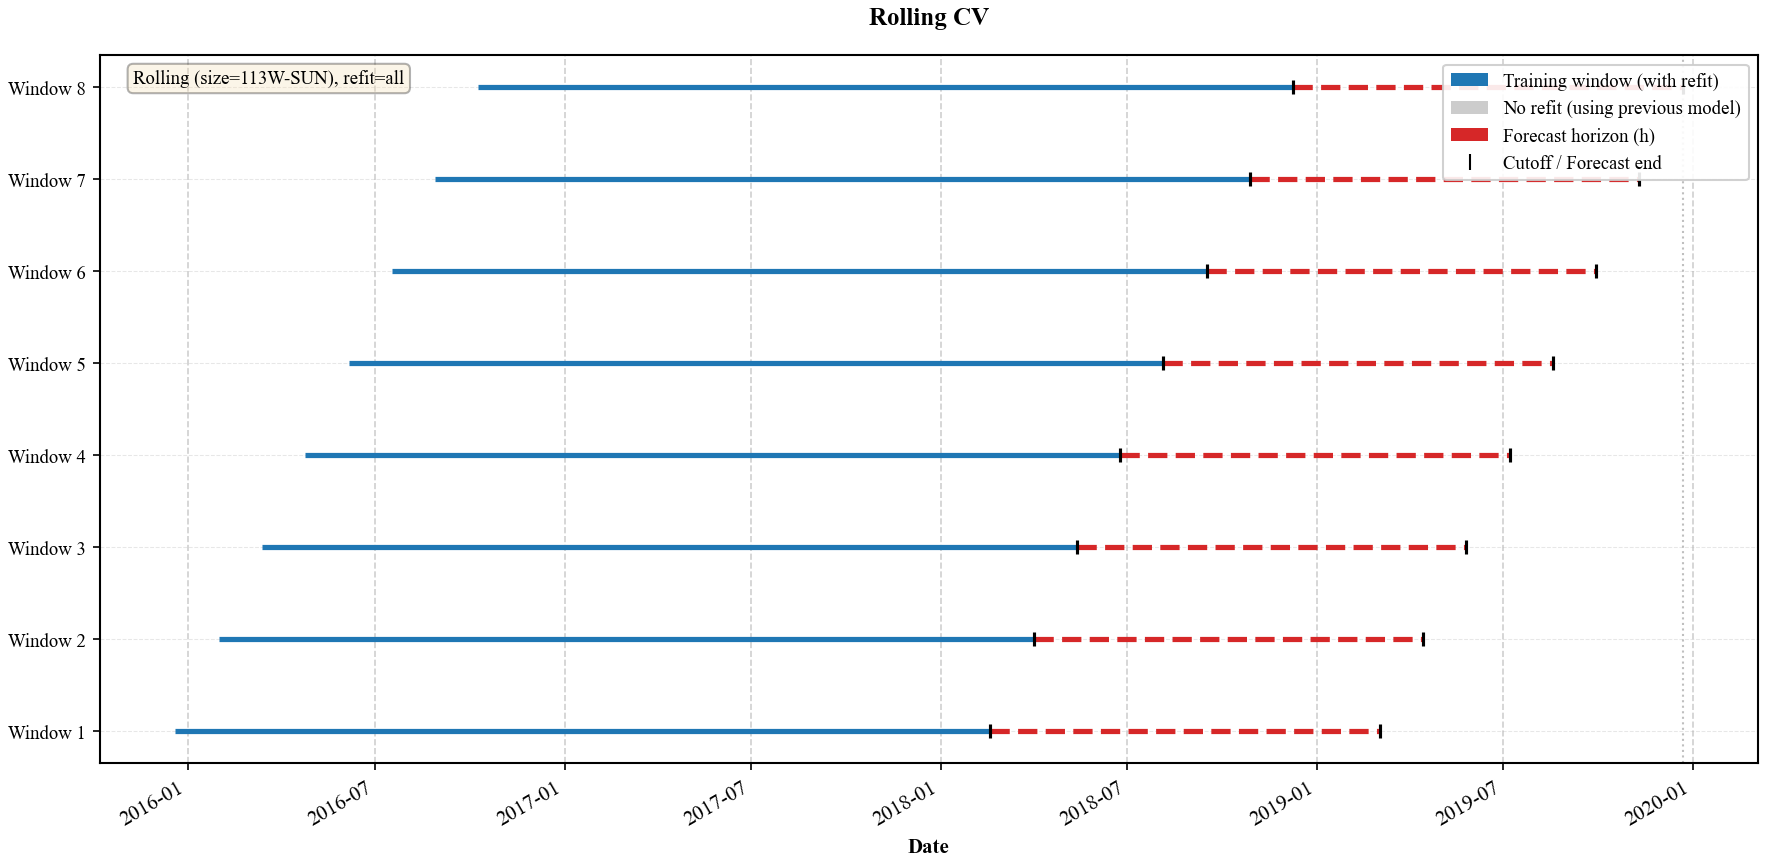

In [28]:
cv_conf = dict(h=FH//2,
           n_windows=8,
           step_size=FH//8, 
           input_size = len(df_train)//4,
           refit=True,   
              )       
cv_df = sf.cross_validation(
    df=panel_df, 
    **cv_conf
)
plot_cv_windows(panel_df, cutoff, freq = FREQ,  title="Rolling CV", **cv_conf);

#### Fixed Window

Также в некоторых случаях возникает задача тестирования единожды обученной модели на разных паттернах данных. Для этого случая подойдет стратегия фиксированного окна.



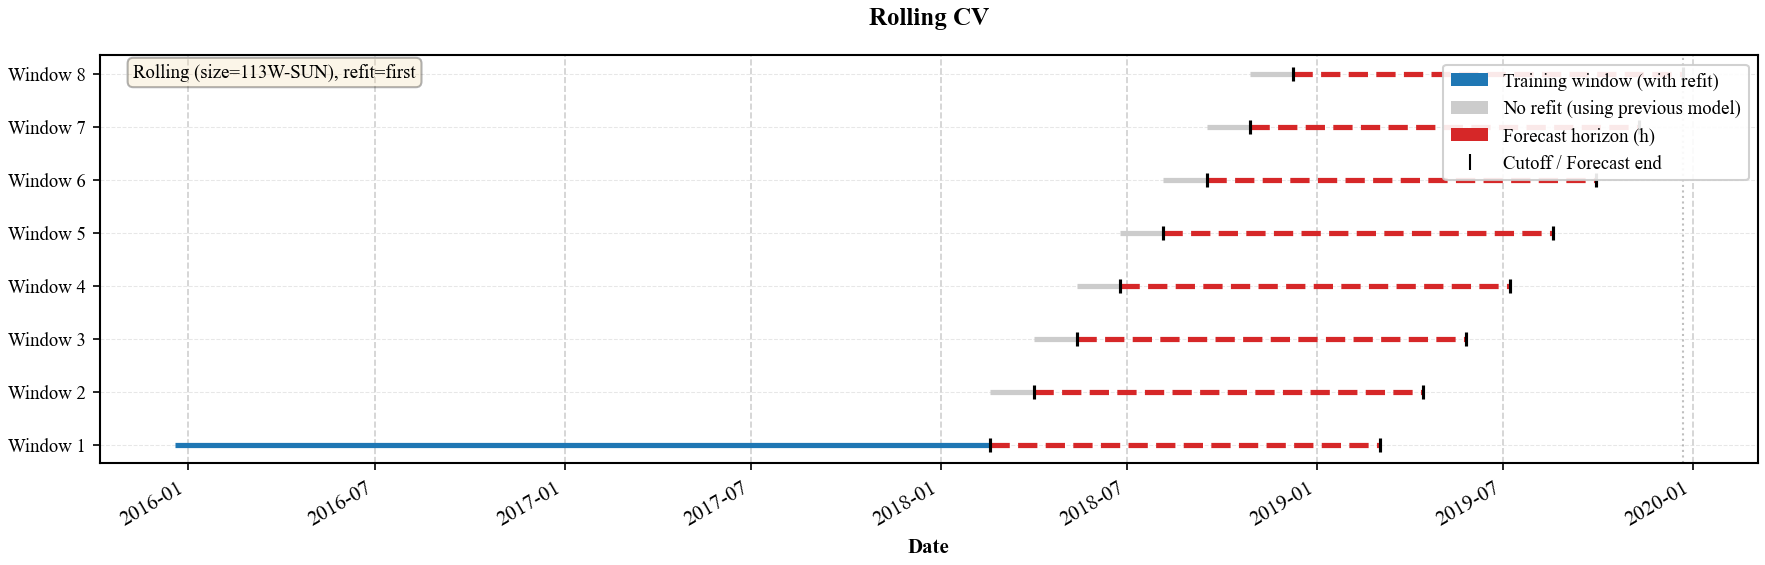

In [29]:
cv_conf = dict(h=FH//2,
           n_windows=8,
           step_size=FH//8, 
           input_size = len(df_train)//4,
           refit=False,   
              )       
cv_df = sf.cross_validation(
    df=panel_df, 
    **cv_conf
)
plot_cv_windows(panel_df, cutoff, freq = FREQ,  title="Rolling CV", **cv_conf, figsize=(12, 4),);

Мы рассмотрели базовые стратеги CV, среди которых основная - расширение окна. В целом стратегии спилата окон [могут быть и другими]( https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/backtesting.html).

На практике также стратегия сплита должны выбираться так, чтобы [соответствовать задаче](https://dl.leima.is/time-series/timeseries-evaluation.forecasting/). Например, в ряде случаев окно валидации должно опережать окно теста так, чтобы мы могли симулировать процесс в котором накопление данных значительно медленней появления новых данных. Или же например, в случае моделей глубокого обучения окно должно всегда быть фиксированного размера. Также  в некоторых случая - длинных ВР, отдельны интерес может представлять бектест для отдельных паттернов. В этом случае полезным будет использование нескольких стратегий спилат окна.


Отметим также, что при помощи процедуры `backtest` может быть построена процедура автоматизированногог сравнения моделей предсказания [`benchmarking`](https://github.com/sktime/sktime/blob/main/examples/04_benchmarking_v2.ipynb).

Отметим также, что на практике [выбор метрики](https://unit8co.github.io/darts/generated_api/darts.metrics.metrics.html#) или [метрик](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-metrics.html) для сравнения ВР это не тривиальный вопрос. Метрики могут быть разделены [на несколько классов](https://dl.leima.is/time-series/timeseries-metrics.forecasting/) при этом каждая из [метрик](https://otexts.com/fpp3/accuracy.html) будует иметь свою [интерпретацию](https://www.mdsi.tum.de/fileadmin/w00cet/di-lab/pdf/Amazon_SS2022_Final_Report.pdf). 

>Также отметим, что в ряде случаев верной оценкой точности на прогнозе было бы использование т.н. [__динамического прогноза__](https://timeweb.cloud/tutorials/python/prognozirovanie-vremennyh-ryadov-python-3#dinamicheskij-prognoz). Т.е. такого, когда следующие значения предсказанной величины строятся на результатах предсказания ее предыдущих значений а не на исходных тестовых данных. В противовес этому тестирование на выборке исходных данных может быть названо [__статическим прогнозом__](https://timeweb.cloud/tutorials/python/prognozirovanie-vremennyh-ryadov-python-3#staticheskij-prognoz).





### Визуализация CV

#### Визуализация окон

Кроме визуализации окна попробуем также провести визуализацию результатов предсказания значений ВР. 

In [30]:
models = [
    # SeasonalExponentialSmoothingOptimized(SEASON), 
    SeasonalNaive(SEASON),
    AutoETS(season_length = SEASON, model='ZZA', damped=True),
    MSTL(SEASON),
    # AutoCES(season_length = SEASON, model = 'S'),
    # AutoTheta(SEASON,decomposition_type = 'additive',),
    # AutoARIMA(season_length = SEASON, ),
    HoltWinters(season_length=SEASON, error_type="A", alias="HW_Add")
]
model_names = [getattr(m, 'alias', type(m).__name__) for m in models]

In [31]:
sf = StatsForecast(models=models, freq=FREQ) 

cv_conf = dict(h=FH,
           n_windows=4,
           step_size=FH//8, 
           refit=True,  )     

cv_df = sf.cross_validation(
    df=panel_df, 
    fitted = True,
    **cv_conf
)
cutoff = cv_df['cutoff'].unique()

Попробуем визулизировать окона, которые мы получили

<details> <summary><i>old code</i></summary>


```python
for k in range(len(cutoff)):
    cv = cv_df[cv_df['cutoff'] == cutoff[k]]  
    print(f'ОКНО {k+1}')
    display(plot_series_v2(panel_df, cv.loc[:, cv.columns != 'cutoff'].drop(columns = 'y'), ids = ['Solar'], )) 
```
    
</details>

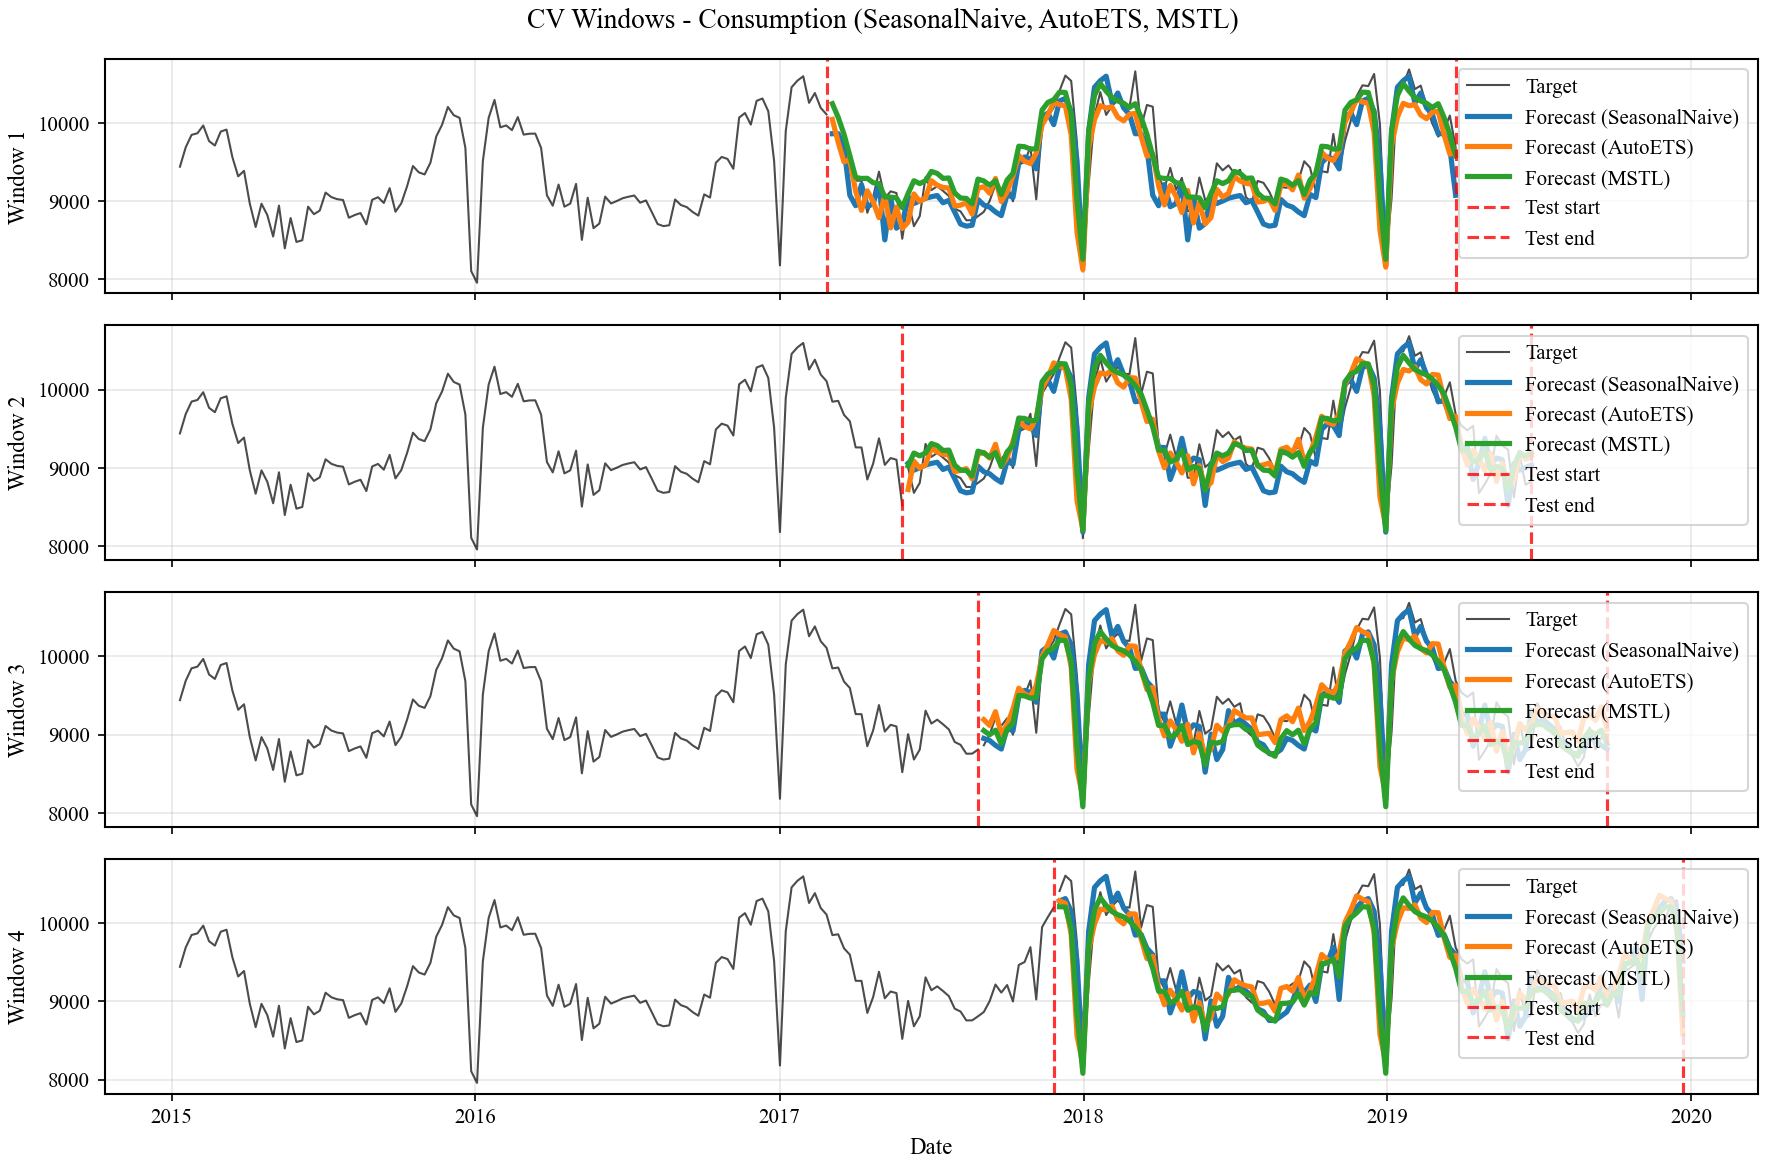

In [32]:
plot_cv_series(
    panel_df,
    cv_df,
    model = model_names[:3], 
    series_id='Consumption',    
    **cv_conf);
 

Аналогично запишем код для визуализации кросс-валидации выборки

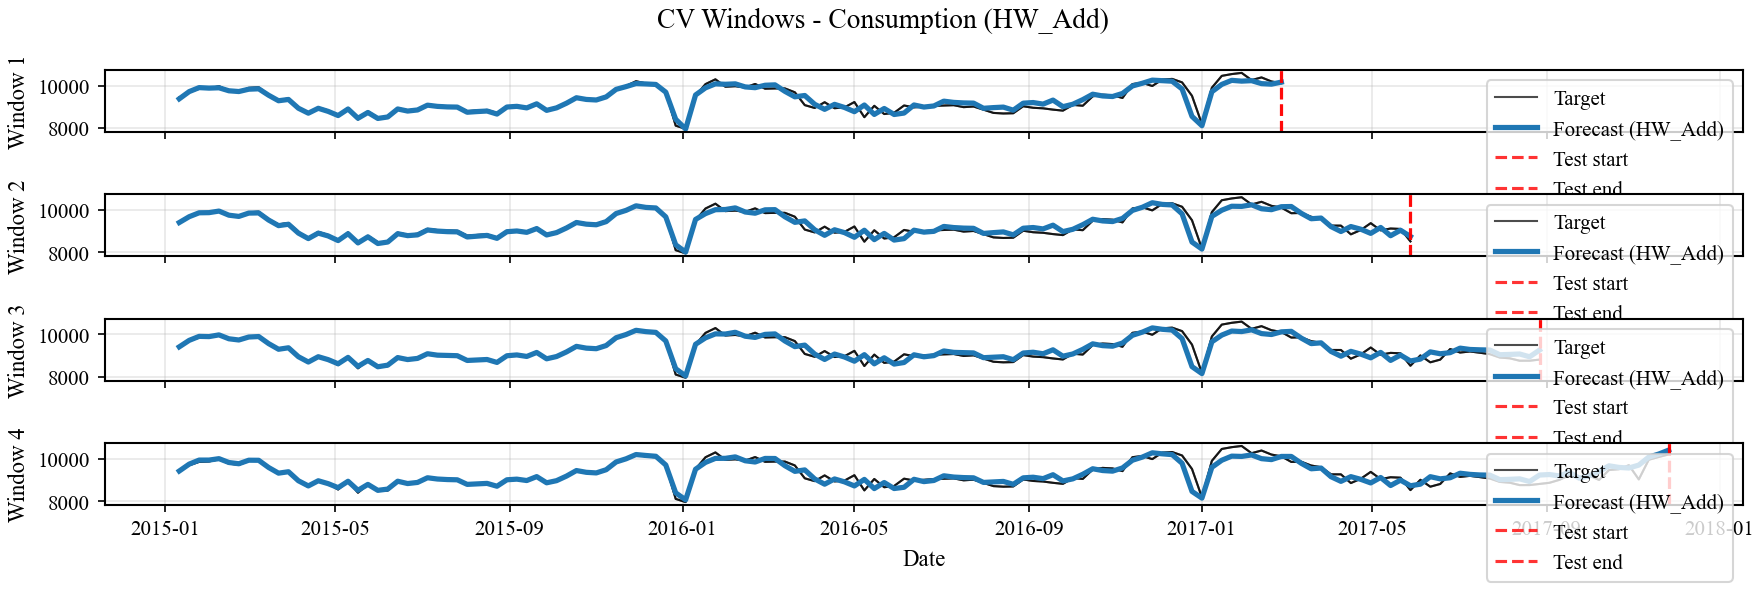

In [34]:
in_sample = sf.cross_validation_fitted_values()
plot_cv_series(
    panel_df,
    in_sample,
    cutoff,
    series_id='Consumption', 
    model = 'HW_Add',
    figsize_per_plot=(12,1),
    **cv_conf);

#### n-step-ahead-forecasting

__Обратим внимание__ на то, что стратегия ExpandingCV в случае, если окна не будете пересекаться даст результаты соответствующий задаче __n-step-ahead-forecasting__.

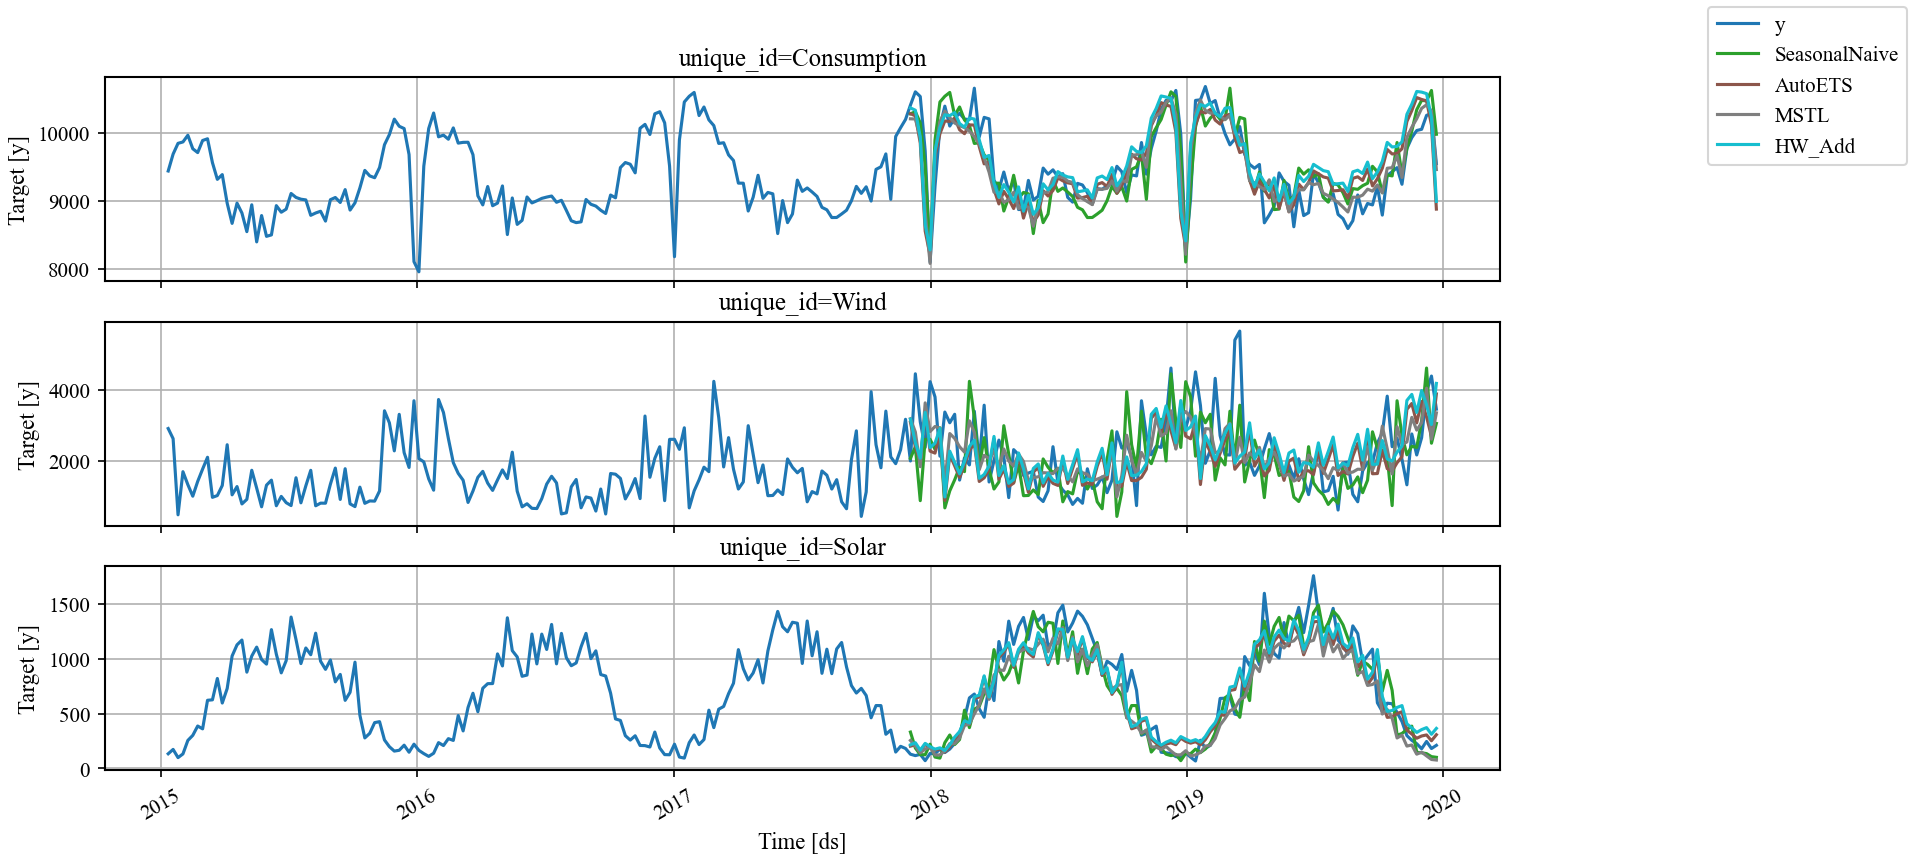

In [38]:
n_steps = 4
h = FH // n_steps
forecasts_df = sf.cross_validation(
        df=panel_df,
        input_size = len(df_train),    
        h=h,
        test_size=h * n_steps,
        step_size=h,
        refit=False,
    ).drop(columns = ['cutoff'])
plot_series_v2(df_train,forecasts_df = forecasts_df)

In [37]:
# plot_cv_series(
#     df_original = panel_df,
#     cv_df = cv_res,
#     cutoffs = cv_res['cutoff'].unique(),
#     model = model_names[:1], 
#     series_id='Consumption', 
#     figsize_per_plot=(12, 1.5),);

### Выбор моделей по метрикам кросс-валидации
####  Сводная оценка метрик
Проведем оценку средей точности для обоих методов для каждого ВР.

Задаим по-больше шагов валидации для накопления статистики

In [42]:
models

[SeasonalNaive, AutoETS, MSTL, HW_Add]

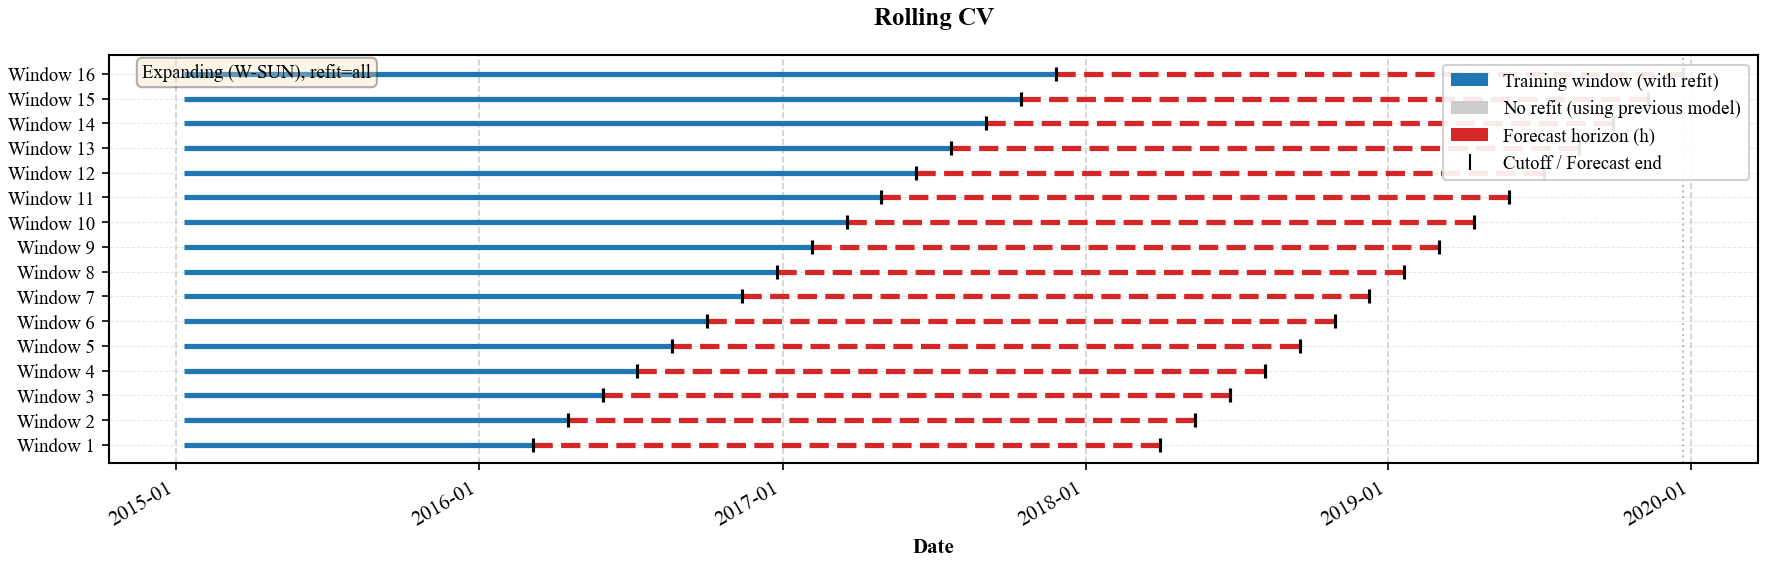

In [39]:
sf = StatsForecast(models=models, freq=FREQ) 

cv_conf = dict(h=FH,
           n_windows=16,
           step_size=FH//16, 
           refit=True,  )     

cv_df = sf.cross_validation(
    df=panel_df, 
    **cv_conf
)
cutoff = cv_df['cutoff'].unique()

plot_cv_windows(panel_df, cutoff, freq = FREQ,  title="Rolling CV", **cv_conf, figsize=(12, 4),);

оценку метрик в последних версиях utiliteforecast можно проводить с использованием станадартной функции evaluate

In [40]:
df_results = evaluate(
    cv_df,
    metrics=metrics,
    models=model_names,
    train_df=df_train,
    level=None,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    cutoff_col="cutoff",
    agg_fn=None,
)

df_results.head(2)

,unique_id,cutoff,metric,SeasonalNaive,AutoETS,MSTL,HW_Add
0,Consumption,2016-03-06,mase,1.555994,1.494369,1.414914,1.351481
1,Solar,2016-03-06,mase,1.576245,1.519801,1.635292,1.718378


Результат evaluate содержит значение каждой метрики для каджого значения cutoff

#### Детальный evaluate

Для полученного массива оценок построим таблицу сравнения выбранных метрик для всех ВР

In [41]:
avg_by_series = df_results.groupby(['unique_id', 'metric']).mean(numeric_only=True)
avg_by_series.style.background_gradient(cmap='RdYlGn_r', axis=1).format(precision=2)

#### макро-оценки точности

На самом деле редко когда ставится задача подбора отдельных моделей для каждого ВР. Попробуем выбрать лучшую метрику в среднем по всем ВР. 

__Отметим__, что для  сравнен по всем ВР нужно учитыать масштабы ряда или использовать масштабо-независимые метрики!

In [43]:
by_metric = df_results.groupby('metric').mean(numeric_only=True)
by_metric.style.background_gradient(cmap='RdYlGn_r', axis=1).format(precision=2)

,SeasonalNaive,AutoETS,MSTL,HW_Add
metric,,,,
mae,439.55,415.29,452.31,415.17
mase,1.23,1.20,1.26,1.20
rmse,571.52,549.60,588.65,544.40
smape,0.13,0.12,0.15,0.12


### Сравнение поведения моделей по метрике/ряду для каждой модели

#### Оценка динамики поведения 

Также иногда для целевых метрик лучше посмотреть на динамику их поведения.  Допустим, что мы рассматриваем MAE как наиболее понятную в предметной области ошибку. Проверим как она будет развиваться в нашем тестировании.

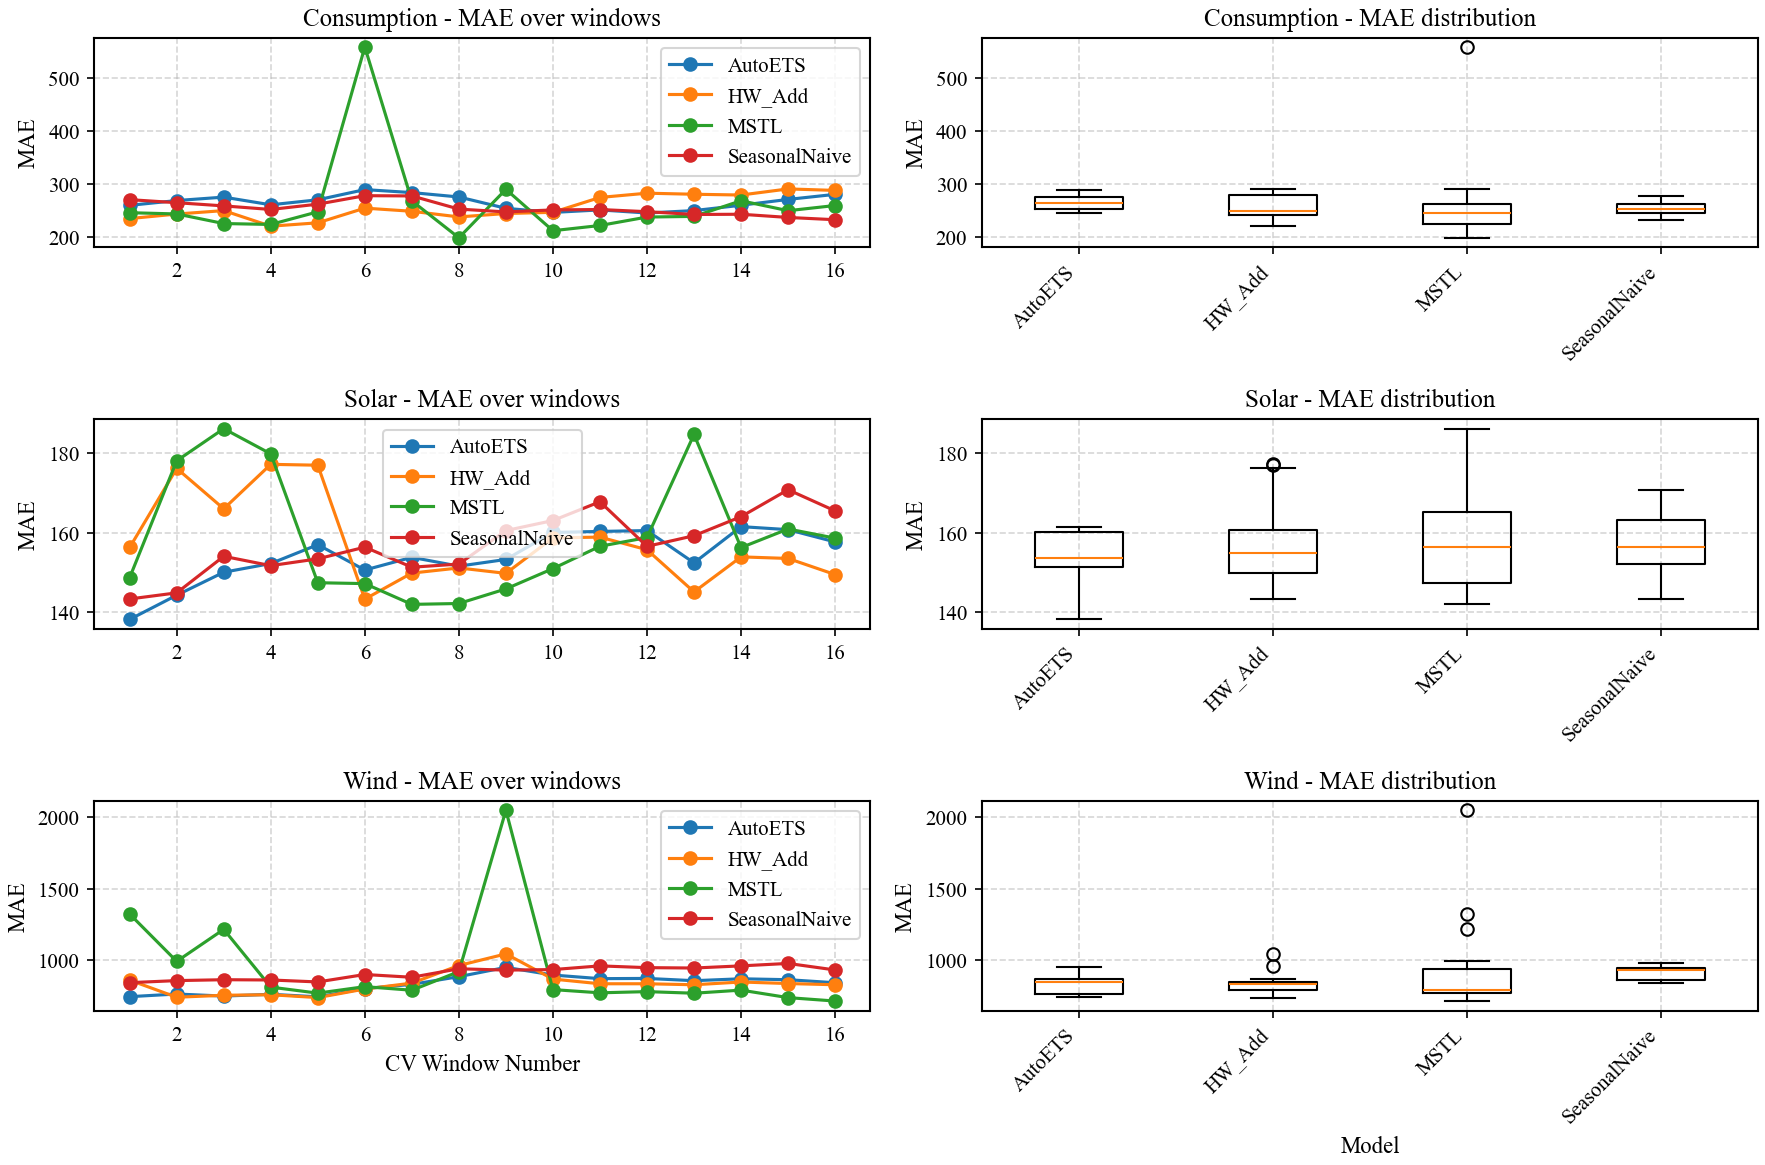

In [44]:
plot_cv_metric(df_results, metric='mae')

Поведения не однозначно. иногда видна динамика, которая может включать такие фактора как: 
 - зависимость от горизонта предсказния
 - нехватка тренировочных данных
 - влияние конкретного паттерна поведения ВР.
 
Однако, также видно, что моделей на основе скользящего среднего различия в поведении находятся в пределах погрешности.

В целом в таком случае следует выбирать ту модель, для которой сложность (информационный критерий) ниже.

#### Микро оценки разброса по метрикам

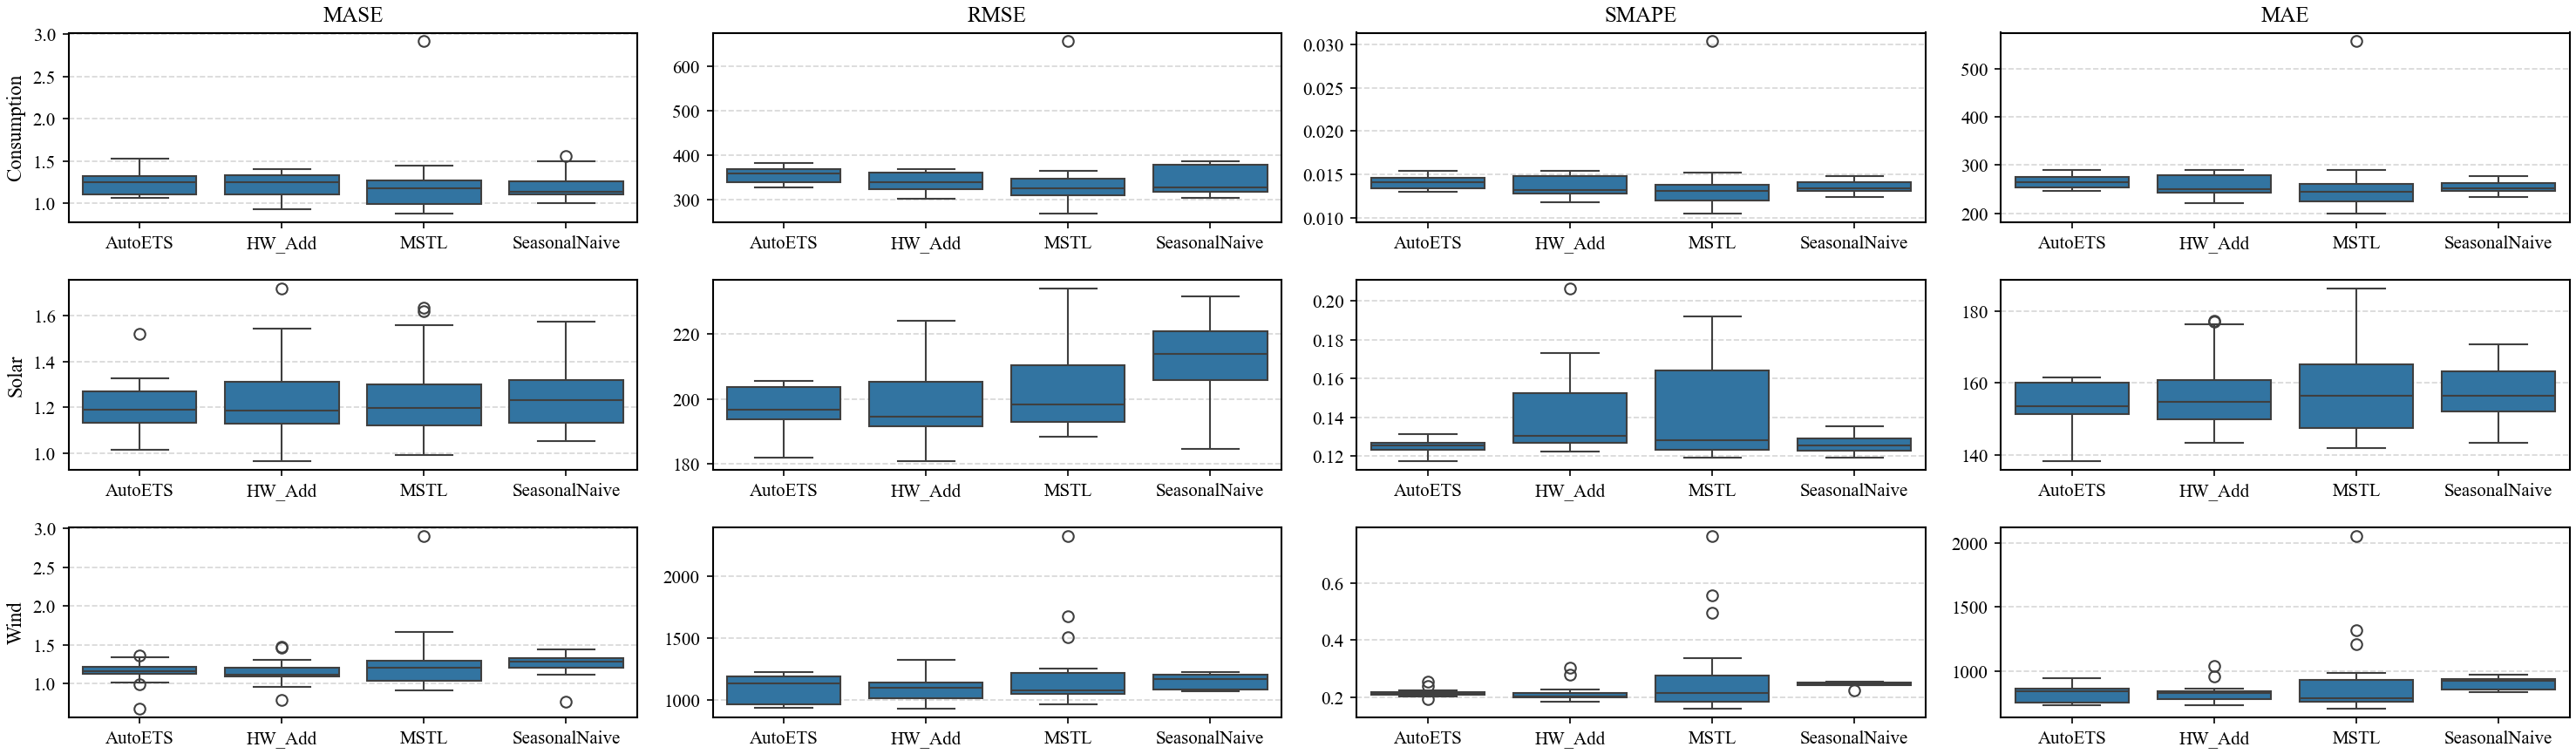

In [45]:
plot_cv_metrics_boxplots(
    df_results,
    metrics=metric_names,
    
)

Из графиков приемущестав оценок на основе скользящего среднего.

#### Ранговые оценки

Когда у нас есть несколько моделей и несколько метрик качества (MAE, SMAPE, MASE и т.д.), простое сравнение средних ошибок, особенно для масштабо-зависимых метрик может быть обманчивым:
 - У разных рядов ошибки по разным метрикам могут иметь разные масштабы.
 - Некоторые модели могут быть хороши для одних рядов и плохи для других.

Чтобы учесть эти факторы, можно использовать ранги моделей:
 - Для каждого ряда и окна CV мы присваиваем моделям ранги (1 — лучшая, больше — хуже).
 - Усредняем ранги по всем рядам и окнам b получаем макро-ранги, которые показывают для кажой метрики.

Чем ниже ранг модели - тем лучше

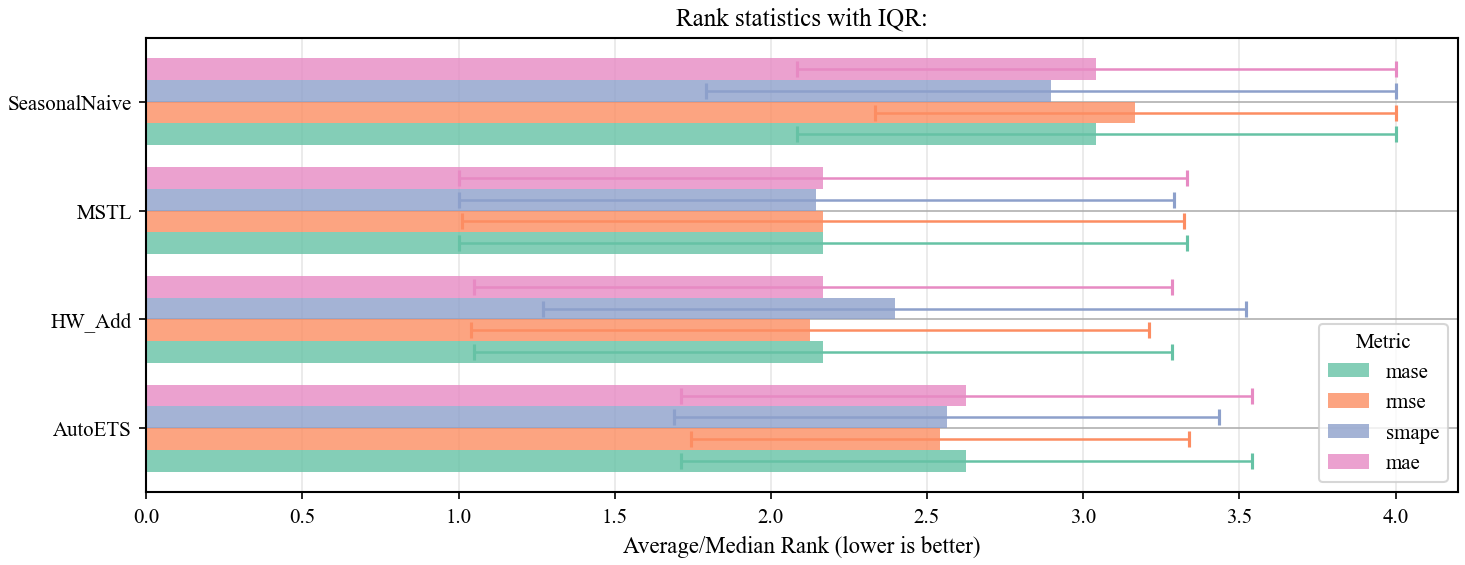

In [46]:
plot_cv_ranks(df_results, metrics=None, error_type='IQR')

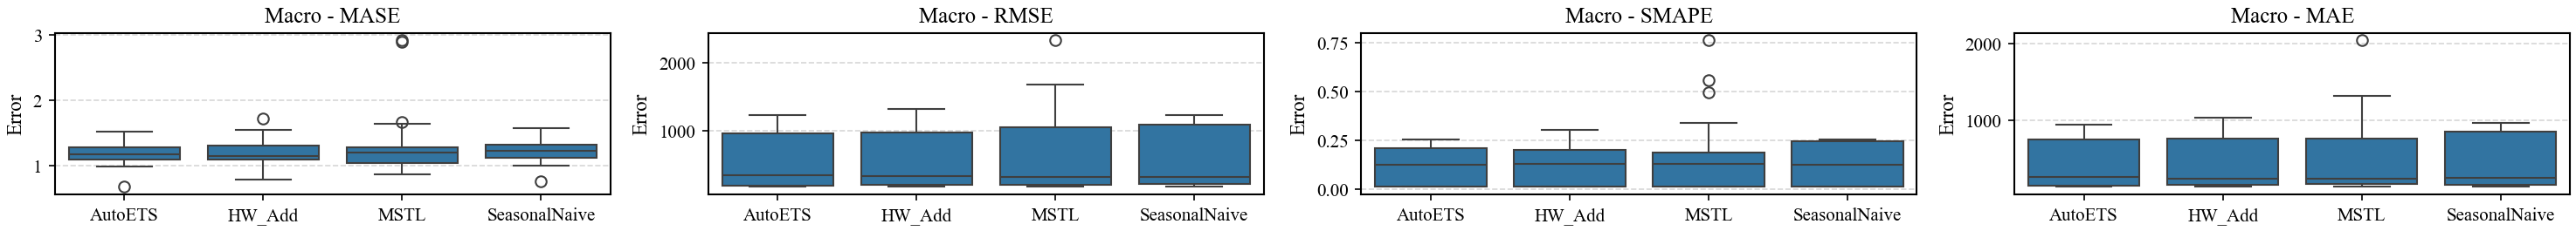

In [47]:
plot_cv_metrics_boxplots(
    df_results,
    metrics=metric_names,
    macro=True
)

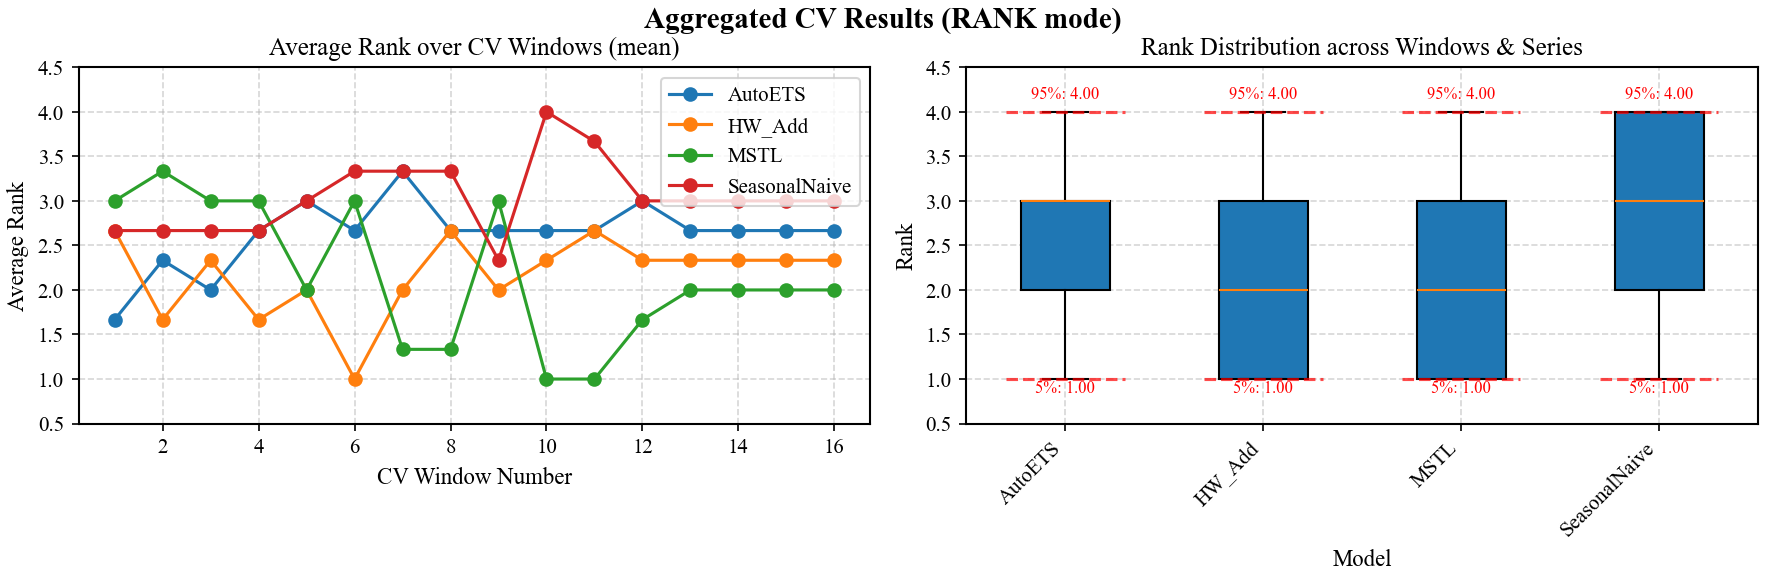

In [48]:
plot_cv_metric(df_results, metric='mae', aggregation ='rank', macro_mode=True,figsize=(12, 4),)

Визуально видно, что  HW_Add — стабильно лучший по mae и mase, но и примерно одинаково ведет себя  по rmse

### Статистическое сравнение моделей по результатам кросс-валидации

#### Цели использования стат. тестов

Мы провели визуальный анализ качества работы моделей на бектесте. 

Однако, для получения численных оценок следует также проводить и статистическое тестирование.

__Особенности результатов CV__ в задачах прогнозирования временных рядов:

 - ошибки моделей зависимы (перекрывающиеся окна CV)
 - распределения ошибок часто не нормальны
 - сравнение проводится между несколькими моделями одновременно
 - объем выборок метрик небольшой

[Рекомендуется использовать](https://practicalcheminformatics.blogspot.com/2023/11/comparing-classification-models-youre.html) __непараметрические ранговые тесты__.

Для использования тестов 
 - выберем целевую метрику, по которой будем сравнивать модели
 - Построим ранговые статистики для результатов, где ранг это ранжированное значение для метрики в каждом блоке (unique_id, cutoff).
   Например: mase, Блок 1 (Consumption, 2016-03-06): ранги моделей SeasESOpt, AutoETS, AutoARIMA, HW_Add: 3, 2, 4, 1. 
 - Вычислим средний ранг модели, как показатель стабильности.

Для выявления значемых различий между всеми моделями проведем тест Фридмана. 
__Тест Фридмана__ непараметрический тест на сравнение рангов моделей для кажого блока. Тест проверяет, имеются ли значимые отклонения от равномерного распределения рангов, чем больше статистика Фридмана (и $p_{value}$) - тем больше отклонения. Таким образом:
 - _H0_ - модели не имеют статистически значимых разичий ($p_{value} < \alpha$).
 - _H1_ - хотябы одна модель статистически отлична от остальных.

__В дополнение к тесту Фридмана__ для оценки стабильности различий между моделями также часто считают [ранговую корреляцию](https://wiki.loginom.ru/articles/rank-correlation-kendall.html). На практике для теста Фридмана рекомендуется использовать [коэффициент согласованности Кендалла](https://en.wikipedia.org/wiki/Kendall%27s_W) (__Kendall W__). Значения коэффициента $W$ можно интерпретировать следующим образом:
- $W <\alpha$ - все результаты не согласованы (ранг случайный),
- $W<0.3$ - имеют место слабые (не стабильные) различия ранга,
- $W>0.5$ - значительные различия (ранг модели стабилен).


Если хотябы одна модель имеет статистически значимые различия, [следует их проанализировать](https://www.researchgate.net/publication/289506762_Overview_of_Friedman's_Test_and_Post-hoc_Analysis) при помощи парных тестов. Среди таких тестов наиболее простым является тест [Nemenyi (Wilcoxon-Nemenyi-McDonald-Thompson Test)](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_nemenyi_friedman.html).  

Однако мы воспользуемся __Wilcoxon test__ ( Wilcoxon signed-rank - тест Уилкинсона). Данный тест более мощный и [доступен в стандартном пакете scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html). Тест Уилкинсона позволяет проводить парные ранговые сравнения для одних и тех же блоков на малых выборках. Тест проверяет что гипотезу о том, что распределение разностей между двумя связанными выборками симметрично относительно нуля (то есть значения случайно калеблются вокург нуля). 
- $H0$ - Разности симметричны относительно 0 (модели не различаются)
- $H1$ - Разности смещены в одну сторону (одна модель систематически лучше) ($p_{value} < \alpha$)
- _Тест Уилкоксона работает для метрик где меньше - значит лучше._                                   

Так  как тест делает достаточно много сравнений (для каждой модели), то дополним результат [тестом  Холма (Holm-Bonferroni test)](https://www.statisticshowto.com/holm-bonferroni-method/). Тест Холма представляет собой процедуру  корреции p-value Wilcoxon test для результатов множественных сравнений. Цель - выявить [ложно положительные срабатывания](https://www.statsig.com/glossary/bonferroni-correction) теста Уилкоксона. Для этого p-value корректируется на степень свободы сравнений.

Таким образом итоговая гипотеза:
- $H0$ - Разности симметричны относительно 0 (модели не различаются) (хотя бы одно $p_{value} > \alpha$ )
- $H1$ - Разности смещены в одну сторону (одна модель систематически лучше) (оба $p_{value} < \alpha$)
- _Тест Уилкоксона_ работает для метрик где меньше - значит лучше.
- 
Оба теста должны бать одинаковый результат по ($p_{value} < \alpha$) чтобы считать различия между моделями значемыми.

Также для оценки различий посчитаем эффективность теста $r$. Чем ее значение выше, тем более существены различия. 

#### cv_statreport

In [49]:
results = cv_model_stats(df_results, metric_name = 'mae' )


Метрика: MAE | блоков: 48
Friedman χ² = 15.3000
p-value     = 1.577e-03
Kendall’s W = 0.106
----------------------------------------------------------------------
Средние ранги:


,model,avg_rank,std_rank
0,HW_Add,2.167,1.106
1,MSTL,2.167,1.179
2,AutoETS,2.625,0.904
3,SeasonalNaive,3.042,1.020


----------------------------------------------------------------------
Pairwise Wilcoxon + Holm (+ effect size r):


,model_1,model_2,p_wilcoxon,p_holm,r,significant
0,SeasonalNaive,AutoETS,0.014,0.083,0.405,False
1,SeasonalNaive,HW_Add,0.018,0.091,0.389,False
2,SeasonalNaive,MSTL,0.082,0.328,0.289,False
3,AutoETS,HW_Add,0.243,0.728,0.196,False
4,AutoETS,MSTL,0.351,0.728,0.156,False
5,MSTL,HW_Add,0.401,0.728,0.141,False


Результаты теста говорят о том, что
 - модели имеют статистически-значемые различия по Фридману,
 - однако эти разилчия слабые (W = 0.1)
 - по рангу лучшей моделью является HW_Add, однако AutoETS не сильно хуже.
 - Парные сравнения:  AutoARIMA систематически уступает AutoETS и HW_Add.
 - Разичия SeasESOpt vs HW_Add / AutoETS слабые.


#### Упражнения
1. Провести анализ метрик для семейства моделей сокльзящего среднего и Prophet


### Дополнительно

####  scikit_posthocs

Для более продвинутого анализа результатов кросс-валидации существую специализированные пакеты, в том числе [scikit_posthocs](https://scikit-posthocs.readthedocs.io/en/latest/tutorial.html). Пакет включает основной инструментарий сравнения моделей и визуализации результатов сравнений. В первую очередь пакет предполагает работы с табличными данными, однако некоторые его функции могут быть использованы и в нашем случае.

####  Critical difference diagrams

Одним из принятых способов визуализации результатов сравнения моделей является т.н. [__Critical difference diagrams  (CD)__](https://github.com/hfawaz/cd-diagram). Попробуем построить https://scikit-posthocs.readthedocs.io/en/latest/tutorial.html#critical-difference-diagrams). 

In [53]:
import scikit_posthocs as sp

In [54]:
metric_name = 'mae'
results = cv_model_stats(df_results, metric_name = 'mae', verbose=False )

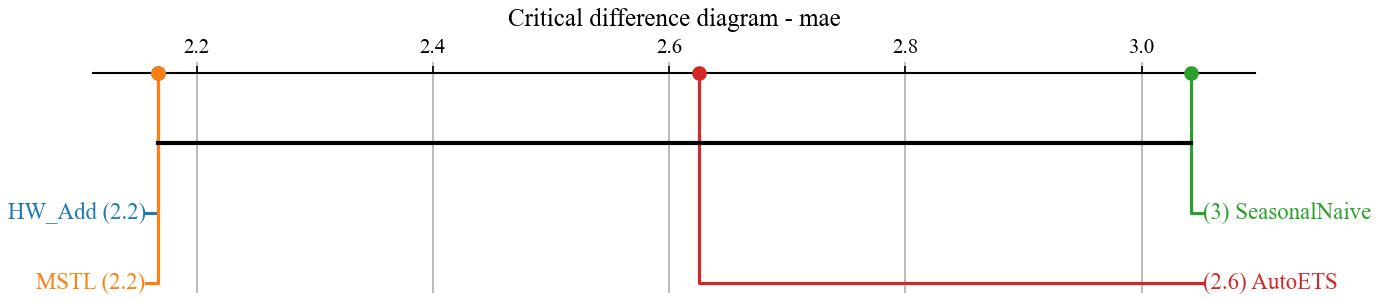

In [55]:
ranks_df = results['ranks_df'] if 'ranks_df' in results else results[metric_name]['ranks_df']
pairwise_df = results['pairwise_wilcoxon'] if 'pairwise_wilcoxon' in results else results[metric_name]['pairwise_wilcoxon']
avg_rank = ranks_df.set_index('model')['avg_rank']

# формируем матрицу значимости (True = незначимо)
models = avg_rank.index.tolist()
sig_matrix = pd.DataFrame(True, index=models, columns=models)
for _, row in pairwise_df.iterrows():
    m1, m2 = row['model_1'], row['model_2']
    sig = row['p_holm'] >= 0.05  # True = незначимо
    sig_matrix.loc[m1, m2] = sig
    sig_matrix.loc[m2, m1] = sig


plt.figure(figsize=(10,2))
plt.title(f'Critical difference diagram - {metric_name}')
sp.critical_difference_diagram(avg_rank, sig_matrix)
plt.show()


In [42]:
avg_rank

model
MSTL             2.479167
HW_Add           2.479167
AutoETS          2.979167
SeasESOpt        3.437500
SeasonalNaive    3.625000
Name: avg_rank, dtype: float64

__Интерпретация CD диаграммы__
- Ось X = средние ранги (меньше = лучше)
- Линии между моделями → различия незначимы (p_holm ≥ 0.05)
- Модели без линий между собой → статистически значимо различаются

__! Отметим__ что на практике [могут использоваться и другие (дополнительные)](https://arch.readthedocs.io/en/latest/multiple-comparison/multiple-comparison_examples.html) тесты на множественное сравнение для временных рядов. В том числе помимо поправок не вероятность ложного отклонения H0, могут и другие [постановки гипотез о проблемах множественных сравнений](https://ru.wikipedia.org/wiki/%D0%9F%D0%BE%D0%BF%D1%80%D0%B0%D0%B2%D0%BA%D0%B0_%D0%BD%D0%B0_%D0%BC%D0%BD%D0%BE%D0%B6%D0%B5%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D1%83%D1%8E_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D1%83_%D0%B3%D0%B8%D0%BF%D0%BE%D1%82%D0%B5%D0%B7).

## Построение вероятностных прогнозов моделей

### Покрытие интервала predict_interval

<!-- Как уже было замечено вероятностное прогназирование часто используется для двух процедур:
* [процедура `backtest`](https://joaquinamatrodrigo.github.io/skforecast/0.8.1/user_guides/backtesting.html) в качестве допонительной меры отбора моделей и настройки их параметров.
* [допонительные метрики](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-metrics.html) оценки для будущих значений при настройки моделей. В том числе как мера оценки [интервала разброса значений оценки](https://otexts.com/fpp3/prediction-intervals.html). Такие метрики могут помочь и дополнить процедуру evaluation. Каждая из метрик будет иметь [свою интерпретацию](https://otexts.com/fpp3/distaccuracy.html). -->

Большая часть моделей (см. [документацию тут](https://nixtlaverse.nixtla.io/statsforecast/src/core/models_intro.html)) позволяют оценивать как точечное значение, так и строить интервальный прогноз. То есть прогнозировать величину заданного доверительного интервала (например 90%) [означает оценку интервала значений](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/uncertaintyintervals.html) в котором окажется действительная величина окажется относительно предсказаной с вероятностью 90%). 

Такое значение другими словами показывает неопрделенногость предсказания.

> Важно поримать что оценка неопределенности предсказания как правило шире чем доверительный интервал. Доверительный интервал оценивается по текущим значениям выборки, в то время как неопрделенногость предсказания дает оценку разброса в будущем.



<!-- <blockquote>
    
Формальный вид прогноза (эндогенный, одна временная метка прогноза):
* Пусть $y(t_1), \dots, y(t_n)$ - это наблюдения в фиксированные моменты времени $t_1, \dots, t_n$.
(мы рассматриваем $y$ как $\mathbb{R}^n$-значную случайную величину).
* Пусть $y'$ - это (истинное) значение, которое будет наблюдаться в будущий момент времени $\tau$.
(мы рассматриваем $y'$ как $\mathbb{R}$-значную случайную величину) -->

Более формально можно выделить несколько видов вероятностного прогноза:

* __"точечный прогноз"__ - это предсказание/оценка условного ожидания $E[y'|y]$, где $y'$ - истинный результат. Интуиция: "из множества повторений/разных попыток предсказания - результат значение средним арифметическим значением".

* __"дисперсионный прогноз"__ (`predict_var(fh=None, X=None, cov=False)`) - это предсказание/оценка условного ожидания дисперсии $Var[y'|y]$. Интуиция: "из множества повторений - это значение является средним квадратичным расстоянием от наблюдения до идеального точечного прогноза".

* __"квантильный прогноз"__(`predict_quantiles(fh=None, X=None, alpha=[0.05, 0.95])`), в точке квантиля $\alpha \in (0,1)$ - это предсказание/оценка $\alpha$-квантиля $y'|y$, т.е. $F^{-1}_{y'|y}(\alpha)$, где $F^{-1}$  это (обобщенная) обратная `CDF` = квантильная функция случайной величины $y'|y$. Интуиция: "Из множества повторений вероятность появления данного будет равна или меньше  значения $\alpha$".
 
* __"Интервальный прогноз"__ или __"интервал предсказания"__ (`predict_interval(fh=None, X=None, coverage=0.90)`) с (симметричным) охватом $c \in (0,1)$ - это пара прогноз/оценка с нижней границей $a$ и верхней границей $b$, такая, что $P(\alpha \le y' \ge b|y)=c$ и $P(y'>b|y)=P(y<a|y)=(1-c)/2$. Интуиция: "Из множества повторений результат будет содержаться в интервале $[a,b]$  с вероятностью $c$. Причем вероятность того, что будут результаты выше равна вероятности того, что  будут результаты ниже".

* __"прогноз распределения"__ или __"полный вероятностный прогноз"__ (`predict_proba(fh=None, X=None, marginal=True)`)- это предсказание/оценка распределения $y'|y$ например, "это нормальное распределение со средним 42 и дисперсией 1". Интуиция: исчерпывающее описание механизма порождения множества повторений.

<!-- Примечания:
* _нижняя/верхняя часть интервальных прогнозов_ - это квантильные прогнозы в точках квантилей $0,5 - c/2$ и $0,5 + c/2$ (при условии, что распределения прогнозов абсолютно непрерывны).
* все остальные прогнозы могут быть получены из полного вероятностного прогноза; полный вероятностный прогноз может быть получен из всех квантильных или всех интервальных прогнозов.
* не существует точной зависимости между другими типами прогнозов (точечный или дисперсионный vs квантильный)
* в частности, точечный прогноз не обязательно должен быть медианным прогнозом aka 0,5-квантильным прогнозом. Это может быть 
$\alpha$-quantile для любого $\alpha$! -->
<!-- 
Частая путаница в литературе и пакетах python: * охват 'c' vs квантиль '\alpha' * охват 'c' vs значимость 'p = 1-c' * квантиль нижней границы интервала, 'p/2', vs 'p' * интервальные прогнозы vs связанные, но существенно разные понятия: доверительный интервал для прогнозируемого среднего; байесовский апостериор или интервал доверия для прогнозируемого среднего * все прогнозы выше могут быть байесовскими, путаница: "апостериоры разные" или "должны оцениваться по-разному". -->



<!-- Formal view (endogeneous, one forecast time stamp):

Let $y(t_1), \dots, y(t_n)$ be observations at fixed time stamps $t_1, \dots, t_n$.

(we consider $y$ as an $\mathbb{R}^n$-valued random variable)

Let $y'$ be a (true) value, which will be observed at a future time stamp $\tau$.

(we consider $y'$ as an $\mathbb{R}$-valued random variable)

More formal details & intuition:
* a “point forecast” is a prediction/estimate of the conditional expectation $E[y'|y]$ where $y'$ is a true result.
. Intuition: “out of many repetitions/differnt attempts to forecast, this value is the arithmetic average of all observations”.
* a “variance forecast” ('predict_var(fh=None, X=None, cov=False)')  is a prediction/estimate of the conditional expectation $Var[y'|y]$ 
. Intuition: “out of many repetitions/worlds, this value is the average squared distance of the observation to the perfect point forecast”.
* a “quantile forecast”, at quantile point  $\alpha \in (0,1)$ is a prediction/estimate of the 
$\alpha$-quantile of $y'|y$, i.e., of $F^{-1}_{y'|y}(\alpha)$, where $F^{-1}$
 is the (generalized) inverse cdf = quantile function of the random variable $y'|y$. 
 Intuition: “out of many repetitions/worlds, a fraction of exactly 
 will have equal or smaller than this value.”
* an “interval forecast” or “predictive interval” with (symmetric) coverage $c \in (0,1)$ is a prediction/estimate pair of lower bound $a$ and upper bound 
$b$ such that $P(\alpha \le y' \ge b|y)=c$
and $P(y'>b|y)=P(y<a|y)=(1-c)/2$. Intuition: “out of many repetitions/worlds, a fraction of exactly $c$
will be contained in the interval $[a,b]$, and being above is equally likely as being below”.
* a “distribution forecast” or “full probabilistic forecast” is a prediction/estimate of the distribution of $y'|y$
, e.g., “it’s a normal distribution with mean 42 and variance 1”. Intuition: exhaustive description of the generating mechanism of many repetitions/worlds.

Notes:

* lower/upper of interval forecasts are quantile forecasts at quantile points  $0.5 - c/2$
 and $0.5 + c/2$
 (as long as forecast distributions are absolutely continuous).
* all other forecasts can be obtained from a full probabilistic forecasts; a full probabilistic forecast can be obtained from all quantile forecasts or all interval forecasts.
* there is no exact relation between the other types of forecasts (point or variance vs quantile)
* in particular, point forecast does not need to be median forecast aka 0.5-quantile forecast. Can be 
$\alpha$-quantile for any $\alpha$!

Frequent confusion in literature & python packages: * coverage 'c' vs quantile '\alpha' * coverage 'c' vs significance 'p = 1-c' * quantile of lower interval bound, 'p/2', vs 'p' * interval forecasts vs related, but substantially different concepts: confidence interval on predictive mean; Bayesian posterior or credibility interval of the predictive mean * all forecasts above can be Bayesian, confusion: “posteriors are different” or “have to be evaluted differently”

 -->



Отметим еще раз важность прогнозирования интервалов предсказания [(доверительных интервалов) во временных рядах](https://nixtlaverse.nixtla.io/mlforecast/docs/tutorials/prediction_intervals_in_forecasting_models.html#importance-of-confidence-interval-prediction-in-time-series):
* __Оценка неопределенности__: Доверительный интервал обеспечивает меру неопределенности, связанной с прогнозами временных рядов. Он позволяет количественно оценить изменчивость и диапазон разборса возможных будущих значений, что очень важно для принятия обоснованных решений.
* __Оценка точности__: Имея доверительный интервал, можно оценить надежность прогнозов. Если интервал узкий, это говорит о том, что прогноз более точный и надежный. С другой стороны, если интервал широкий, это указывает на большую неопределенность и меньшую точность прогноза.
* __Управление рисками__: Доверительный интервал помогает в управлении рисками, предоставляя информацию о возможных сценариях будущего. Он позволяет определить диапазоны, в которых могут находиться реальные значения, и принимать решения на основе этих возможных сценариев.
* __Эффективная коммуникация__: Доверительный интервал - полезный инструмент для четкой и точной передачи прогнозов. Он позволяет донести до заинтересованных сторон изменчивость и неопределенность, связанную с прогнозами, избегая неправильной или слишком оптимистичной интерпретации результатов.

Поэтому прогнозирование доверительных интервалов во временных рядах необходимо для понимания и управления неопределенностью, оценки точности прогнозов и принятия обоснованных решений на основе возможных сценариев будущего.

<!-- >Большинство моделей временных рядов генерируют прогнозы, которые следуют нормальному распределению, что подразумевает, что мы предполагаем, что возможные будущие значения следуют нормальному распределению. Однако, реальное распределение не всегда такое. -->



### Модели с расчетной оценкой неопределенности

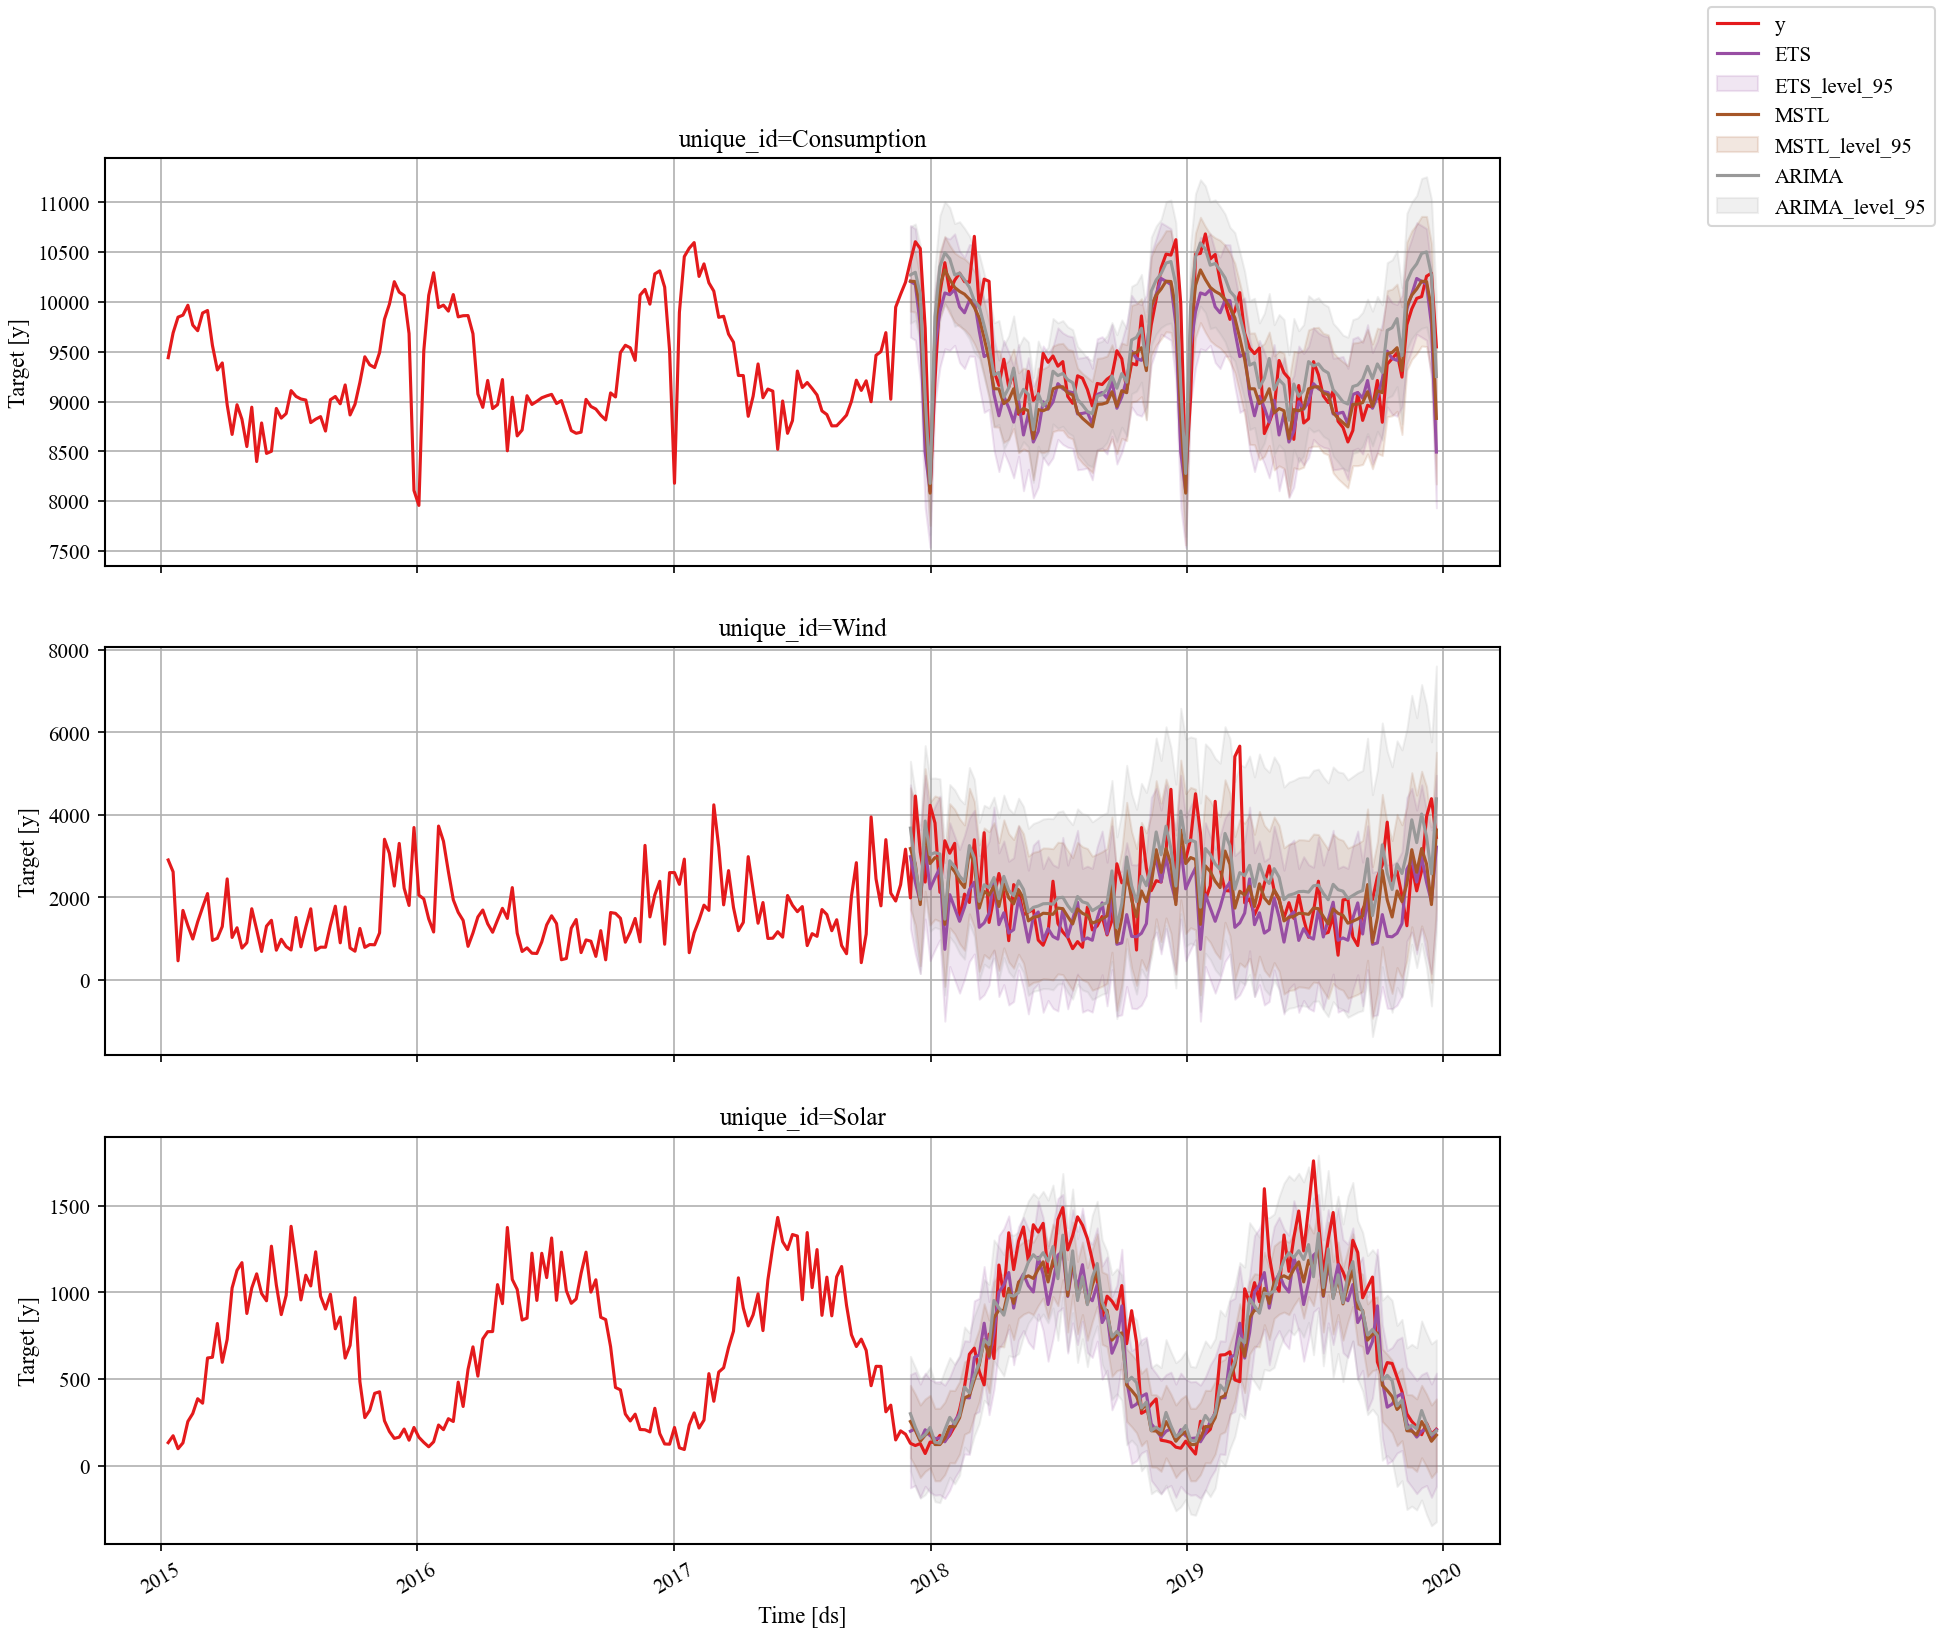

In [56]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    MSTL(season_length=SEASON, ),
    # TBATS(SEASON, use_trend = True, use_damped_trend = True),
    ARIMA(order=(3, 1, 1),
                season_length = SEASON,
                seasonal_order = (0, 1, 1,)  )
    
]

LEVELS = [0.25, 0.5, 75, 90, 95]


sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h=FH, level=LEVELS)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 4*n_rows), sharex=True)

plot_series(
    df_train,
    forecasts_df = eval_sf,
    level=LEVELS[-1:],
    ax=ax,
    palette='Set1',
)

#### Упражение
1. Проверить визуально, как будет меняться разброс в зависимости от параметров модели.
2. провести визуализацию интервалов insample

### Оценка вероятностных метрик

#### Оценка метрик на квантилях
При оценках квантилей возникает вопрос о том, как 
- использовать значения  квантилей для сравнения моделей предсказания между собой (где ширина интервала предсказания меньше),
- как выбрать модель, правильно [предсказывающую квантиль](https://arxiv.org/pdf/2211.02989.pdf)).

>В отличие от точечных прогнозов (MAE, RMSE), квантильный прогноз намеренно смещён.
>
>Например, 0.9-квантиль не должен быть близок к среднему значению — он должен быть выше большинства наблюдений.


Для оценки качества квантильных прогнозов используют  [квантильную функцию потерь](https://github.com/aryan-jadon/Regression-Loss-Functions-in-Time-Series-Forecasting-PyTorch) ([quantiles loss](https://www.lokad.com/quantile-regression-time-series-definition/) - `quantil loss` (также функция называется Pinball loss).

Для значения квантиля $\alpha \in (0,1) $ мера [<tt>quantil loss</tt>](https://www.lokad.com/pinball-loss-function-definition/)  

$$L_{\alpha}(\widehat{y}_{\tau}, y) := \begin{cases} \tau \cdot \Theta (y - \widehat{y}_{\tau})\text{, if } y\ge \widehat{y}_{\alpha} \\ (1-\alpha) \cdot \Theta (\widehat{y}_{\tau} - y) \text{, otherwise }\end{cases}$$

или

$$L_{\tau}(\widehat{y}_{\tau}, y) := \tau \cdot \Theta (y - \widehat{y}_{\tau}) + (1-\tau) \cdot \Theta (\widehat{y}_{\tau} - y)$$

где 
- $\Theta (x) := \begin{cases}1 \text{, if } x\ge 0 \\ 0 \text{, otherwise }\end{cases}$ - функция Хевисайда.
- $y$ — наблюдаемое значение,
- $\hat{y}_{\tau}$  — прогноз квантиля уровня $\alpha \in (0,1) $.
  
Вид  <tt>quantil loss</tt>       
<img src='https://www.lokad.com/images/learn/pinball-loss-function_hu_202d1a826c8990d6.webp' style="width:300px;">   
 
__Важно понимать__, что <tt>quantil loss</tt> - это не метрика, Абсолютные значения не так важны, как сравнение моделей!

__quantil loss__ штрафует асимметрично:
- если модель недооценила квантиль ($y>\hat{y}_{\alpha}$ ), штраф пропорционален ${\alpha}$;
- если модель переоценила квантиль ($y<\hat{y}_{\alpha}$ ), штраф пропорционален ${1-\alpha}$.
- Минимум математического ожидания pinball loss достигается на истинном ${\alpha}$ - квантиле распределения.
- меньший pinball loss - более точный квантильный прогноз.
- pinball loss косвенно отражает калибровку модели (если квантиль 0.9 часто оказывается ниже наблюдений - высокая потеря. 

Пример: для $\alpha=0.9$ модель сильно наказывается за недооценку, но слабо — за переоценку.<br>
Это ровно соответствует смыслу $90$-го квантиля:
истинное значение должно быть ниже прогноза примерно в $90\%$ случаев.


<!-- >Заметим, что оценка точности квантильного прогноза - сложная задача. Действительно, в отличие от классических прогнозов, где цель состоит в том, чтобы прогноз был как можно ближе к наблюдаемым значениям, в квантильных прогнозах ситуация смещена (намеренно). Поэтому наивное сравнение наблюдаемых и прогнозируемых значений не приносит эффекта. В тоже время функция потерь `quantil loss` возвращает значение, которое можно интерпретировать как [точность квантильной модели прогнозирования](https://www.lokad.com/pinball-loss-function-definition/). -->
<!-- >
>Функция `quantil loss` всегда положительна, и чем дальше от цели тем больше ее значение. Наклон функции  используется как параметр для отражения желаемого дисбаланса в квантильном прогнозе. Наиболее важный результат, связанный с функцией потерь , заключается в том, что чем меньше потери пинбола, тем точнее квантильный прогноз. В ряде случаев можно считать, что функция потерь является индекаторм отсуствия переобучения у модели. Кроме того функция может быть использовна непосредственно как метрика, позволяя сравнить несколько [моделей между собой](https://www.lokad.com/tv/2022/1/5/no1-at-the-sku-level-in-the-m5-forecasting-competition/).
>
> Отметим, что функция `pinball loss` не единственная метрика для сравнения [вероятностных прогнозов моделей](https://www.lokad.com/continuous-ranked-probability-score/), есть и лругие популярные решния, например [ранговый вероятностный скор (CSRP)](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.performance_metrics.forecasting.probabilistic.CRPS.html) -->
<!-- The function is always positive and the further away from the target 
, the larger the value of 
. The slope is used to reflect the desired imbalance in the quantile forecast.
The most important result associated with the pinball loss function is that the lower the pinball loss, the more accurate the quantile forecast. -->

<!-- Evaluating the accuracy of a quantile forecast is a subtle problem. Indeed, contrary to the classic forecasts where the goal is to have the forecast as close as possible from the observed values, the situation is biased (on purpose) when it comes to quantile forecasts. Hence the naive comparison observed vs forecasts is not satisfying. The pinball loss function returns a value that can be interpreted as the accuracy of a quantile forecasting model.https://www.lokad.com/pinball-loss-function-definition/ -->

In [57]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import quantile_loss

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=[quantile_loss],   # только quantile_loss
    train_df=df_train,          # можно, если нужно
    level=LEVELS[2:-1],               # ← StatsForecast сам понимает, что lo/hi = квантили
)

metrics_sf_models.pivot_table(
    index=['unique_id', 'metric'],
    values=['ETS', 'ARIMA']
)

ARIMA         ETS
unique_id   metric                                      
Consumption quantile_loss_q0.05    29.982731   33.995726
            quantile_loss_q0.125   57.169251   69.358265
            quantile_loss_q0.875   70.707290  100.095045
            quantile_loss_q0.95    37.313040   60.478036
Solar       quantile_loss_q0.05    21.418379   21.143822
            quantile_loss_q0.125   41.543825   42.129840
            quantile_loss_q0.875   41.984394   51.661213
            quantile_loss_q0.95    23.036703   27.951466
Wind        quantile_loss_q0.05    92.946961  102.427774
            quantile_loss_q0.125  162.270770  204.523771
            quantile_loss_q0.875  257.367743  312.785564
            quantile_loss_q0.95   135.341319  200.245176

Интерпретация:
чем меньше - тем лучше. На самом дел надо смотреть на заданный квантиль, но nixla считает сразу как само значение на квантиле $\alpha$, так и $1-\alpha$

- ETS лучше в нижних квантилях - лучше ловит провалы
- ARIMA лучше в верхних квантилях - лучше ловит пики



#### Сравнение качества покрытия интервалов
Аналогично изученному случаю с квантилям можно расчитать функцию потерь и для других типов вероятносного прогнозирования.



In [58]:
from utilsforecast.losses import coverage

# Оценка coverage для тех же уровней, что и quantile_loss
metrics_coverage = evaluate(
    df=eval_sf,
    metrics=[coverage],     # только coverage
    train_df=df_train,      # можно, если нужно для scaled metrics
    level=LEVELS[:],      # совпадает с уровнями интервалов
).pivot_table(
    index=['unique_id', 'metric'],
    values=['ETS', 'ARIMA']
)

metrics_coverage.style.format('{:.2f}')

Интерпретация: чем ближе значение к заданой величине покрытия - тем лучше.

Для обеих моделей:
Низкие квантиля (0.1–0.5): (coverage < ideal_coverage) - прогнозы завышены: фактические значения часто меньше квантильного прогноза, т.е. модель не даёт низкие значения, недооценивает риск маленьких событий.

Для верхних кванитилей:
- ARIMA: почти идеально, чуть выше номинала → слегка консервативная
- ETS: ниже номинала → интервалы слишком узкие, недооценка неопределённости (занижение прогноза)


 

#### Оценка распределний вероятностей

[CRPS (Continuous Ranked Probability Score)](https://dl.leima.is/time-series/timeseries-metrics.forecasting.crps/) — это метрика для вероятностных прогнозов, которая измеряет расхождение между прогнозным распределением и фактическим наблюдением.
Значения CRPS представляет собой оценку совместно дисперсии, смещения и покрытия квантилей.
 
 - Калибровка (coverage): CRPS снижается, если интервалы (квантили) соответствуют фактическим данным.
 - Sharpness (ширина распределения): слишком широкие интервалы увеличивают CRPS, потому что 
F расходится с индикатором.
- Bias (смещение): если прогноз систематически выше или ниже фактических значений, CRPS увеличивается.


<!-- Для каждого момента времени t проводится сравнение:

- Прогнозного распределения $F_t(y_t)$ (CDF – кумулятивная функция распределения).
- Фактического наблюдения $y_t$.
 -->
[CRPS определяется как](https://www.lokad.com/continuous-ranked-probability-score/):

$$ {CRPS(F_t, y_t) = \int_{-\infty}^{\infty}\Big(F_t(y)- {\mathbf 1}(y_t\le y)\Big)^2dy} $$

где 
- ${F(y)=\mathbf{P}\left[y \leq y_t\right]}$ – кумулятивная функция распределения (CDF)
- Фактического наблюдения $y_t$ для каждого момента времени t.
- ${\mathbf 1}(y_t\le z)$ - индекаторная функция Хевисайда (ступенька), принимающая значение 1 если аргумент выше 0 или 0 в ином случае.

CRPS обобщает среднюю абсолютную ошибку (MAE). Фактически,  (она сводится к MAE, если прогноз является детерминированным). 

На пракитке ${CRPS(F_t, y_t) = \sum_{k=0}^x F(y_k)^2 + \sum_{x+1}^{n} (F(y_k) - 1)^2} $ <br>
или 
 CRPS  может быть вычислен как *множественный квантильный прогноз* $\widehat{\bf y}:=\widehat{y}_1, \dots, \widehat{y}_k$ для квантилей ${\bf \alpha} = \alpha_1,\dots, \alpha_k$ 
$$CRPS \approx\frac{1}{k}\sum_{i=1}^k L_{\alpha_i}(\widehat{y}_i, y)$$

То есть CRPS — это  усреднённое значение quantil loss по всем квантилям& CRPS измеряет, насколько прогнозное распределение совпадает с истинным значением.
Если прогноз идеален → CRPS = 0

В Nixtla  используется версия CRPS с нормализацией (scaled_crps). Нормализация выполняется относительно значения MAE наивного прогноза. Нормализация позволяет позволяет сравнивать значения метрики для разных ВР. 

In [60]:
from utilsforecast.losses import scaled_crps

# Оценка распределения для моделей
metrics_distribution = evaluate(
    df=eval_sf,
    metrics=[scaled_crps],
    train_df=df_train,    # для нормировки CRPS
    level=LEVELS[:],      # указываем уровни интервалов
).pivot_table(
    index=['unique_id', 'metric'],
    values=['ETS', 'ARIMA']
)
metrics_distribution.style.format('{:.2f}')

,,ARIMA,ETS
unique_id,metric,,
Consumption,scaled_crps,0.02,0.02
Solar,scaled_crps,0.12,0.13
Wind,scaled_crps,0.21,0.24


Из результатов следует, что ARMA лучше восстонавливает распределение чем ETS для Consumption. Для Solar примерно одинаков, тогда как для Wind ETS работает лучше

#### Кросс-валидация с CRPS

In [61]:
sf = StatsForecast(models=models, freq=FREQ) 

cv_df = sf.cross_validation(
    df=panel_df,
    h=FH//2,
    n_windows=4,
step_size=FH//8,
    level=LEVELS,
    refit=True,
)

cv_df.head(1)

,unique_id,ds,cutoff,y,ETS,ETS-lo-95,ETS-lo-90,ETS-lo-75,ETS-lo-0.5,ETS-lo-0.25,...,ARIMA-lo-95,ARIMA-lo-90,ARIMA-lo-75,ARIMA-lo-0.5,ARIMA-lo-0.25,ARIMA-hi-0.25,ARIMA-hi-0.5,ARIMA-hi-75,ARIMA-hi-90,ARIMA-hi-95
0,Consumption,2018-03-18,2018-03-11,10228.846,9825.637737,9351.103775,9427.396282,9547.122492,9824.120505,9824.879125,...,9300.610587,9385.645506,9519.091226,9827.830635,9828.676185,9830.367269,9831.21282,10139.952229,10273.397949,10358.432868


In [62]:
result = evaluate_cv(
    crossvalidation_df=cv_df,
    metrics=[smape, mae, rmse, scaled_crps],  # или любые другие из statsforecast.utils
    level = LEVELS,
    model_names=['ETS', 'ARIMA']
)
result

,ETS,ARIMA
metric,,
mae,395.84,373.86
rmse,519.63,495.82
scaled_crps,0.11,0.10
smape,0.10,0.10


#### Упражнение
1.  Провести визуализацию окон для кросс-валидации
2.  Провести сравнительный анализ еще 3 алгоритмов предсказания ВР, добавив также метрики покрытия интервалов.

### Калибровка интервалов

#### Метод ConformalIntervals 

Калибровка квантилей — это коррекция прогнозных интервалов, чтобы они лучше соответствовали реальному покрытию (например, 95% интервал должен ловить 95% точек).

В задачах прикладного анализа ВР при использовании вероятностных прогнозов возникает проблема калибровки вероятности: даже если модель выдаёт квантили, они не обязательно соответствуют заявленному уровню покрытия (например, 90% интервал может ловить только 70% точек). Калиброванная модель гарантирует, что при регулярных условиях работы эмпирическое покрытие совпадает с номинальным.

Для калибровки применяются несколько подходов:

- Bootstrap-based calibration (беггинг) — коррекция квантилей на основе остатков модели в тренировочной выборке
- Conformal Prediction — построение интервалов по валидационной (калибровочной) подвыборке ( метод имеет теоретическую гарантию даже на конечной выборки);

В Nixtla реализован метод Conformal Prediction. Отметим, что метод процедуро-независимый, то есть с его помощью может быть выполнена оценка интервалов для почти любых алгоритмов. 

Метод ConformalIntervals [работает следующим образом](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/conformalprediction.html#how-conformal-prediction-works)


1. **Обучение модели**  
Модель (например, Naive, SeasonalNaive, ETS) обучается на тренировочных данных.

2. **Вычисление остатков и сбор распределения ошибок**  
На калибровочной подвыборке для каждого шага прогнозирования вычисляются остатки:  
$$e_t = y_t - \hat{y}_t  $$

3. Абсолютные значения остатков формируют распределение $Q$, отражающее фактическую вариативность модели.

4. **Построение калиброванных интервалов**  
Для нового прогноза интервал строится по верхней квантиле распределения остатков:  
$$PI_t = [\hat{y}_t - Q_{1-\alpha} (e_t), \hat{y}_t + Q_{\alpha} (e_t)]$$

Таким образом интервалы адаптируются к фактической ошибке модели, даже если модель недооценивает или переоценивает дисперсию


Метод оценивает конформные ошибки по нескольким скользящим окнам, чтобы интервалы учитывали локальные изменения вариативности

**Особенности метода ConformalIntervals**  
- Работает с любой моделью  
- Учитывает локальные изменения дисперсии через n_windows  
- Не требует предположений о распределении остатков  
- Обеспечивает эмпирическое покрытие интервалов, близкое к заявленному уровню

Основной и самый важный недостаток - Конформная калибровка требует много данных и работает только при h ≤ длина_ряда // 3, поэтому ниже горизонт будет пересчитан. Также в силу небольшого набора данных не получится поработать с нашей моделью ARIMA

#### выбор моделей

In [63]:
LEVELS = [90]

models = [
AutoETS(season_length=SEASON, model='ZZA',damped=True),                 
    SeasonalNaive(season_length=SEASON)    # сезонная наивная
]

model_names = [m.alias for m in models]
print(model_names)

['AutoETS', 'SeasonalNaive']


#### предсказание с калибровкой интервала

In [65]:
from statsforecast.utils import ConformalIntervals

# Безопасный горизонт для конформной калибровки
h = min(FH, df_train.groupby('unique_id').size().min() // 3)

# Конформная калибровка (n_windows=2 обязательно)
pi = ConformalIntervals(h=h, n_windows=2)

sf = StatsForecast(models=models, freq=FREQ)
forecasts = sf.forecast(
    df=df_train,
    h=h,
    level=LEVELS,           # уровень PI
    prediction_intervals=pi
)

#### Оценка вероятностных метрик с калиброваным интервалом

AutoETS  SeasonalNaive
unique_id   metric                                   
Consumption coverage_level90  0.980000       0.520000
            scaled_crps       0.010114       0.014427
Solar       coverage_level90  0.840000       0.520000
            scaled_crps       0.059262       0.099060
Wind        coverage_level90  0.880000       0.560000
            scaled_crps       0.235892       0.174384

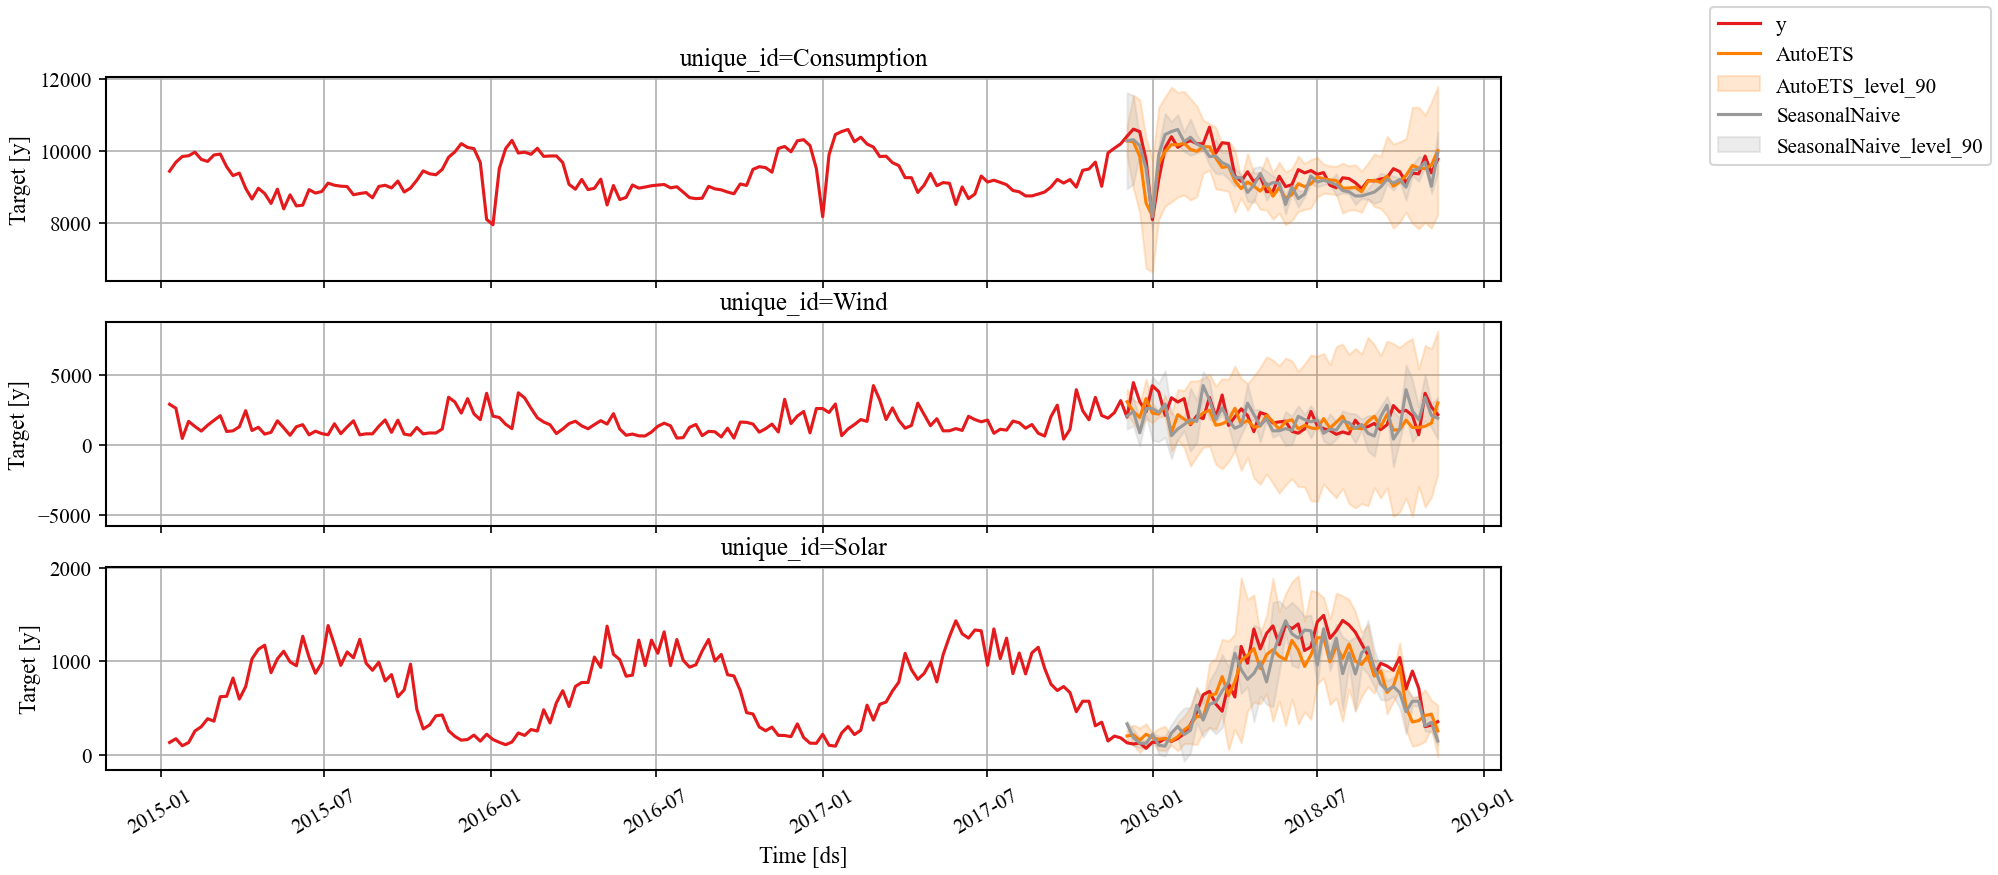

In [66]:
eval_sf_conf = df_test.merge(forecasts, on=['unique_id', 'ds'])

metrics = [coverage, scaled_crps]

metrics_eval = evaluate(
    df=eval_sf_conf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS,
    id_col='unique_id',
    time_col='ds',
    target_col='y'
).pivot_table(
    index=['unique_id', 'metric'],
    values=model_names
)
display(metrics_eval)

display(plot_series_v2(
    df_train,
    forecasts_df=eval_sf_conf,
    level=[90],
    palette='Set1'
))

## Session info

In [70]:
import session_info
session_info.show()

## Дополнительно
### Бутстреп интервалы


Недостаток процедуры комформной оценки интервалов в необходимости достаточно продолжительного калибровочного и тренировочного участков ВР. Для коротких участков ВР непараметрической альтернативой будет использование т.н. бутстреп оценки интревалов. Проведем эту процедуру методом блочного бутстрепа.

Ооценка интервалов прогноза достигается за счёт многократной генерации возможных будущих траекторий временного ряда. Для этого используется блочный бутстрэп остатков in_sample, позволяющий определить временную зависимость ошибок в трейне. Интервалы прогноза вычисляются как квантили распределения полученных траекторий.

In [ ]:
sf = StatsForecast(models=models, freq=FREQ)

fcst_sf = sf.forecast(
    df=df_train,
    h=h,
    fitted=True
)
in_sample_sf = sf.forecast_fitted_values()

model_names = extract_model_names(fcst_sf)


in_sample_sf

In [ ]:
import numpy as np
import pandas as pd

class BootstrapForecastSF:
    """
    Честный moving block bootstrap для StatsForecast.
    Остатки берутся прямо из трейна, merge не используется.
    """

    def __init__(
        self,
        sf,
        n_sim: int = 2000,
        block_size: int = None,
        levels: tuple[int, ...] = (90,),
        point: str = "median",
        random_state: int = 42,
    ):
        self.sf = sf
        self.n_sim = n_sim
        self.block_size = block_size
        self.levels = levels
        self.point = point
        self.rng = np.random.default_rng(random_state)

    @staticmethod
    def stationary_bootstrap(resid: np.ndarray, h: int, n_sim: int, block_size: int, rng) -> np.ndarray:
        """
        Moving block bootstrap по одному ряду.
        """
        T = len(resid)
        if T < 2:
            return np.tile(resid, (n_sim, h))
        bs = block_size or max(2, T // 10)
        n_blocks_needed = int(np.ceil(h / bs))
        starts = rng.integers(0, T - bs + 1, size=(n_sim, n_blocks_needed))
        block_offsets = np.arange(bs)[None, None, :]
        block_indices = starts[:, :, None] + block_offsets
        block_indices = block_indices.reshape(n_sim, -1)[:, :h]
        return resid[block_indices]

    def forecast(self, df: pd.DataFrame, h: int, X_df: pd.DataFrame = None) -> pd.DataFrame:
        """
        Честный forward forecast с bootstrap.
        """
        # 1️⃣ Forecast на горизонт
        fcst = self.sf.forecast(df=df, h=h, X_df=X_df, fitted=True)
        fitted = self.sf.forecast_fitted_values()
        y_col = self.sf.target_col

        # 2️⃣ Определяем модели
        model_cols = [c for c in fitted.columns if c not in ("unique_id", "ds", y_col)]

        # 3️⃣ Вычисляем остатки прямо в fitted (копирование, без merge)
        for m in model_cols:
            resid = df[y_col].values - fitted[m].values
            # убираем NaN, если модель не предсказывает все точки
            fitted[f"{m}_resid"] = np.where(np.isnan(resid), 0, resid)

        # 4️⃣ Подготовка колонок в выходе
        out = fcst.copy()  # оригинальные прогнозы остаются
        for m in model_cols:
            out[f"{m}_boot"] = np.nan
            for lvl in self.levels:
                out[f"{m}_lo-{lvl}"] = np.nan
                out[f"{m}_hi-{lvl}"] = np.nan

        # 5️⃣ По каждой модели и уникальной серии
        for m in model_cols:
            for uid in out["unique_id"].unique():
                idx = out.index[out["unique_id"] == uid]
                base_path = out.loc[idx, m].values
                resid = fitted.loc[fitted["unique_id"] == uid, f"{m}_resid"].values
                resid = resid[~np.isnan(resid)]  # честная фильтрация NaN

                if len(resid) < 2:
                    # fallback без бутстрэпа
                    out.loc[idx, f"{m}_boot"] = base_path
                    for lvl in self.levels:
                        out.loc[idx, f"{m}_lo-{lvl}"] = base_path
                        out.loc[idx, f"{m}_hi-{lvl}"] = base_path
                    continue

                # 6️⃣ Блочный bootstrap
                sims = self.stationary_bootstrap(
                    resid=resid,
                    h=len(idx),
                    n_sim=self.n_sim,
                    block_size=self.block_size,
                    rng=self.rng
                )
                sims += base_path

                # 7️⃣ Точечный прогноз
                if self.point == "median":
                    out.loc[idx, f"{m}_boot"] = np.median(sims, axis=0)
                elif self.point == "mean":
                    out.loc[idx, f"{m}_boot"] = sims.mean(axis=0)
                else:  # 'base'
                    out.loc[idx, f"{m}_boot"] = base_path

                # 8️⃣ Prediction intervals
                for lvl in self.levels:
                    alpha = (100 - lvl) / 200
                    out.loc[idx, f"{m}-lo-{lvl}"] = np.quantile(sims, alpha, axis=0)
                    out.loc[idx, f"{m}-hi-{lvl}"] = np.quantile(sims, 1 - alpha, axis=0)

        for m in model_cols:
            out[m] = out[m+'_boot']
            out=out.drop(columns = [m+'_boot'])
        return out


In [ ]:
fcst_boot

In [ ]:
bb = BootstrapForecastSF(
    sf=sf,
    n_sim=2000,
    block_size=12,
    levels=LEVELS[:1],
    point="median",
    random_state=42,
)

fcst_boot = bb.forecast(
    df=df_train,
    h=h,
)

evaluate_and_plot(df_train, df_test, fcst_boot, metrics,  model_names = None, levels = LEVELS[:1], plot=True)

In [ ]:
from nixtla_diagnostic import *

fcst_sf_ = block_bootstrap_forecast(
    fcst_sf=fcst_sf,
    in_sample_sf=in_sample_sf,
    models = model_names,
    levels=LEVELS,
    n_sim=3000,          # можно 1000–3000
    block_size=SEASON,   # или None → auto    
    point_estimator='median',
    use_model_sigma = False,
    center_residuals =False,
)
 
evaluate_and_plot(df_train, df_test, fcst_sf_, metrics, levels=LEVELS[:1], model_names = None, plot=True)

In [ ]:
def get_errors(eval_df, model):
    return eval_df['y'].values - eval_df[model].values


from scipy.stats import t

def diebold_mariano(e1, e2, loss='mae', h=1):
    if loss == 'mae':
        d = np.abs(e1) - np.abs(e2)
    elif loss == 'mse':
        d = e1**2 - e2**2
    else:
        raise ValueError

    T = len(d)
    d_bar = np.mean(d)

    gamma = []
    for lag in range(h):
        cov = np.cov(d[lag:], d[:T-lag], bias=True)[0, 1]
        gamma.append(cov)

    var_d = gamma[0] + 2 * sum(
        (1 - k / h) * gamma[k] for k in range(1, h)
    )

    DM = d_bar / np.sqrt(var_d / T)
    p_value = 2 * (1 - t.cdf(np.abs(DM), df=T - 1))

    return DM, p_value



In [ ]:
e_ets = get_errors(eval_df, 'AutoETS')
e_arima = get_errors(eval_df, 'AutoTheta')

DM, p = diebold_mariano(
    e_ets,
    e_arima,
    loss='mae',
    h=eval_df['horizon'].max()
)



In [ ]:
def horizon_metrics(eval_df, model_names, metric='mae'):
    rows = []

    for (uid, h), g in eval_df.groupby(['unique_id', 'horizon']):
        y_true = g['y'].values
        for model in model_names:
            y_pred = g[model].values
            if metric == 'mae':
                val = np.mean(np.abs(y_true - y_pred))
            elif metric == 'rmse':
                val = np.sqrt(np.mean((y_true - y_pred)**2))
            else:
                raise ValueError("Unsupported metric")
            rows.append({
                'unique_id': uid,
                'horizon': h,
                'metric': metric,
                'model': model,
                'value': val
            })
    return pd.DataFrame(rows)

# Использование:
model_names = ['AutoETS', 'AutoTheta']
hm_mae = horizon_metrics(eval_df, model_names, metric='mae')
hm_rmse = horizon_metrics(eval_df, model_names, metric='rmse')


In [ ]:
hm_mae

In [ ]:
def get_errors(eval_df, model):
    return eval_df['y'].values - eval_df[model].values
from scipy.stats import t
import numpy as np

def diebold_mariano(e1, e2, loss='mae', h=1):
    if loss == 'mae':
        d = np.abs(e1) - np.abs(e2)
    elif loss == 'mse':
        d = e1**2 - e2**2
    else:
        raise ValueError("loss must be 'mae' or 'mse'")
    
    T = len(d)
    d_bar = np.mean(d)
    
    # HAC variance
    gamma = []
    for lag in range(h):
        cov = np.cov(d[lag:], d[:T-lag], bias=True)[0,1]
        gamma.append(cov)
    
    var_d = gamma[0] + 2 * sum((1 - k/h)*gamma[k] for k in range(1,h))
    
    DM = d_bar / np.sqrt(var_d / T)
    p_value = 2 * (1 - t.cdf(np.abs(DM), df=T-1))
    return DM, p_value


In [ ]:
e_ets = get_errors(eval_df, 'AutoETS')
e_theta = get_errors(eval_df, 'AutoTheta')

DM, p_val = diebold_mariano(e_ets, e_theta, loss='mae', h=eval_df['horizon'].max())

print(f"DM = {DM:.3f}, p-value = {p_val:.3f}")

DM < 0 → вторая модель лучше (AutoTheta)

p < 0.05 → значимо

In [ ]:
import pandas as pd
import numpy as np

def get_loss_matrix(eval_df, model_names, loss='mae'):
    """
    Возвращает матрицу ошибок: строки = точки времени, колонки = модели
    """
    loss_mat = pd.DataFrame(index=eval_df.index)

    for model in model_names:
        y_true = eval_df['y'].values
        y_pred = eval_df[model].values
        if loss == 'mae':
            loss_mat[model] = np.abs(y_true - y_pred)
        elif loss == 'mse':
            loss_mat[model] = (y_true - y_pred)**2
        else:
            raise ValueError("Unsupported loss")
    
    return loss_mat


In [ ]:
from scipy.stats import t

def mcs(eval_df, model_names, alpha=0.05, loss='mae'):
    """
    Model Confidence Set (MCS)
    
    eval_df: DataFrame с 'y' и прогнозами
    model_names: list[str]
    alpha: уровень значимости
    loss: 'mae' или 'mse'
    
    Возвращает список моделей, входящих в MCS
    """
    # 1. Loss matrix
    L = get_loss_matrix(eval_df, model_names, loss=loss)
    models = model_names.copy()

    while len(models) > 1:
        # Средние ошибки
        mean_loss = L[models].mean()
        worst_model = mean_loss.idxmax()
        
        # DM тест worst_model против остальных
        p_values = []
        for m in models:
            if m == worst_model:
                continue
            d = L[worst_model] - L[m]
            d_bar = np.mean(d)
            # HAC variance (Newey–West, h=1)
            var_d = np.var(d, ddof=1)
            DM_stat = d_bar / np.sqrt(var_d / len(d))
            p_val = 2 * (1 - t.cdf(np.abs(DM_stat), df=len(d)-1))
            p_values.append(p_val)
        
        # Если worst_model значимо хуже всех → удаляем
        if all(p < alpha for p in p_values):
            models.remove(worst_model)
        else:
            break  # больше исключать нельзя

    return models


In [ ]:
model_names = ['AutoETS', 'AutoTheta']  # можно добавить все модели

mcs_models = mcs(eval_df, model_names, alpha=0.05, loss='mae')
print("Выжившие модели MCS:", mcs_models)


In [ ]:
mcs_by_h = {}
for h, g in eval_df.groupby('horizon'):
    mcs_by_h[h] = mcs(g, model_names, alpha=0.05, loss='mae')

# Пример вывода:
for h, models in mcs_by_h.items():
    print(f"Horizon {h}: {models}")


In [16]:
import session_info
session_info.show()


## Дополнительно про CV



#### Расширение прогноза с расчитанными интервалами

Для экстраполяции расчитанных интервалов forecasts  примем предположение, что интервал растет прпорционально корню из шага прогноза

Теперь проведем экстраполяцию:
- строим еще один точечный прогноз forecasts_point 
- для значений меньше h добавляем в forecasts_point значения из forecasts
- расчитываем среднюю половину ширины интервала на калибровочном горизонте
   $$
   q = \frac{1}{h} \sum_{t=1}^{h} \frac{\text{hi}_t - \text{lo}_t}{2}
   $$
-  Масштабируем ширину интервала для будущих точек, предполагая, что **неопределённость растёт со временем как $\sqrt{t/h}$**:
  $$ \text{half\_width}_t = q \cdot \sqrt{\frac{t}{h}}, \quad t = h+1, \dots, FH$$
    где:  
   - $t$ — номер шага прогноза относительно конца калибровочного горизонта. Например, если $h=10$, то первый шаг за пределами калибровки $t=11$, следующий $t=12$ и т.д.  
   - $\sqrt{t/h}$ — стандартное предположение о росте дисперсии случайного блуждания: чем дальше прогноз, тем шире интервалы.

   - Экстраполированные интервалы добавляются к **точечному прогнозу**:

   $$
   \text{lo}_t = \hat{y}_t - \text{half\_width}_t, \quad
   \text{hi}_t = \hat{y}_t + \text{half\_width}_t
   $$

- Для $t \le h$ используются реальные конформные интервалы.  
- Для $t > h$ интервалы экстраполируются с учётом роста неопределенности.

На что обратить внимание:
- Средняя ширина ($q$) усреднена по калибровочному горизонту. Если ВР не стационарен или есть сильная сезонность, она может недооценивать или переоценивать будущую неопределённость.
- Можно вместо среднего брать квантили распределения половины ширины или постепенно скользящее усреднение, чтобы учесть тренды в волатильности.
- Масштабирование $\sqrt t$ предполагает, что ошибки независимы и одинаково распределены. Для сезонных или автокоррелированных временных рядов это будет только приблизительно.

In [ ]:
# Создаём копию точечного прогноза
forecasts_full = forecasts_point.copy()

# Добавляем колонки интервалов (если их нет)
for model in model_names:
    lo_col = f"{model}-lo-90"
    hi_col = f"{model}-hi-90"
    if lo_col not in forecasts_full.columns:
        forecasts_full[lo_col] = np.nan
        forecasts_full[hi_col] = np.nan

# Обрабатываем каждый ряд отдельно
for uid in forecasts_full['unique_id'].unique():
    # Подмножества
    mask_full = forecasts_full['unique_id'] == uid
    mask_calib = forecasts['unique_id'] == uid
    
    # Длина калибровочного горизонта
    h_local = min(h, forecasts[mask_calib].shape[0])  # на случай разной длины
    
    for model in model_names:
        lo_col = f"{model}-lo-90"
        hi_col = f"{model}-hi-90"
        
        if lo_col not in forecasts.columns:
            continue
        
        # --- Часть 1: копируем калибровочные интервалы ---
        forecasts_full.loc[mask_full, model] = forecasts_point.loc[mask_full, model].values
        
        calib_vals_lo = forecasts.loc[mask_calib, lo_col].values[:h_local]
        calib_vals_hi = forecasts.loc[mask_calib, hi_col].values[:h_local]
        
        full_idx = forecasts_full.loc[mask_full].index[:h_local]
        forecasts_full.loc[full_idx, lo_col] = calib_vals_lo
        forecasts_full.loc[full_idx, hi_col] = calib_vals_hi
        
        # --- Часть 2: экстраполяция для t > h ---
        if FH > h_local:
            # Вариант 1: среднее
            # q = ((forecasts.loc[mask_calib, hi_col] - forecasts.loc[mask_calib, lo_col]) / 2).mean()
            
            # Вариант 2: квантиль
            # q = np.quantile((forecasts.loc[mask_calib, hi_col] - forecasts.loc[mask_calib, lo_col]) / 2, 0.9)
            
            # Вариант 3: скользящее среднее  
            widths = (forecasts.loc[mask_calib, hi_col] - forecasts.loc[mask_calib, lo_col]) / 2
            q = widths.rolling(window=3, min_periods=1).mean().iloc[-1]
            
            t_future = np.arange(h_local + 1, FH + 1)
            scaling = np.sqrt(t_future / h_local)
            half_width = q * scaling
            
            point_future = forecasts_full.loc[mask_full, model].iloc[h_local:].values
            idx_future = forecasts_full.loc[mask_full].index[h_local:]
            
            forecasts_full.loc[idx_future, lo_col] = point_future - half_width
            forecasts_full.loc[idx_future, hi_col] = point_future + half_width

In [ ]:
eval_sf_conf = df_test.merge(forecasts_full, on=['unique_id', 'ds'])

metrics = [coverage, scaled_crps]

metrics_eval = evaluate(
    df=eval_sf_conf,
    metrics=metrics,
    train_df=df_train,
    level=[90],
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

pivot_cov_crps = metrics_eval.pivot_table(
    index=['unique_id', 'metric'],
    values=model_names
)
pivot_cov_crps

In [ ]:
n_rows = eval_sf_conf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 4*n_rows), sharex=True)
plot_series(
    df_train,
    forecasts_df=eval_sf_conf,
    level=[90],
    ax=ax,
    palette='Set1'
)

#### bootstrap-калибровка (беггинг)

Если распределние на калиборовном интервале не известно, можно сделать bootstrap-based калибровку (беггинг) для экстраполяции ВР:
- Берём калибровочный горизонт h.
- Генерируем N бутстрэп-выборок из остатков на этом горизонте.
- Для каждой выборки считаем верхнюю квантиль ошибки (или половину ширины интервала).
- Берём среднее/квантиль этих квантильных значений и используем для построения прогнозных интервалов на весь горизонт.

In [ ]:
import numpy as np

N_BOOT = 100
ALPHA = 0.1  # для 90% интервала

# Создаём копию точечного прогноза
forecasts_full = forecasts_point.copy()

# Добавляем колонки интервалов (если их нет)
for model in model_names:
    lo_col = f"{model}-lo-90"
    hi_col = f"{model}-hi-90"
    if lo_col not in forecasts_full.columns:
        forecasts_full[lo_col] = np.nan
        forecasts_full[hi_col] = np.nan

# Обрабатываем каждый ряд отдельно
for uid in forecasts_full['unique_id'].unique():
    mask_full = forecasts_full['unique_id'] == uid
    mask_calib = forecasts['unique_id'] == uid
    
    h_local = min(h, forecasts[mask_calib].shape[0])
    
    for model in model_names:
        lo_col = f"{model}-lo-90"
        hi_col = f"{model}-hi-90"
        if lo_col not in forecasts.columns:
            continue
        
        # ---  конформные интервалы на t <= h ---
        forecasts_full.loc[mask_full, model] = forecasts_point.loc[mask_full, model].values
        forecasts_full.loc[forecasts_full.loc[mask_full].index[:h_local], lo_col] = forecasts.loc[mask_calib, lo_col].values[:h_local]
        forecasts_full.loc[forecasts_full.loc[mask_full].index[:h_local], hi_col] = forecasts.loc[mask_calib, hi_col].values[:h_local]
        
        # ---  бутстрэп для t > h ---
        if FH > h_local:
            widths = (forecasts.loc[mask_calib, hi_col] - forecasts.loc[mask_calib, lo_col]).values / 2
            boot_qs = []
            for _ in range(N_BOOT):
                sample = np.random.choice(widths, size=widths.shape[0], replace=True)
                boot_qs.append(np.quantile(sample, 1 - ALPHA))
            q_boot = np.mean(boot_qs)
            
            # Масштабирование с sqrt(t/h)
            t_future = np.arange(h_local + 1, FH + 1)
            scaling = np.sqrt(t_future / h_local)
            half_width = q_boot * scaling
            
            point_future = forecasts_full.loc[mask_full, model].iloc[h_local:].values
            idx_future = forecasts_full.loc[mask_full].index[h_local:]
            
            forecasts_full.loc[idx_future, lo_col] = point_future - half_width
            forecasts_full.loc[idx_future, hi_col] = point_future + half_width


In [ ]:
eval_sf_conf = df_test.merge(forecasts_full, on=['unique_id', 'ds'])

metrics = [coverage, scaled_crps]

metrics_eval = evaluate(
    df=eval_sf_conf,
    metrics=metrics,
    train_df=df_train,
    level=[90],
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

pivot_cov_crps = metrics_eval.pivot_table(
    index=['unique_id', 'metric'],
    values=['AutoETS', 'SeasonalNaive']
)
pivot_cov_crps

In [ ]:
n_rows = eval_sf_conf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 4*n_rows), sharex=True)
plot_series(
    df_train,
    forecasts_df=eval_sf_conf,
    level=[90],
    ax=ax,
    palette='Set1'
)

#### Упражнение:
1. Сравнить метрики предсказания ВР без калибровки и с калибровкой

### Калибровка вероятностного интервала
Для оценки интервальных прогнозов в соотвествующих моделях достаточно в прогнозе указать параметр уровня (например 50%) по которому необходимо значение. Однако, как уже было сказано, такие значения могут не точно покрывать реальные вероятности появления будущих значений. То есть фактическое покрытие (доля случаев, когда истинное значение попадает в интервал) может существенно отличаться от заявленного уровня. Например, номинальный 95%-ный интервал может покрывать реальные значения лишь в 70–85% случаев.


Для приведения уровней к реальным значениям используют ряд приемов, наиболее популярными из которых являются т.н. комформные интервалы и беггинг интервалов. 

Nixtla предоставляет инструментарий для комформной оценки интервалов. Важно отметить, что в некоторых версиях экосистемы вероятностный прогноз вообще не может быть выполнен без предварительной калибровки интервалов.

Комформная оценка интервалов строится путем калибровки значений на валидационной подвыборке (калибровочной подвыборке). Комформное преобрзование осуществляется следующим образодм:

1. Разбиение выборки на тренировочную и калибровочную подвыборки
2. Построение точечного прогноза на калибровочной подвыборке
3. Расчет невязки прогноза на калибровочной подвырбоке
4. Оценка разброса невязки по заданым уровням (квантилям)

В Nixtla [комформное преобразование выполнятся](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/conformalprediction.html#how-conformal-prediction-works) со следующими модификациями:
1. Разбиение может происходить несколько раз путем скользящих окон.
2. Оценка неопределенности может быть асимитричной (отдельно оцениваются нижнии и отдельно верхнии квантили).


Отметим, что в отличии от иных методов оценки неопределенности, [комформное преобразование гарантирует, что предсказанный интервал покроет диапазон реальных значений при сохранении поведения модели](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/conformalprediction.html#conformal-prediction-vs-traditional-methods).

